# Thesis Data Pipeline — 09.03.2026

**Author**: Mihkel Uutar  
**Supervisor**: Prof. Juri Belikov, TalTech Department of Software Science  

This is the **source-of-truth data pipeline** for the thesis *"Inertia-Aware, Explainable Heat-Demand Forecasting for Estonian Apartment Buildings"*.

It is fully self-contained: it reads raw campus CSV files, weather data, and building registry metadata, and produces clean, labelled, model-ready per-building datasets in `data/clean/`.

### Three problems this pipeline solves vs the previous version

1. **Outlier removal was global**: the old pipeline computed outlier thresholds over the full 3-year series. Summer heating (near zero) and winter heating (high) have fundamentally different distributions, so summer spikes were missed and valid winter peaks were sometimes clipped. This pipeline applies outlier removal **per calendar month**.

2. **Imputation was incomplete**: predictor columns got only 3-hour linear interpolation; energy targets got nothing at all. This left unnecessary NaN gaps that break model training sequences. This pipeline applies a **three-tier imputation strategy** (linear → daily-pattern → weather-regression), with every imputed row flagged.

3. **Column names and downstream targets were unstable**: names like `U06_BHB01_peaarvesti_energy_delta_mwh` are not workable in model code or SHAP outputs, and later notebooks had to re-decide which heat column was the true target. This pipeline now renames columns, builds **canonical subsystem aggregates**, and exports one harmonized **`heat_target_mwh`** per building.

### Cleaning approach

Based on Prof. Belikov's *Energy Data Science – Cleaning* lecture (ITS8080, 2025):
- Diagnose the missing-data mechanism (MCAR / MAR / MNAR) before choosing a strategy.
- Never impute more than you can defend — every imputed value is flagged.
- Preserve real dynamics: winter peaks, diurnal patterns, weekday structure.

### Structure

| Cell | Purpose |
|------|---------|
| 0 | Setup: imports, paths, all configuration constants |
| 1–2 | Load raw campus CSVs + weather |
| 3 | Hourly resampling (cumulative → delta) |
| 4 | Deduplication + time-window restriction |
| 5 | Baseline missing-data diagnostic |
| 6–7 | Monthly outlier removal |
| 8 | Column-wise deletion (>80% missing) |
| 9 | Tier 1: short-gap linear interpolation |
| 10 | Tier 2: daily-pattern fill (medium gaps) |
| 11 | Tier 3: weather-regression fill (long gaps) |
| 12 | Imputation flag columns |
| 13 | Weather cross-fill (COP ↔ KKP) |
| 14 | Post-imputation diagnostic |
| 15 | Column renaming |
| 15b | Canonical subsystem aggregates, weighted `ΔT`, and harmonized `heat_target_mwh` |
| 15c | Building-static companion tables and full-history diagnostics |
| 16 | Export cleaned hourly files and companion CSVs |
| 17 | Pipeline validation gate |


## Cell 0 — Setup: imports, paths, and cleaning configuration

All imports, project paths, and every configuration constant live here in one place so there is a single location to adjust tuning parameters.

### What each constant controls

| Constant | Value | Why |
|---|---|---|
| `MISSING_DROP_THRESHOLD` | 0.80 | Column-wise deletion threshold. If >80% of a column is missing, imputation would synthesise more values than it observes — not defensible. |
| `ENERGY_INTERP_LIMIT_H` | 3 | Max gap (hours) for linear interpolation of energy targets. Short MCAR gaps are safe to interpolate linearly; beyond 3h the straight-line assumption becomes unreliable for demand data. |
| `PREDICTOR_INTERP_LIMIT_H` | 6 | Max gap for predictor columns (temperatures, flows). Temperatures change slowly, so 6h interpolation introduces less distortion than it would for energy. |
| `DAILY_PATTERN_MAX_GAP_H` | 48 | Upper bound for Tier 2 (daily-pattern) imputation. Beyond 48h, the ±7-day lookback window shrinks and same-hour medians degrade. |
| `DAILY_PATTERN_LOOKBACK_DAYS` | 7 | Half-width of the same-hour median window. 7 days captures both weekday and weekend patterns and is short enough to stay within the same season. |
| `MONTHLY_CLIP_K` | 6.0 | Robust MAD multiplier for monthly outlier clipping. Tighter than the old global k=8 because monthly energy distributions are narrower — 6σ catches real extremes without touching seasonal peaks. |
| `ROLLING_WINDOW_HOURS` | 24 | Window for the rolling spike filter (24h = full day). |
| `ROLLING_K` | 10.0 | Rolling MAD multiplier — generous to only catch clear isolated spikes within a day. |
| `TEMP_MIN_C` / `TEMP_MAX_C` | 0 / 150 | Physical sanity bounds for district heating supply/return temperatures. Enforced after Tier 4 ffill/bfill and validated in Cell 17. |
| `REG_MIN_OBSERVED_FRAC` | 0.20 | Minimum fraction of observed (non-NaN) data required before fitting a regression imputer. Below 20%, the model has too few training points to be useful. |
| `REG_MIN_R2_ENERGY` | 0.20 | Minimum training R² for energy regression imputation. Models below this threshold are skipped — filling with noise is worse than leaving NaN for Tier 4. |
| `REG_MIN_R2_TEMP` | 0.20 | Same quality gate for supply/return temperature regressions. |
| `HEATING_OUTDOOR_TEMP_THRESHOLD_C` | 10.0 | Weather-based heating-season threshold used when summarising `ΔT`, inertia, and daily heat/weather diagnostics. |
| `DELTA_T_LOW_THRESHOLD_C` | 15.0 | Practical low-`ΔT` threshold used to flag potentially inefficient or control-problematic heating operation. |
| `MIN_HEAT_LOAD_FOR_DELTAT_MWH` | 0.001 | Minimum hourly load required before interpreting subsystem `ΔT`; avoids treating near-zero-flow hours as meaningful thermal operation. |

### Output philosophy

This notebook is responsible for the **clean hourly source-of-truth files**. That now includes:
- consistent clean column names,
- canonical subsystem heat aggregates,
- one harmonized hourly `heat_target_mwh`,
- weighted subsystem `ΔT` columns and low-`ΔT` flags,
- and companion static/diagnostic tables for later notebooks.

Any feature that depends on the **full history of the target** is exported here for auditability, but if it is later used as a model input it must be recomputed on the training window in the feature-engineering notebook.


In [1]:
# Cell 0 — Imports, paths, and all cleaning constants

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 110

# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------
PROJECT_ROOT              = Path.cwd()
DATA_DIR                  = PROJECT_ROOT / "data"
CAMPUS_DATA_DIR           = DATA_DIR / "campus-data"
OVERVIEW_FILE             = CAMPUS_DATA_DIR / "andmed ulevaade.xlsx"
BUILDING_CODES_FILE       = CAMPUS_DATA_DIR / "hooned koodid.xlsx"
COPERNICUS_DIR            = DATA_DIR / "copernicus-era5-taltech"
KKP_DIR                   = DATA_DIR / "keskkonnaportaal"
COMBINED_WEATHER_FILE     = DATA_DIR / "combined_weather_2022_2025.csv"
EXPORT_DIR                = DATA_DIR / "clean"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Dataset scope
# ---------------------------------------------------------------------------
CAMPUS_BUILDINGS = [
    "GEO", "ICO", "LIB", "SOC", "STU",
    "U01", "U01U02", "U02", "U02B",
    "U03", "U03B", "U04", "U04B",
    "U05", "U05B", "U06", "U06A",
]
CAMPUS_DATA_YEARS  = [2022, 2023, 2024]
START_DATE         = "2022-01-01"
END_DATE           = "2024-12-31 23:59:59"
EXCLUDED_BUILDINGS = {"NRG"}           # electricity-only; different structure

# ---------------------------------------------------------------------------
# Estonian measurement variable names → English column suffixes
# ---------------------------------------------------------------------------
MEASUREMENT_VAR_EN = {
    "näit":                    "energy_mwh",       # cumulative MWh reading
    "pealevoolu temperatuur":  "supply_temp_c",    # supply (flow) temperature
    "tagasivoolu temperatuur": "return_temp_c",   # return temperature
    "läbivool":                "flow_rate_m3h",   # instantaneous flow rate
    "vooluhulk":               "flow_volume_m3",  # cumulative flow volume
    "hetkvõimsus":             "power_kw",         # instantaneous power
}

# Estonian subsystem type → standardised heating group label
SUBSYSTEM_TYPE_TO_GROUP = {
    "peaarvesti":  "total",
    "küte":        "space_heating",
    "radiaatorid": "space_heating",
    "ventilatsioon": "vent_heating",
    "ventküte":    "vent_heating",
    "õhkküte":     "vent_heating",
    "vesi":        "dhw",
    "väliküte":    "outdoor_heating",
    "jääksoojus":  "waste_heat",
}

# Variables that are cumulative (need diff → delta) vs instantaneous (mean per hour)
CUMULATIVE_VARS  = {"energy_mwh", "flow_volume_m3"}
INSTANT_VARS     = {"supply_temp_c", "return_temp_c", "flow_rate_m3h", "power_kw"}

# ---------------------------------------------------------------------------
# Cleaning configuration — adjust all tuning here
# ---------------------------------------------------------------------------

# Outlier removal (monthly MAD-based)
MONTHLY_CLIP_K          = 6.0    # robust sigma multiplier per month
ENERGY_FALLBACK_Q       = 0.999  # fallback quantile if MAD is zero
ROLLING_WINDOW_HOURS    = 24     # rolling spike filter window (hours)
ROLLING_K               = 10.0   # rolling sigma multiplier
ROLLING_MIN_PERIODS     = 12     # min non-NaN values in rolling window

# Resampling: how to handle raw sensor gaps
MAX_INTERP_GAP_H        = 6      # for INSTANTANEOUS vars: gaps <= this get interpolated;
                                  #   > this: mark gap hours as NaN.
                                  # CUMULATIVE vars: always interpolate (energy is
                                  #   real — bracketed by known cumulative values).


# Temperature physical sanity bounds
TEMP_MIN_C              = 0.0
TEMP_MAX_C              = 150.0

# Column-wise deletion
MISSING_DROP_THRESHOLD  = 0.80   # drop column if > 80% NaN after outlier removal

# Tier 1: short-gap linear interpolation
ENERGY_INTERP_LIMIT_H   = 3      # max hours for energy target interpolation
PREDICTOR_INTERP_LIMIT_H = 6     # max hours for predictor (temp/flow) interpolation

# Tier 2: daily-pattern fill
DAILY_PATTERN_MAX_GAP_H      = 48   # only fill gaps up to this length
DAILY_PATTERN_LOOKBACK_DAYS  = 7    # ± days to search for same-hour medians

# Tier 3: weather-regression fill
REG_MIN_OBSERVED_FRAC   = 0.20   # skip regression if less than 20% data is observed
REG_MIN_R2_ENERGY       = 0.20   # minimum R² to apply energy regression fill
REG_MIN_R2_TEMP         = 0.20   # minimum R² to apply temperature regression fill

# Derived-feature configuration used by downstream modelling notebooks
HEATING_OUTDOOR_TEMP_THRESHOLD_C = 10.0   # heating season proxy for ΔT and inertia summaries
DELTA_T_LOW_THRESHOLD_C          = 15.0   # practical low-ΔT threshold for district-heating circuits
MIN_HEAT_LOAD_FOR_DELTAT_MWH     = 0.001  # ignore near-zero load hours when interpreting ΔT
NIGHT_HOURS                      = tuple(range(0, 6))
DAY_HOURS                        = tuple(range(8, 19))

# ---------------------------------------------------------------------------
# Diagnostic: confirm paths resolve correctly
# ---------------------------------------------------------------------------
print("Project root :", PROJECT_ROOT)
print("Campus data  :", CAMPUS_DATA_DIR)
print("Weather file :", COMBINED_WEATHER_FILE)
print("Export dir   :", EXPORT_DIR)
print()
print(f"Buildings in scope : {len(CAMPUS_BUILDINGS)}")
print(f"Years in scope     : {CAMPUS_DATA_YEARS}")
print(f"Date window        : {START_DATE} → {END_DATE}")

Project root : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Campus data  : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/campus-data
Weather file : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv
Export dir   : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean

Buildings in scope : 17
Years in scope     : [2022, 2023, 2024]
Date window        : 2022-01-01 → 2024-12-31 23:59:59


## Cell 1 — Load the measurement manifest and raw campus CSVs

### What we are loading

The overview Excel file (`andmed ulevaade.xlsx`) is the **manifest**: each row describes one measurement point — which building it belongs to, what type of sensor it is, what unit it records in, and which CSV files contain its data for 2022, 2023, and 2024.

We use this manifest to drive all loading. Every column in the resulting per-building DataFrames traces back to exactly one manifest row, so there are no hidden or guessed file paths.

### How loading works

1. Parse the manifest to add English labels and heating-group assignments.
2. For each manifest row, load the CSV files for all available years, concatenate them, and produce a single time-indexed `pd.Series` named after the measurement point.
3. Group all Series by building and combine into per-building DataFrames.

### Why the raw DataFrames look sparse

Each building's DataFrame is an outer join of all its sensor Series. Different sensors report at different timestamps (10–20 min intervals, different start/end dates), so the union timestamp index is sparse — most cells are NaN. This is expected. The NaN cells simply mean "this sensor did not report at this particular timestamp". The sparsity will be resolved in Cell 3 when we resample to a uniform hourly grid.

### Plot

A heatmap shows **how many CSV files exist per building per year** — a quick sanity check that the manifest is complete and no buildings are entirely missing.

Manifest rows : 149
  energy (MWh näit)     : 69
  temperature columns   : 78
  other (flow/power)    : 2


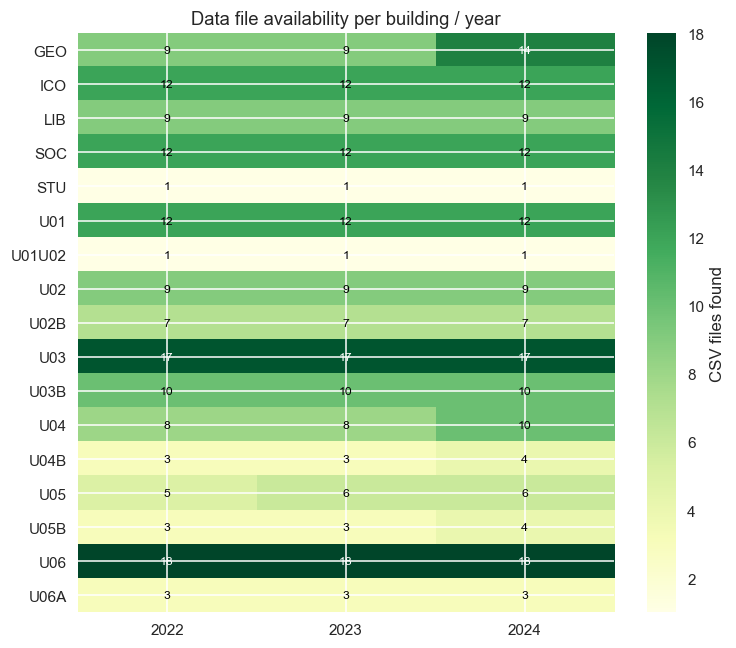

  [WARN] missing: SOC_BHB02_pealevoolu temp_202.csv

Buildings loaded: 17
  GEO     : 14 columns, 109,987 unique timestamps
  ICO     : 12 columns, 132,175 unique timestamps
  LIB     :  9 columns, 38,832 unique timestamps
  SOC     : 12 columns, 38,833 unique timestamps
  STU     :  1 columns, 50,140 unique timestamps
  U01     : 12 columns, 40,154 unique timestamps
  U01U02  :  1 columns, 24,492 unique timestamps
  U02     :  9 columns, 30,392 unique timestamps
  U02B    :  7 columns, 38,072 unique timestamps
  U03     : 17 columns, 38,073 unique timestamps
  U03B    : 10 columns, 37,382 unique timestamps
  U04     : 10 columns, 38,073 unique timestamps
  U04B    :  4 columns, 37,670 unique timestamps
  U05     :  6 columns, 37,806 unique timestamps
  U05B    :  4 columns, 37,404 unique timestamps
  U06     : 18 columns, 37,670 unique timestamps
  U06A    :  3 columns, 37,340 unique timestamps


In [2]:
# Cell 1 — Parse manifest and load all raw campus CSVs

# ── 1a. Load and enrich the manifest ────────────────────────────────────────
overview_df = pd.read_excel(OVERVIEW_FILE)

# Attach English variable name and heating-group label to every manifest row
overview_df["mõõdetud_en"]  = overview_df["mõõdetud"].map(MEASUREMENT_VAR_EN)
overview_df["heating_group"] = overview_df["type"].map(SUBSYSTEM_TYPE_TO_GROUP)

# Build a human-readable column label: BUILDING_SUBSYSTEMID_TYPE_variable
overview_df["label"] = (
    overview_df["Hoone"].str.strip()
    + "_" + overview_df["ID convert"].str.strip().str.replace(".", "_", regex=False)
    + "_" + overview_df["type"].str.strip()
    + "_" + overview_df["mõõdetud_en"].fillna("unknown")
)

# Keep only rows that have a known variable and a building code we process
manifest_df = overview_df[
    overview_df["mõõdetud_en"].notna()
    & overview_df["Hoone"].isin(CAMPUS_BUILDINGS)
].copy().reset_index(drop=True)

# Compact lookup: per-label metadata (used later for hourly resampling and aggregates)
LABEL_META = (
    manifest_df[["label", "Hoone", "heating_group", "mõõdetud_en"]]
    .drop_duplicates(subset=["label"])
    .set_index("label")
)

print(f"Manifest rows : {len(manifest_df)}")
print(f"  energy (MWh näit)     : {(manifest_df['mõõdetud_en'] == 'energy_mwh').sum()}")
print(f"  temperature columns   : {manifest_df['mõõdetud_en'].isin(['supply_temp_c','return_temp_c']).sum()}")
print(f"  other (flow/power)    : {manifest_df['mõõdetud_en'].isin(['flow_rate_m3h','flow_volume_m3','power_kw']).sum()}")

# ── 1b. File-count heatmap (sanity check that data exists) ──────────────────
# Count how many CSV files exist in each building/year folder
file_counts = {}
for building in CAMPUS_BUILDINGS:
    file_counts[building] = {}
    for year in CAMPUS_DATA_YEARS:
        folder = CAMPUS_DATA_DIR / building / str(year)
        n = len(list(folder.glob("*.csv"))) if folder.exists() else 0
        file_counts[building][year] = n

fc_df = pd.DataFrame(file_counts).T  # buildings as rows, years as columns

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(fc_df.values, aspect="auto", cmap="YlGn")
ax.set_xticks(range(len(CAMPUS_DATA_YEARS)))
ax.set_xticklabels(CAMPUS_DATA_YEARS)
ax.set_yticks(range(len(fc_df.index)))
ax.set_yticklabels(fc_df.index)
for i in range(len(fc_df.index)):
    for j in range(len(CAMPUS_DATA_YEARS)):
        v = int(fc_df.iloc[i, j])
        ax.text(j, i, str(v) if v > 0 else "–",
                ha="center", va="center", fontsize=8,
                color="black" if v < fc_df.values.max() * 0.7 else "white")
fig.colorbar(im, ax=ax, label="CSV files found")
ax.set_title("Data file availability per building / year")
plt.tight_layout()
plt.show()

# ── 1c. Load every manifest row into a per-building Series list ─────────────
def load_manifest_row(row: pd.Series) -> pd.Series | None:
    """Load one manifest row (all years) into a single time-indexed Series.

    Steps:
    - For each year, build the file path from the manifest filename column.
    - Parse Time + Value columns; drop NaT timestamps and NaN values.
    - Concatenate all years and de-duplicate by keeping the last value per timestamp.
    """
    parts = []
    for year in CAMPUS_DATA_YEARS:
        fname = row.get(year)
        if not isinstance(fname, str) or not fname.strip():
            continue
        path = CAMPUS_DATA_DIR / row["Hoone"] / str(year) / fname
        if not path.exists():
            print(f"  [WARN] missing: {path.name}")
            continue
        raw = pd.read_csv(path)
        if "Time" not in raw.columns or "Value" not in raw.columns:
            continue
        times  = pd.to_datetime(raw["Time"], errors="coerce")
        values = pd.to_numeric(raw["Value"], errors="coerce")
        s = pd.Series(values.values, index=times)
        s = s[s.index.notna()].dropna()
        parts.append(s)

    if not parts:
        return None

    combined = pd.concat(parts).sort_index()
    combined = combined.groupby(level=0).last()   # collapse exact-timestamp duplicates
    combined.name = row["label"]
    return combined


building_raw_series: dict[str, list[pd.Series]] = {b: [] for b in CAMPUS_BUILDINGS}

for _, row in manifest_df.iterrows():
    s = load_manifest_row(row)
    if s is not None and not s.empty:
        building_raw_series[row["Hoone"]].append(s)

# Combine Series into per-building DataFrames (outer join on timestamp index)
building_dfs: dict[str, pd.DataFrame] = {}
for building, series_list in building_raw_series.items():
    if series_list:
        building_dfs[building] = pd.concat(series_list, axis=1).sort_index()

print(f"\nBuildings loaded: {len(building_dfs)}")
for b, df in sorted(building_dfs.items()):
    print(f"  {b:8s}: {df.shape[1]:2d} columns, {df.shape[0]:6,d} unique timestamps")

## Cell 2 — Load weather data

### Two weather sources

We have two weather datasets for the Tallinn area:

1. **Copernicus ERA5** (`combined_weather_2022_2025.csv`) — reanalysis data from the European Centre for Medium-Range Weather Forecasts. Covers the full 2022–2024 period at hourly resolution. Columns include outdoor temperature, wind speed, solar radiation, and more. Prefixed `COP_` in this pipeline.

2. **Keskkonnaportaal (KKP)** (`tallinn-harku_f_kliima_tund.csv`) — measured observations from the Tallinn–Harku meteorological station. Slightly different variables (precipitation, pressure, sunshine duration). Prefixed `KKP_` in this pipeline.

These two sources will be used together: ERA5 as the primary source, KKP as a cross-fill fallback for longer gaps (Cell 13).

### Plot

A dual-panel plot shows outdoor temperature from both sources for 2023 to confirm they align and show where they diverge.

Copernicus (COP) weather:
  Shape : (26304, 6)
  Range : 2022-01-01 00:00:00 → 2024-12-31 23:00:00
  Cols  : ['COP_temp_c', 'COP_wind_speed_ms', 'COP_ssrd_W_per_m2', 'KKP_temp_c', 'KKP_wind_speed_ms', 'KKP_sunshine_duration_min']

Keskkonnaportaal (KKP) weather:
  Shape : (26304, 6)
  Range : 2022-01-01 00:00:00 → 2024-12-31 23:00:00
  Cols  : ['pressure_hpa', 'precip_mm', 'sunshine_min', 'temp_min_c', 'temp_max_c', 'wind_ms']


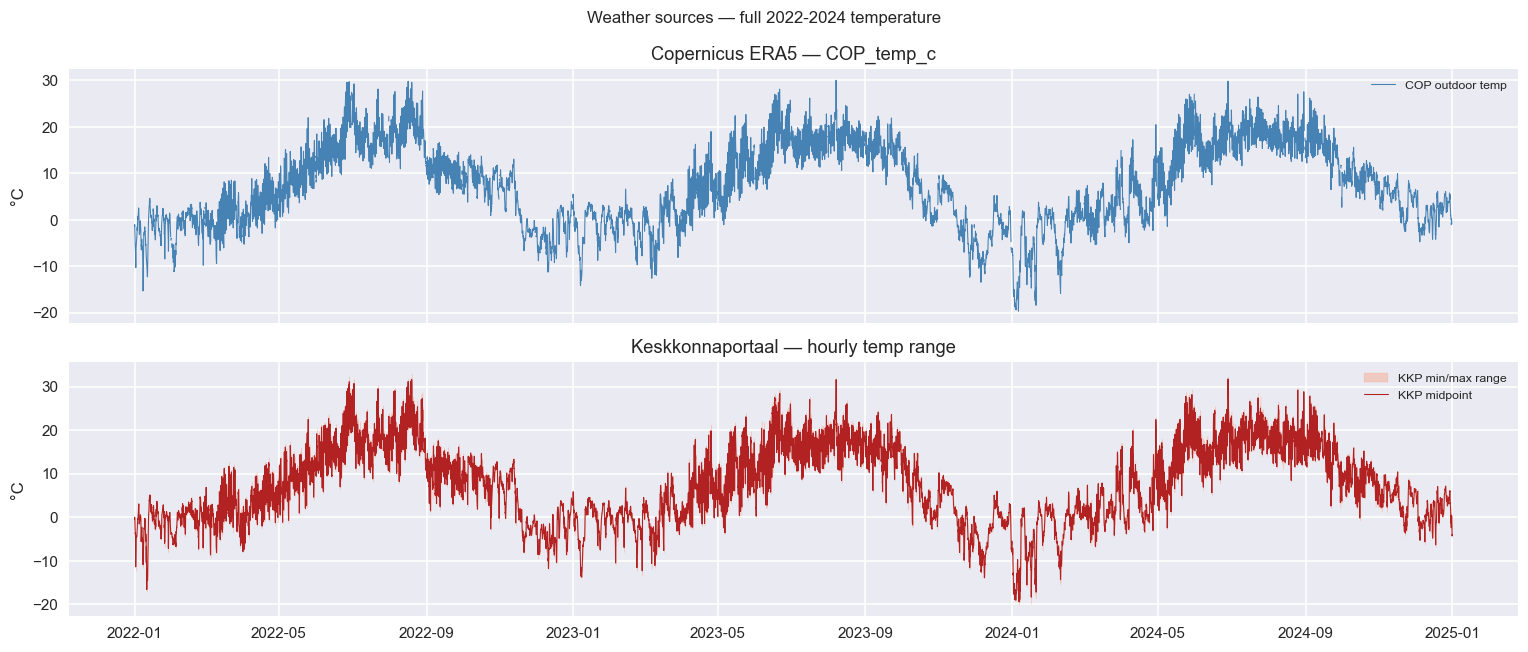

In [3]:
# Cell 2 — Load weather data (Copernicus ERA5 + Keskkonnaportaal)

# ── 2a. Primary weather: combined_weather_2022_2025.csv ──────────────────────
# This file is a pre-merged hourly table from the ERA5 reanalysis covering
# the TalTech campus area. Columns are already in English with COP_ prefix.
cop_raw = pd.read_csv(COMBINED_WEATHER_FILE, parse_dates=["datetime"])
cop_raw = cop_raw.set_index("datetime").sort_index()
# Restrict to our analysis window
cop_df = cop_raw.loc[START_DATE:END_DATE].copy()
# Drop duplicate timestamps (keep last, consistent with building data)
cop_df = cop_df[~cop_df.index.duplicated(keep="last")]
# Ensure continuous hourly grid (reindex fills any gaps with NaN)
cop_df = cop_df.asfreq("1h")

print("Copernicus (COP) weather:")
print(f"  Shape : {cop_df.shape}")
print(f"  Range : {cop_df.index.min()} → {cop_df.index.max()}")
print(f"  Cols  : {list(cop_df.columns)}")

# ── 2b. Secondary weather: KKP Tallinn-Harku station ────────────────────────
# Semicolon-separated, decimal comma, long format (one row per observation element)
KKP_FILE = KKP_DIR / "tallinn-harku_f_kliima_tund.csv"

KKP_ELEMENTS = {
    "PA0":    "pressure_hpa",      # air pressure
    "PR1H":   "precip_mm",         # 1-hour precipitation
    "SDUR1H": "sunshine_min",      # sunshine duration in minutes
    "WS10M":  "wind_ms",           # wind speed at 10 m
    "TAN1H":  "temp_min_c",        # hourly minimum temperature
    "TAX1H":  "temp_max_c",        # hourly maximum temperature
}

kkp_raw = pd.read_csv(KKP_FILE, sep=";", decimal=",",
                      encoding="utf-8", low_memory=False)

# Keep Tallinn-Harku station only (station code AJHARK01)
kkp_raw = kkp_raw[kkp_raw["jaam_kood - Station code, local"] == "AJHARK01"].copy()

# The CSV has separate year/month/day/hour columns (UTC) -- build a datetime from them
kkp_raw["datetime"] = pd.to_datetime({
    "year":  kkp_raw["aasta - Year of measurement, UTC time"],
    "month": kkp_raw["kuu - Month of measurement, UTC time"],
    "day":   kkp_raw["paev - Day of measurement, UTC time"],
    "hour":  kkp_raw["tund - Hour of measurement, UTC time"],
}, errors="coerce")
kkp_raw["value"] = pd.to_numeric(kkp_raw["vaartus - The measured value"], errors="coerce")
kkp_raw["element"] = kkp_raw["element_kood - Element code, local"]

# Keep only the elements we need, pivot to wide format
kkp_sel = kkp_raw[kkp_raw["element"].isin(KKP_ELEMENTS)].dropna(subset=["datetime"]).copy()
kkp_wide = (
    kkp_sel
    .sort_values("datetime")
    .groupby(["datetime", "element"], as_index=False)
    .last()
    .pivot(index="datetime", columns="element", values="value")
    .rename(columns=KKP_ELEMENTS)
    .sort_index()
)
kkp_df = kkp_wide.loc[START_DATE:END_DATE].copy()
kkp_df = kkp_df[~kkp_df.index.duplicated(keep="last")]
kkp_df = kkp_df.asfreq("1h")

print("\nKeskkonnaportaal (KKP) weather:")
print(f"  Shape : {kkp_df.shape}")
print(f"  Range : {kkp_df.index.min()} → {kkp_df.index.max()}")
print(f"  Cols  : {list(kkp_df.columns)}")

# ── 2c. Plot: temperature from both sources for all of 2023 ─────────────────
# Confirming the two sources align; divergence hints at data quality issues.
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

cop_temp_col = [c for c in cop_df.columns if "temp_c" in c.lower()][0]
axes[0].plot(cop_df.index, cop_df[cop_temp_col], lw=0.7, color="steelblue", label="COP outdoor temp")
axes[0].set_ylabel("°C")
axes[0].set_title(f"Copernicus ERA5 — {cop_temp_col}")
axes[0].legend(fontsize=8)

if "temp_min_c" in kkp_df.columns and "temp_max_c" in kkp_df.columns:
    axes[1].fill_between(kkp_df.index, kkp_df["temp_min_c"], kkp_df["temp_max_c"],
                         alpha=0.3, color="coral", label="KKP min/max range")
    axes[1].plot(kkp_df.index,
                 (kkp_df["temp_min_c"] + kkp_df["temp_max_c"]) / 2,
                 lw=0.7, color="firebrick", label="KKP midpoint")
    axes[1].set_ylabel("°C")
    axes[1].set_title("Keskkonnaportaal — hourly temp range")
    axes[1].legend(fontsize=8)

plt.suptitle("Weather sources — full 2022-2024 temperature", fontsize=11)
plt.tight_layout()
plt.show()

## Cell 2b — Quantitative comparison of weather sources (COP vs KKP)

### Why compare them?

We will later use **outdoor temperature, wind, and solar proxies** as key predictors. Since we have two sources (Copernicus ERA5 and Harku station), it is useful to measure **how far apart they are** so we understand whether switching or combining them would materially change the inputs.

### What we compare

For every hour where both sources are available, we compute simple diagnostics:

- **Temperature**: `COP_temp_c` vs `KKP_temp_c`  
  → mean bias (COP−KKP), RMSE, and correlation.
- **Wind speed**: `COP_wind_speed_ms` vs `KKP_wind_speed_ms`  
  → same metrics.
- **Solar / sunshine**: units differ (W/m² vs minutes), so we **do not subtract** them, but we compute a simple correlation between `COP_ssrd_W_per_m2` and `KKP_sunshine_duration_min` as a sanity check.

If in the future we add precipitation to the combined file (e.g. `COP_tp_m` and `KKP_precipitation_mm`), the same pattern can be reused.

### Plots

- Scatter plot of COP vs KKP **temperature** with a 1:1 line.  
- Scatter plot of COP vs KKP **wind speed** with a 1:1 line.
- Optional: scatter of solar radiation vs sunshine duration.

Temperature (COP_temp_c vs KKP_temp_c):
  n common   : 25804
  mean diff  : -0.054 °C (COP − KKP)
  RMSE       : 1.279 °C
  corr       : 0.990

Wind speed (COP_wind_speed_ms vs KKP_wind_speed_ms):
  n common   : 25804
  mean diff  : 0.447 m/s (COP − KKP)
  RMSE       : 1.022 m/s
  corr       : 0.828

Solar vs sunshine (correlation only):
  n common   : 25385
  corr       : 0.749 (COP_ssrd_W_per_m2 vs KKP_sunshine_duration_min)


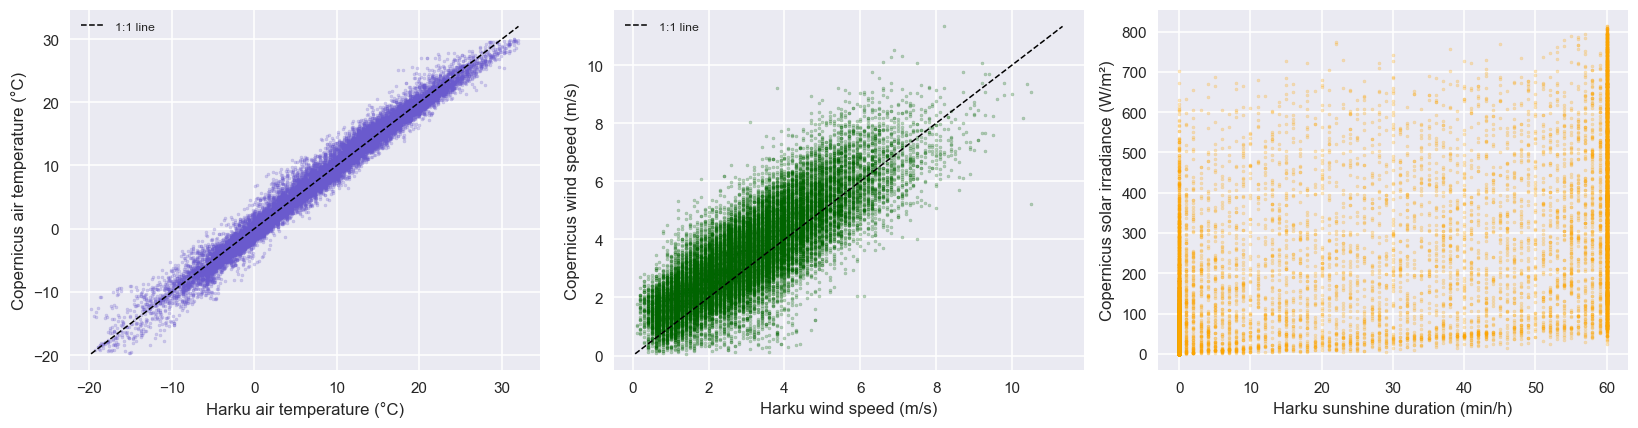

In [4]:
# Cell 2b — Simple numeric comparison between COP and KKP weather

# We keep this very NumPy-heavy for clarity and speed, avoiding clever wrappers.

def pairwise_stats(a: np.ndarray, b: np.ndarray) -> dict:
    """Compute basic difference statistics for two aligned 1D arrays.

    Returns a small dict with:
    - n         : number of hours where both sources are finite
    - mean_diff : mean(a − b)
    - rmse      : root-mean-square error of (a − b)
    - corr      : Pearson correlation between a and b
    """
    mask = np.isfinite(a) & np.isfinite(b)
    if not mask.any():
        return {"n": 0, "mean_diff": np.nan, "rmse": np.nan, "corr": np.nan}

    x = a[mask]
    y = b[mask]
    diff = x - y
    mean_diff = float(diff.mean())
    rmse = float(np.sqrt((diff ** 2).mean()))
    try:
        corr = float(np.corrcoef(x, y)[0, 1])
    except Exception:
        corr = np.nan
    return {"n": int(mask.sum()), "mean_diff": mean_diff, "rmse": rmse, "corr": corr}


# Build a 1×3 subplot for a thesis-ready visual summary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 2b.1 Temperature statistics ─────────────────────────────────────────────
if {"COP_temp_c", "KKP_temp_c"}.issubset(cop_df.columns):
    a = cop_df["COP_temp_c"].to_numpy()
    b = cop_df["KKP_temp_c"].to_numpy()
    temp_stats = pairwise_stats(a, b)
    print("Temperature (COP_temp_c vs KKP_temp_c):")
    print(f"  n common   : {temp_stats['n']}")
    print(f"  mean diff  : {temp_stats['mean_diff']:.3f} °C (COP − KKP)")
    print(f"  RMSE       : {temp_stats['rmse']:.3f} °C")
    print(f"  corr       : {temp_stats['corr']:.3f}")

    ax = axes[0]
    mask = np.isfinite(a) & np.isfinite(b)
    ax.scatter(b[mask], a[mask], s=4, alpha=0.25, color="slateblue")
    lo = float(np.nanmin(np.concatenate([a[mask], b[mask]])))
    hi = float(np.nanmax(np.concatenate([a[mask], b[mask]])))
    ax.plot([lo, hi], [lo, hi], color="black", lw=1, linestyle="--", label="1:1 line")
    ax.set_xlabel("Harku air temperature (°C)")
    ax.set_ylabel("Copernicus air temperature (°C)")
    # ax.set_title("Outdoor temperature: COP vs Harku")
    ax.legend(fontsize=8)
else:
    axes[0].set_visible(False)

# ── 2b.2 Wind-speed statistics ─────────────────────────────────────────────
if {"COP_wind_speed_ms", "KKP_wind_speed_ms"}.issubset(cop_df.columns):
    a = cop_df["COP_wind_speed_ms"].to_numpy()
    b = cop_df["KKP_wind_speed_ms"].to_numpy()
    wind_stats = pairwise_stats(a, b)
    print("\nWind speed (COP_wind_speed_ms vs KKP_wind_speed_ms):")
    print(f"  n common   : {wind_stats['n']}")
    print(f"  mean diff  : {wind_stats['mean_diff']:.3f} m/s (COP − KKP)")
    print(f"  RMSE       : {wind_stats['rmse']:.3f} m/s")
    print(f"  corr       : {wind_stats['corr']:.3f}")

    ax = axes[1]
    mask = np.isfinite(a) & np.isfinite(b)
    ax.scatter(b[mask], a[mask], s=4, alpha=0.25, color="darkgreen")
    lo = float(np.nanmin(np.concatenate([a[mask], b[mask]])))
    hi = float(np.nanmax(np.concatenate([a[mask], b[mask]])))
    ax.plot([lo, hi], [lo, hi], color="black", lw=1, linestyle="--", label="1:1 line")
    ax.set_xlabel("Harku wind speed (m/s)")
    ax.set_ylabel("Copernicus wind speed (m/s)")
    # ax.set_title("Wind speed: COP vs Harku")
    ax.legend(fontsize=8)
else:
    axes[1].set_visible(False)

# ── 2b.3 Solar vs sunshine (correlation only; units differ) ────────────────
if "COP_ssrd_W_per_m2" in cop_df.columns and "KKP_sunshine_duration_min" in cop_df.columns:
    a = cop_df["COP_ssrd_W_per_m2"].to_numpy()
    b = cop_df["KKP_sunshine_duration_min"].to_numpy()
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.any():
        corr = float(np.corrcoef(a[mask], b[mask])[0, 1])
        print("\nSolar vs sunshine (correlation only):")
        print(f"  n common   : {int(mask.sum())}")
        print(f"  corr       : {corr:.3f} (COP_ssrd_W_per_m2 vs KKP_sunshine_duration_min)")

        ax = axes[2]
        ax.scatter(b[mask], a[mask], s=4, alpha=0.25, color="orange")
        ax.set_xlabel("Harku sunshine duration (min/h)")
        ax.set_ylabel("Copernicus solar irradiance (W/m²)")
        # ax.set_title("Solar proxy vs sunshine")
    else:
        axes[2].set_visible(False)
else:
    axes[2].set_visible(False)

# plt.suptitle("Copernicus vs Harku weather sources (2022–2024)", fontsize=11)
plt.tight_layout()
plt.show()


## Cell 3 — Hourly resampling: interpolate-then-diff

### The problem with naive `diff → resample`

Campus meters report at irregular intervals and sometimes stop logging for hours or days.
A naive `diff()` on raw cumulative readings followed by `resample().sum()` creates two artifacts:

- **Spike** — a 22-hour silent gap produces a single huge delta (e.g. 4.31 MWh) crammed into
  the first resumed hour — 17× the typical value.
- **NaN block** — all hours inside the silent period have no readings and become NaN, even
  though the spike already captured that energy incorrectly.

### The fix: interpolate cumulative → diff hourly values

For **cumulative variables** (energy MWh, flow volume m³):

1. Build a combined index: raw timestamps ∪ exact `:00` hourly marks.
2. `reindex` then `interpolate(method='time')` — fills each `:00` mark with the cumulative value
   linearly proportional to elapsed time. Passes exactly through every raw reading.
3. **No gap masking** — if the cumulative rose over the gap, that energy was real. The start and end
   values bracket the gap, so linear interpolation is grounded in measured data, not fabricated.
   A 22-hour heating gap distributed evenly gives ≈ 0.196 MWh/h, consistent with the ≈ 0.25 MWh/h
   observed before and after — physically plausible.
4. `diff()` on the hourly cumulative → clean hourly deltas.
5. Any negative delta → meter reset → set to NaN.

For **instantaneous variables** (temperature, flow rate, power):

Steps 1–2, then **mask long gaps** (`> MAX_INTERP_GAP_H = 6h`) as NaN. Here we genuinely cannot
know the mid-gap value: a supply temperature could have been anywhere between its last and next
reading, so we mark it as missing and let the imputation cells handle it later.

### Guarantees

- **Energy conservation**: `sum(hourly deltas) = cumulative[end] - cumulative[start]` for any
  continuous segment (no meter resets).
- **No fabrication**: every delta is derived from real cumulative readings at the segment boundaries.
  Nothing is created from thin air.
- **Verified before use**: all unit tests in Cell 3a must pass before the main loop runs.

### Plot

Same U06 winter week as before. The Jan 3–4 gap now shows filled bars (distributed energy)
rather than a spike or blanks.


In [5]:
# Cell 3 — to_hourly_series: the core resampling function
# Run this cell once, then use Cell 3a to verify correctness before building all tables.


def to_hourly_series(
    s: pd.Series, var: str, freq: str = "1h"
) -> tuple[pd.Series, int, int, int]:
    """Convert one raw sensor series to a clean hourly series.

    Cumulative variables (energy, flow volume):
        1. Collapse duplicate timestamps.
        2. Build combined index: raw timestamps union hourly grid.
        3. Reindex and time-interpolate to get cumulative at each :00 mark.
           No gap masking: if the cumulative rose, that energy was real.
        4. diff() to get hourly deltas; negative deltas -> NaN (meter resets).

    Instantaneous variables (temperature, flow rate, power):
        Steps 1-3 + mask hours inside raw gaps > MAX_INTERP_GAP_H to NaN.
        We cannot know mid-gap values for point-in-time readings.

    Returns
    -------
    hourly          : pd.Series  -- regular hourly series on a :00-aligned grid
    dup_count       : int        -- duplicate timestamps collapsed
    neg_count       : int        -- negative deltas set to NaN (meter resets)
    long_gap_hours  : int        -- hourly slots set to NaN (instantaneous gaps only)
    """
    s = s.dropna()
    if s.empty:
        return s, 0, 0, 0

    s = s.sort_index()

    # Step 1: collapse duplicate timestamps (logging artifacts, DST overlaps)
    dup_count = int(len(s.index) - s.index.nunique())
    if dup_count > 0:
        s = s.groupby(level=0).last()

    # Step 2: target hourly grid aligned to :00 marks
    hourly_index = pd.date_range(
        start=s.index[0].floor(freq),
        end=s.index[-1].ceil(freq),
        freq=freq,
    )

    # Step 3: reindex to the union of raw + hourly timestamps and time-interpolate
    combined_idx = s.index.union(hourly_index)
    s_interp = s.reindex(combined_idx).interpolate(method="time")

    # Step 4: extract only the hourly :00 timestamps
    hourly = s_interp.reindex(hourly_index)

    long_gap_hours = 0
    neg_count = 0

    if var in CUMULATIVE_VARS:
        # Diff on the hourly cumulative gives hourly deltas
        hourly = hourly.diff()

        # Negative deltas are meter resets or edge effects
        neg_mask = hourly < 0
        neg_count = int(neg_mask.sum())
        hourly[neg_mask] = np.nan

    else:
        # Instantaneous: mask hours inside raw gaps > MAX_INTERP_GAP_H
        # We cannot reliably know the value at those times.
        raw_times = s.index.to_numpy()
        gap_s = np.diff(raw_times.astype("datetime64[s]").astype(np.int64))
        long_gap_idx = np.where(gap_s > MAX_INTERP_GAP_H * 3600)[0]

        long_gap_slots = pd.DatetimeIndex([])
        for i in long_gap_idx:
            gap_start = raw_times[i]
            gap_end = raw_times[i + 1]
            inside = hourly_index[(hourly_index > gap_start) & (hourly_index < gap_end)]
            long_gap_slots = long_gap_slots.union(inside)
        long_gap_hours = len(long_gap_slots)

        if long_gap_hours > 0:
            hourly[hourly.index.isin(long_gap_slots)] = np.nan

    return hourly, dup_count, neg_count, long_gap_hours


## Cell 3a — Resampling correctness tests

This cell is **self-contained** — it defines a local copy of `to_hourly_series` and runs
all tests without depending on any other cell. Re-run it any time to verify the function.

| # | Scenario | Expected behaviour |
|---|----------|--------------------|
| 1 | Regular hourly cumulative | Exact deltas, first slot NaN (from diff) |
| 2 | Sub-hourly readings | Hourly delta = diff of hour-mark cumulative values |
| 3 | Short gap (≤ threshold) | Energy distributed evenly across gap |
| 4 | Long gap cumulative (> threshold) | Energy still distributed — it is real and bracketed |
| 5 | Long gap instantaneous (> threshold) | Gap hours become NaN |
| 6 | Meter reset | Only the reset delta is NaN; next delta is valid |
| 7 | Energy conservation | sum(deltas) = cumulative range for a clean segment |


In [6]:
# Cell 3a — Self-contained resampling tests
# This cell defines a local copy of to_hourly_series so it can be re-run independently.

import traceback
import numpy as _np
import pandas as _pd

_MAX_INTERP_GAP_H = 6
_CUMULATIVE_VARS = {"energy_mwh", "flow_volume_m3"}


def _to_hourly(s, var, freq="1h"):
    """Local copy of to_hourly_series for testing."""
    s = s.dropna()
    if s.empty:
        return s, 0, 0, 0
    s = s.sort_index()
    dup_count = int(len(s.index) - s.index.nunique())
    if dup_count > 0:
        s = s.groupby(level=0).last()
    hourly_index = _pd.date_range(
        start=s.index[0].floor(freq), end=s.index[-1].ceil(freq), freq=freq
    )
    combined_idx = s.index.union(hourly_index)
    s_interp = s.reindex(combined_idx).interpolate(method="time")
    hourly = s_interp.reindex(hourly_index)
    long_gap_hours = 0
    neg_count = 0
    if var in _CUMULATIVE_VARS:
        hourly = hourly.diff()
        neg_mask = hourly < 0
        neg_count = int(neg_mask.sum())
        hourly[neg_mask] = _np.nan
    else:
        raw_times = s.index.to_numpy()
        gap_s = _np.diff(raw_times.astype("datetime64[s]").astype(_np.int64))
        long_gap_idx = _np.where(gap_s > _MAX_INTERP_GAP_H * 3600)[0]
        long_gap_slots = _pd.DatetimeIndex([])
        for i in long_gap_idx:
            inside = hourly_index[
                (hourly_index > raw_times[i]) & (hourly_index < raw_times[i + 1])
            ]
            long_gap_slots = long_gap_slots.union(inside)
        long_gap_hours = len(long_gap_slots)
        if long_gap_hours > 0:
            hourly[hourly.index.isin(long_gap_slots)] = _np.nan
    return hourly, dup_count, neg_count, long_gap_hours


def _ts(dates, values):
    return _pd.Series(values, index=_pd.to_datetime(dates), dtype=float)


def _run(name, fn):
    try:
        fn()
        print(f"  PASS  {name}")
        return True
    except AssertionError as e:
        print(f"  FAIL  {name}: {e}")
        return False
    except Exception:
        print(f"  ERROR {name}")
        traceback.print_exc()
        return False


# ── Test 1: regular hourly cumulative ───────────────────────────────────────
def t1():
    s = _ts(["2023-01-01 00:00", "2023-01-01 01:00",
             "2023-01-01 02:00", "2023-01-01 03:00"], [0.0, 1.0, 3.0, 6.0])
    h, dupes, negs, gap_h = _to_hourly(s, var="energy_mwh")
    assert dupes == 0 and negs == 0 and gap_h == 0
    assert _np.isnan(h.iloc[0])                        # first slot: NaN (diff has no predecessor)
    assert _np.allclose(h.iloc[1:].values, [1.0, 2.0, 3.0])


# ── Test 2: sub-hourly readings — hour-mark diff not split-sum ──────────────
def t2():
    s = _ts(["2023-01-01 00:00", "2023-01-01 00:50",
             "2023-01-01 01:00", "2023-01-01 01:50",
             "2023-01-01 02:00"],
            [0.0, 0.8, 1.0, 1.9, 2.0])
    h, _, _, _ = _to_hourly(s, var="energy_mwh")
    # Cumulative at :00 marks pins at 0, 1, 2  →  deltas NaN, 1, 1
    assert _np.isnan(h.iloc[0])
    assert _np.isclose(h.iloc[1], 1.0)
    assert _np.isclose(h.iloc[2], 1.0)


# ── Test 3: short cumulative gap (≤ threshold) — energy distributed ──────────
def t3():
    s = _ts(["2023-01-01 00:00", "2023-01-01 04:00"], [0.0, 3.0])
    h, _, _, gap_h = _to_hourly(s, var="energy_mwh")
    assert gap_h == 0, f"Expected 0 long-gap hours, got {gap_h}"
    non_nan = h.dropna()
    assert len(non_nan) == 4, f"Expected 4 deltas, got {len(non_nan)}"
    assert _np.allclose(non_nan.values, 0.75)
    assert _np.isclose(non_nan.sum(), 3.0)  # energy conserved


# ── Test 4: LONG cumulative gap (> threshold) — energy still distributed ─────
# The cumulative start and end values bracket the gap, so the energy is real.
# Linear distribution is grounded in measured data, not fabrication.
def t4():
    s = _ts(["2023-01-01 00:00", "2023-01-01 10:00"], [0.0, 10.0])
    h, _, _, gap_h = _to_hourly(s, var="energy_mwh")
    # Cumulative: no gap masking for cumulative vars  →  gap_h = 0
    assert gap_h == 0, f"Expected 0 for cumulative (no masking), got {gap_h}"
    non_nan = h.dropna()
    assert len(non_nan) == 10, f"Expected 10 deltas, got {len(non_nan)}"
    assert _np.allclose(non_nan.values, 1.0)  # 10 MWh / 10 h
    assert _np.isclose(non_nan.sum(), 10.0)   # energy conserved


# ── Test 5: long INSTANTANEOUS gap (> threshold) — gap hours become NaN ──────
def t5():
    s = _ts(["2023-01-01 00:00", "2023-01-01 10:00"], [75.0, 78.0])
    h, _, _, gap_h = _to_hourly(s, var="supply_temp_c")
    assert gap_h > 0, "Expected long-gap hours to be flagged"
    gap_window = h.loc["2023-01-01 01:00":"2023-01-01 09:00"]
    assert gap_window.isna().all(), (
        f"Expected NaN for interior gap hours, got: {gap_window.values}"
    )


# ── Test 6: meter reset — only the reset step is NaN ─────────────────────────
def t6():
    s = _ts(["2023-01-01 00:00", "2023-01-01 01:00",
             "2023-01-01 02:00", "2023-01-01 03:00",
             "2023-01-01 04:00"],
            [0.0, 5.0, 10.0, 2.0, 7.0])   # drop at hour 3: 10 → 2
    h, _, negs, _ = _to_hourly(s, var="energy_mwh")
    assert negs > 0, "Should detect at least one reset"
    assert _np.isclose(h.iloc[1], 5.0)           # hour 01: 5 - 0
    assert _np.isclose(h.iloc[2], 5.0)           # hour 02: 10 - 5
    assert _np.isnan(h.iloc[3])                  # hour 03: 2 - 10 = -8 → NaN
    assert _np.isclose(h.iloc[4], 5.0)           # hour 04: 7 - 2 = 5 (post-reset valid)


# ── Test 7: energy conservation over a clean multi-day segment ───────────────
def t7():
    _rng = _np.random.default_rng(42)
    start = _pd.Timestamp("2023-01-01")
    timestamps = [start + _pd.Timedelta(hours=i) for i in range(0, 72, 1)]
    cum_vals = _np.cumsum(_np.abs(_rng.normal(0.2, 0.05, len(timestamps))))
    s = _pd.Series(cum_vals, index=timestamps)
    h, _, _, _ = _to_hourly(s, var="energy_mwh")
    true_range = float(s.iloc[-1] - s.iloc[0])
    sum_deltas = float(h.dropna().sum())
    assert _np.isclose(sum_deltas, true_range, rtol=1e-6), (
        f"Energy not conserved: sum={sum_deltas:.4f}, range={true_range:.4f}"
    )


# ── Run ─────────────────────────────────────────────────────────────────────
print("Running to_hourly_series correctness tests (self-contained)...")
results = [
    _run("1. Regular hourly cumulative",              t1),
    _run("2. Sub-hourly readings",                    t2),
    _run("3. Short cumulative gap → distributed",     t3),
    _run("4. Long cumulative gap → still distributed", t4),
    _run("5. Long instantaneous gap → NaN",           t5),
    _run("6. Meter reset → only reset step NaN",      t6),
    _run("7. Energy conservation (clean segment)",    t7),
]
n_pass = sum(results)
print(f"\n{n_pass}/{len(results)} tests passed")
if n_pass < len(results):
    raise RuntimeError("Some tests failed — fix to_hourly_series before processing real data.")


Running to_hourly_series correctness tests (self-contained)...
  PASS  1. Regular hourly cumulative
  PASS  2. Sub-hourly readings
  PASS  3. Short cumulative gap → distributed
  PASS  4. Long cumulative gap → still distributed
  PASS  5. Long instantaneous gap → NaN
  PASS  6. Meter reset → only reset step NaN
  PASS  7. Energy conservation (clean segment)

7/7 tests passed


Hourly conversion QA (first 15 rows):
building                                     label                                  hourly_label heating_group            var  raw_points  dup_timestamps  negative_deltas  long_gap_hours  nan_hours_after
     GEO       GEO_GEO_BHB01_peaarvesti_energy_mwh     GEO_GEO_BHB01_peaarvesti_energy_delta_mwh         total     energy_mwh       19285               0                0               0                2
     GEO             GEO_GEO_BHB02_küte_energy_mwh           GEO_GEO_BHB02_küte_energy_delta_mwh space_heating     energy_mwh      109985               0               24               0               26
     GEO    GEO_GEO_BHB03_ventilatsioon_energy_mwh  GEO_GEO_BHB03_ventilatsioon_energy_delta_mwh  vent_heating     energy_mwh      109985               0               24               0               26
     GEO             GEO_GEO_BHB04_vesi_energy_mwh           GEO_GEO_BHB04_vesi_energy_delta_mwh           dhw     energy_mwh      109984         

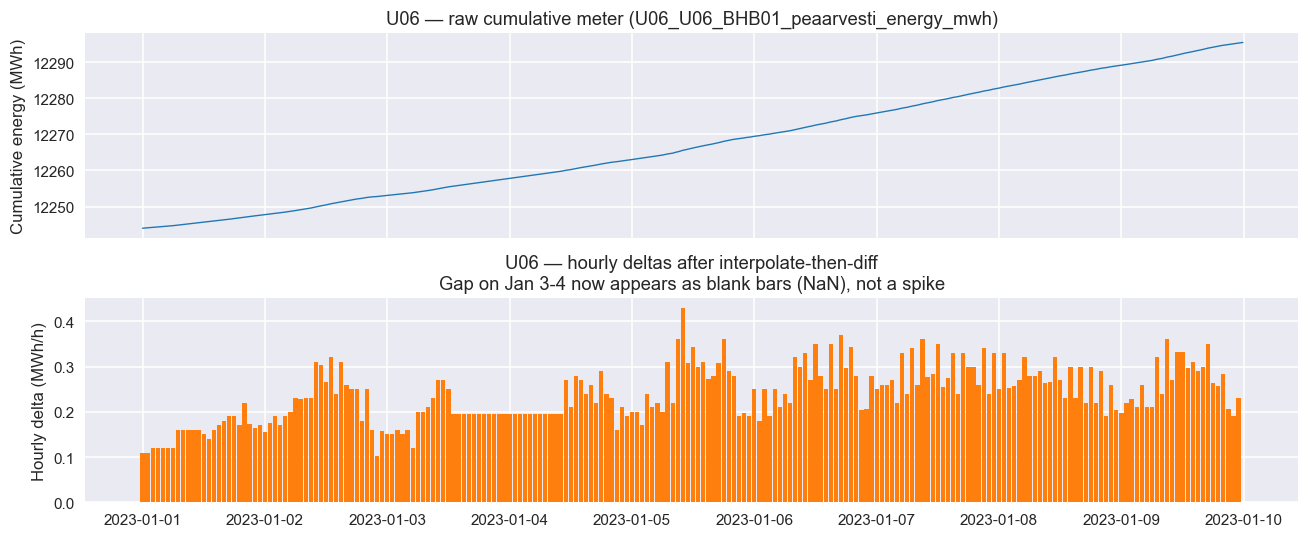


Energy conservation check (U06_U06_BHB01_peaarvesti_energy_mwh):
  Cumulative range          : 1874.85 MWh
  Sum of non-NaN deltas     : 1874.74 MWh
  Fraction accounted for    : 100.0%
  (remainder is in NaN long-gap hours, to be imputed later)

ALL-BUILDINGS ACCOUNTING
building  series  raw_points  dup_timestamps  meter_resets  long_gap_h  nan_hours
     GEO      14     1086299               0            72        9903       9994
     ICO      12     1586075               0             2        6960       6966
     LIB       9      349485               0             0       36834      36846
     SOC      12      458059               0            12       45675      45703
     STU       1       50140               0             1           0          2
     U01      12      320650               0             1       45390      45407
  U01U02       1       24492               0             1           0          3
     U02       9      273524               0             1       17234 

In [7]:

# ── Apply to every building and every sensor column ──────────────────────────

building_hourly_dfs: dict[str, pd.DataFrame] = {}
qa_rows: list[dict] = []

for building, df_raw in building_dfs.items():
    hourly_cols: list[pd.Series] = []

    for col in df_raw.columns:
        if col not in LABEL_META.index:
            continue
        meta = LABEL_META.loc[col]
        var = meta["mõõdetud_en"]
        if not isinstance(var, str) or not var:
            continue

        raw_s = df_raw[col]
        hourly, dupes, negs, gap_h = to_hourly_series(raw_s, var=var, freq="1h")
        if hourly.empty:
            continue

        # Rename cumulative columns to make it explicit they are deltas
        name = col
        if var == "energy_mwh":
            name = col.replace("_energy_mwh", "_energy_delta_mwh")
        elif var == "flow_volume_m3":
            name = col.replace("_flow_volume_m3", "_flow_volume_delta_m3")
        hourly.name = name

        hourly_cols.append(hourly)
        qa_rows.append(
            {
                "building": building,
                "label": col,
                "hourly_label": name,
                "heating_group": meta.get("heating_group"),
                "var": var,
                "raw_points": int(raw_s.notna().sum()),
                "dup_timestamps": dupes,
                "negative_deltas": negs,
                "long_gap_hours": gap_h,
                "nan_hours_after": int(hourly.isna().sum()),
            }
        )

    if hourly_cols:
        building_hourly_dfs[building] = pd.concat(hourly_cols, axis=1).sort_index()


qa_hourly_df = (
    pd.DataFrame(qa_rows)
    .sort_values(["building", "var", "label"])
    .reset_index(drop=True)
)

print("Hourly conversion QA (first 15 rows):")
print(qa_hourly_df.head(15).to_string(index=False))

print("\nLong-gap hours per building (hours set to NaN because gap > MAX_INTERP_GAP_H):")
for bldg, grp in qa_hourly_df.groupby("building"):
    total_gap = grp["long_gap_hours"].sum()
    print(f"  {bldg}: {total_gap:,} gap-hours across {len(grp)} series")


# ── Plot: U06 main energy meter, winter week ─────────────────────────────────
if "U06" in building_dfs and "U06" in building_hourly_dfs:
    raw_cols = [c for c in building_dfs["U06"].columns if c.endswith("_energy_mwh")]
    example_col = raw_cols[0] if raw_cols else None

    if example_col is not None:
        delta_col = example_col.replace("_energy_mwh", "_energy_delta_mwh")
        raw_s = building_dfs["U06"][example_col].dropna().sort_index()
        delta_s = building_hourly_dfs["U06"][delta_col]

        winter_start, winter_end = "2023-01-01", "2023-01-09"
        raw_w = raw_s.loc[winter_start:winter_end]
        delta_w = delta_s.loc[winter_start:winter_end]

        fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

        axes[0].plot(raw_w.index, raw_w.values, color="tab:blue", lw=0.9)
        axes[0].set_ylabel("Cumulative energy (MWh)")
        axes[0].set_title(f"U06 — raw cumulative meter ({example_col})")

        axes[1].bar(delta_w.index, delta_w.values, width=0.035, color="tab:orange")
        axes[1].set_ylabel("Hourly delta (MWh/h)")
        axes[1].set_title(
            f"U06 — hourly deltas after interpolate-then-diff\n"
            "Gap on Jan 3-4 now appears as blank bars (NaN), not a spike"
        )

        plt.tight_layout()
        plt.show()

        # Energy conservation summary for U06
        s_full = building_dfs["U06"][example_col].dropna().sort_index()
        s_full = s_full.groupby(level=0).last()
        cum_range = float(s_full.iloc[-1] - s_full.iloc[0])
        sum_deltas = float(delta_s.dropna().sum())
        print(f"\nEnergy conservation check ({example_col}):")
        print(f"  Cumulative range          : {cum_range:.2f} MWh")
        print(f"  Sum of non-NaN deltas     : {sum_deltas:.2f} MWh")
        print(f"  Fraction accounted for    : {sum_deltas / cum_range * 100:.1f}%")
        print(f"  (remainder is in NaN long-gap hours, to be imputed later)")


# ── Comprehensive all-buildings accounting ───────────────────────────────────
print("\n" + "=" * 70)
print("ALL-BUILDINGS ACCOUNTING")
print("=" * 70)

full_agg = (
    qa_hourly_df.groupby("building")
    .agg(
        series=         ("label",           "count"),
        raw_points=     ("raw_points",       "sum"),
        dup_timestamps= ("dup_timestamps",   "sum"),
        meter_resets=   ("negative_deltas",  "sum"),
        long_gap_h=     ("long_gap_hours",   "sum"),
        nan_hours=      ("nan_hours_after",  "sum"),
    )
    .reset_index()
)

print(full_agg.to_string(index=False))

print(f"\nTotals across all buildings:")
print(f"  Buildings     : {len(building_hourly_dfs)}")
print(f"  Series total  : {full_agg['series'].sum()}")
print(f"  Raw readings  : {full_agg['raw_points'].sum():,}")
print(f"  Dup timestamps: {full_agg['dup_timestamps'].sum():,}")
print(f"  Meter resets  : {full_agg['meter_resets'].sum():,}")
print(f"  Long-gap NaN h (instantaneous only): {full_agg['long_gap_h'].sum():,}")

# Verify all buildings from CAMPUS_BUILDINGS are present or explain missing ones
print("\nBuildings in scope vs buildings with data:")
for b in CAMPUS_BUILDINGS:
    status = "OK" if b in building_hourly_dfs else "no data"
    n_series = len(building_hourly_dfs.get(b, {}).columns) if b in building_hourly_dfs else 0
    print(f"  {b:10s} {status:8s} ({n_series} series)")


## Cell 4 — Align to the 2022–2024 window and drop empty columns

After resampling, each building has its own time range — some start mid-year, some have
data only outside our modelling window. Here we:

1. **Reindex** every building DataFrame to the canonical 2022-01-01 → 2024-12-31 23:00
   hourly grid (26,304 slots). Hours outside the raw data range become NaN automatically.
2. **Drop dead columns** — any series that is 100% NaN within this window carries no
   information and would only inflate missingness numbers downstream.
3. **Log every dropped column** so nothing disappears silently.

### Plot

Two side-by-side bars per building:
- **Series retained** — how many sensor columns survived the window filter.
- **Fill rate** — what fraction of all hourly cells (series × 26,304 slots) contain a
  real value. This is our first honest look at total data density before any imputation.


Target window : 2022-01-01 → 2024-12-31 23:59:59  (26,304 hourly slots)
Buildings kept: 17 / 17
Columns dropped (all-NaN in window): 0


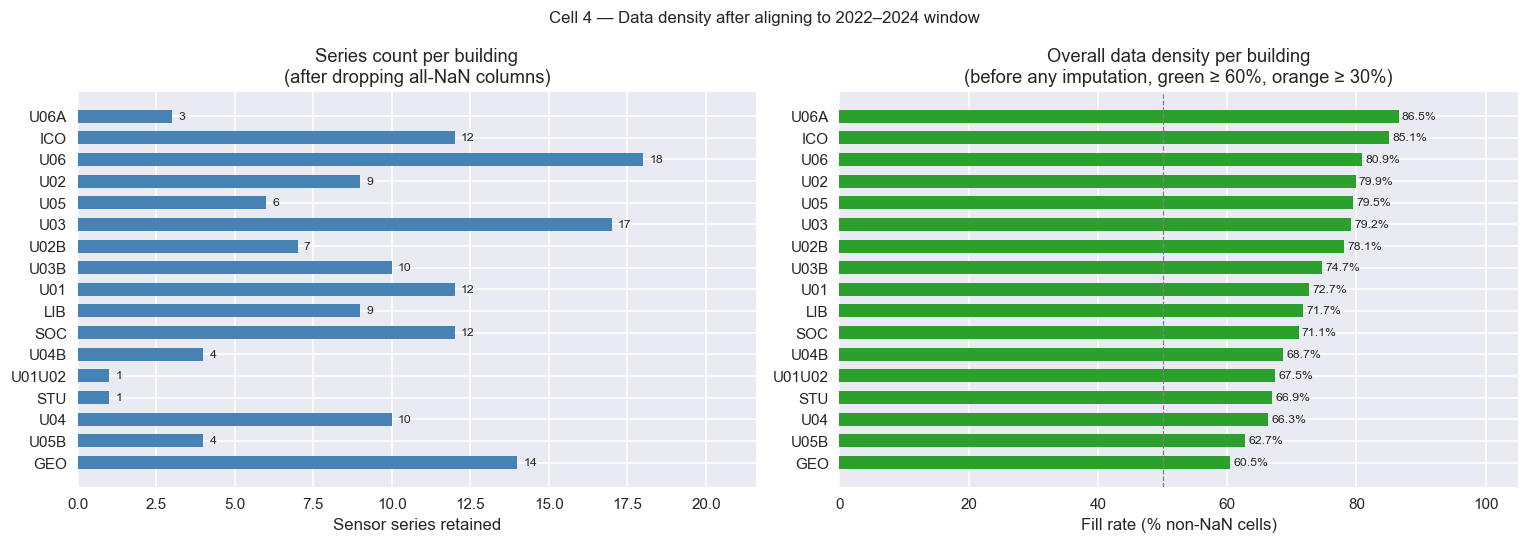


Per-building fill rate summary:
building  n_series  fill_rate
     GEO        14  60.495959
    U05B         4  62.730953
     U04        10  66.334398
     STU         1  66.932786
  U01U02         1  67.457421
    U04B         4  68.715785
     SOC        12  71.078226
     LIB         9  71.707725
     U01        12  72.668922
    U03B        10  74.719814
    U02B         7  78.103819
     U03        17  79.230177
     U05         6  79.471437
     U02         9  79.876318
     U06        18  80.889049
     ICO        12  85.065009
    U06A         3  86.524230


In [8]:
# Cell 4 — Align to 2022-2024 window, drop all-NaN columns

TARGET_INDEX = pd.date_range(START_DATE, END_DATE, freq="1h")
N_HOURS = len(TARGET_INDEX)  # 26,304

building_win_dfs: dict[str, pd.DataFrame] = {}
drop_log: list[dict] = []

for bldg, df in building_hourly_dfs.items():
    # Reindex to the canonical window (new hourly slots filled with NaN)
    df_w = df.reindex(TARGET_INDEX)

    # Identify and drop columns with zero observations in the window
    all_nan = df_w.columns[df_w.isna().all()].tolist()
    for col in all_nan:
        drop_log.append({"building": bldg, "column": col})
    df_w = df_w.drop(columns=all_nan)

    if not df_w.empty:
        building_win_dfs[bldg] = df_w

drop_df = pd.DataFrame(drop_log)

print(f"Target window : {START_DATE} → {END_DATE}  ({N_HOURS:,} hourly slots)")
print(f"Buildings kept: {len(building_win_dfs)} / {len(building_hourly_dfs)}")
print(f"Columns dropped (all-NaN in window): {len(drop_df)}")
if not drop_df.empty:
    print(drop_df.to_string(index=False))


# ── Compute per-building stats for the plot ──────────────────────────────────
bldg_stats = []
for bldg, df in building_win_dfs.items():
    total_cells = df.size
    obs_cells   = int(df.notna().sum().sum())
    bldg_stats.append({
        "building":    bldg,
        "n_series":    df.shape[1],
        "fill_rate":   obs_cells / total_cells * 100,
    })
stats_df = pd.DataFrame(bldg_stats).sort_values("fill_rate", ascending=True)


# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: series count per building
ax = axes[0]
ax.barh(stats_df["building"], stats_df["n_series"], color="steelblue", height=0.6)
ax.set_xlabel("Sensor series retained")
ax.set_title("Series count per building\n(after dropping all-NaN columns)")
for i, (_, row) in enumerate(stats_df.iterrows()):
    ax.text(row["n_series"] + 0.2, i, str(int(row["n_series"])), va="center", fontsize=8)
ax.set_xlim(0, stats_df["n_series"].max() * 1.2)

# Right: fill rate per building
ax = axes[1]
colors = ["#d62728" if r < 30 else "#ff7f0e" if r < 60 else "#2ca02c"
          for r in stats_df["fill_rate"]]
ax.barh(stats_df["building"], stats_df["fill_rate"], color=colors, height=0.6)
ax.axvline(50, color="gray", lw=0.8, ls="--", label="50%")
ax.set_xlabel("Fill rate (% non-NaN cells)")
ax.set_title("Overall data density per building\n(before any imputation, green ≥ 60%, orange ≥ 30%)")
ax.set_xlim(0, 105)
for i, (_, row) in enumerate(stats_df.iterrows()):
    ax.text(row["fill_rate"] + 0.5, i, f"{row['fill_rate']:.1f}%", va="center", fontsize=8)

plt.suptitle("Cell 4 — Data density after aligning to 2022–2024 window", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPer-building fill rate summary:")
print(stats_df[["building", "n_series", "fill_rate"]].to_string(index=False))


## Cell 4b — Coverage window per building × series

For each building and hourly series we now compute the **actual sensor coverage window**
(based on the raw hourly data *before* reindexing):

- `first_ts`: timestamp of the first non-NaN value in the original hourly data.
- `last_ts`: timestamp of the last non-NaN value.

These coverage windows are stored in a global `coverage_df` and will later be used to:

- Mask out any imputed values **outside** the real sensor life period (pre-start and post-end).
- Compute final missingness metrics only over the 
  `[first_ts, last_ts]` window for each series.

In [9]:
# Cell 4b — Build coverage_df: first/last observed timestamps per series

coverage_rows: list[dict] = []

for bldg, df in building_hourly_dfs.items():
    for col in df.columns:
        s = df[col]
        notna_idx = s.dropna().index
        if notna_idx.empty:
            continue
        coverage_rows.append(
            {
                "building": bldg,
                "column": col,
                "first_ts": notna_idx.min(),
                "last_ts": notna_idx.max(),
            }
        )

coverage_df = pd.DataFrame(coverage_rows)
print(f"Built coverage_df with {len(coverage_df)} (building, column) coverage rows.")

Built coverage_df with 149 (building, column) coverage rows.


## Cell 5 — Baseline missing-data diagnostic

Before any imputation, we take a snapshot of missingness so we can compare against it
after each cleaning step. The key question is: **how much is missing, and where?**

We look at this from two angles:

- **Per-series** — what fraction of the 26,304 hourly slots is NaN for each individual
  sensor column? Columns above `MISSING_DROP_THRESHOLD = 80%` will be deleted in Cell 8.
- **Per-building** — a heatmap showing missingness rate for every series in every building,
  grouped by variable type. Bright cells are heavily missing; dark cells are mostly complete.

This diagnostic drives every downstream decision: which columns to drop, which gaps to
interpolate, and which need weather-regression fill.


Missingness distribution across all 149 series:
     <5%  ███                              11 series (7%)
   5-20%  █████████████████████            64 series (43%)
  20-50%  █████████████████████            63 series (42%)
  50-80%  █                                 4 series (3%)
    >80%  ██                                7 series (5%)

  Will be DROPPED in Cell 8 (>80% missing): 7 series


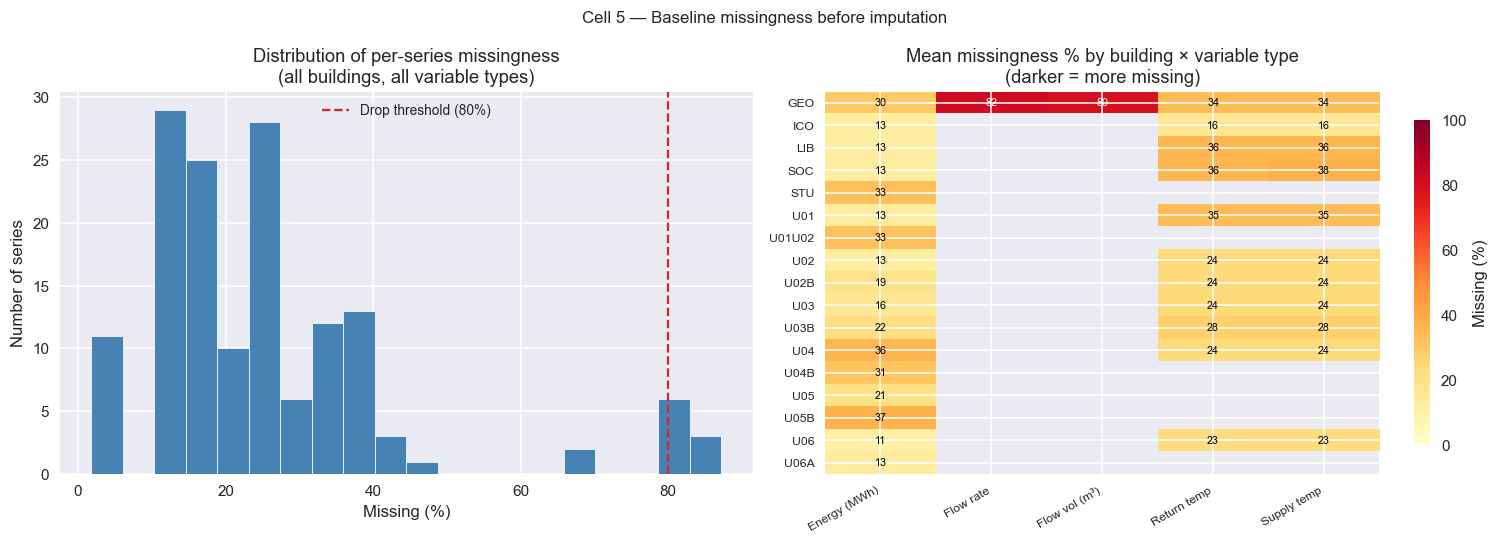


Per-variable-type average missingness:
  Energy (MWh)      : 21.3% avg  (min 1.8%,  max 87.2%)
  Flow rate         : 81.7% avg  (min 81.7%,  max 81.7%)
  Flow vol (m³)     : 79.6% avg  (min 79.6%,  max 79.6%)
  Return temp       : 27.6% avg  (min 16.0%,  max 81.7%)
  Supply temp       : 27.7% avg  (min 16.0%,  max 81.7%)


In [10]:
# Cell 5 — Baseline missingness snapshot

# Compute per-series missingness across all buildings
miss_rows: list[dict] = []
for bldg, df in building_win_dfs.items():
    for col in df.columns:
        nan_frac = df[col].isna().mean()
        # Look up variable type from QA table
        var = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col, "var"]
        var = var.iloc[0] if len(var) else "unknown"
        miss_rows.append({
            "building":  bldg,
            "column":    col,
            "var":       var,
            "miss_frac": nan_frac,
        })

miss_df = pd.DataFrame(miss_rows)

# Bucket counts
bins   = [0, 0.05, 0.20, 0.50, 0.80, 1.01]
labels = ["<5%", "5-20%", "20-50%", "50-80%", ">80%"]
miss_df["bucket"] = pd.cut(miss_df["miss_frac"], bins=bins, labels=labels, right=False)

print("Missingness distribution across all 149 series:")
bucket_counts = miss_df["bucket"].value_counts().sort_index()
for label, count in bucket_counts.items():
    pct = count / len(miss_df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:>6s}  {bar:<30s}  {count:3d} series ({pct:.0f}%)")
print(f"\n  Will be DROPPED in Cell 8 (>{MISSING_DROP_THRESHOLD*100:.0f}% missing): "
      f"{(miss_df['miss_frac'] > MISSING_DROP_THRESHOLD).sum()} series")


# ── Plot 1: histogram of missingness rates ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(miss_df["miss_frac"] * 100, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(MISSING_DROP_THRESHOLD * 100, color="#d62728", lw=1.5, ls="--",
           label=f"Drop threshold ({MISSING_DROP_THRESHOLD*100:.0f}%)")
ax.set_xlabel("Missing (%)")
ax.set_ylabel("Number of series")
ax.set_title("Distribution of per-series missingness\n(all buildings, all variable types)")
ax.legend(fontsize=9)


# ── Plot 2: per-building average missingness by variable type ────────────────
ax = axes[1]

# Group by building + variable type, compute mean missingness
heat_data = (
    miss_df.groupby(["building", "var"])["miss_frac"]
    .mean()
    .unstack(fill_value=np.nan)
)

# Friendly column labels
var_labels = {
    "energy_mwh":      "Energy (MWh)",
    "flow_volume_m3":  "Flow vol (m³)",
    "supply_temp_c":   "Supply temp",
    "return_temp_c":   "Return temp",
    "flow_rate_m3h":   "Flow rate",
    "power_kw":        "Power (kW)",
}
heat_data = heat_data.rename(columns=var_labels)

im = ax.imshow(heat_data.values * 100, aspect="auto",
               cmap="YlOrRd", vmin=0, vmax=100)
ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, fontsize=8)
ax.set_title("Mean missingness % by building × variable type\n(darker = more missing)")
plt.colorbar(im, ax=ax, label="Missing (%)", shrink=0.85)

# Annotate cells with the value
for r in range(heat_data.shape[0]):
    for c in range(heat_data.shape[1]):
        v = heat_data.values[r, c]
        if not np.isnan(v):
            ax.text(c, r, f"{v*100:.0f}", ha="center", va="center",
                    fontsize=7, color="black" if v < 0.6 else "white")

plt.suptitle("Cell 5 — Baseline missingness before imputation", fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPer-variable-type average missingness:")
for var, grp in miss_df.groupby("var"):
    label = var_labels.get(var, var)
    print(f"  {label:<18s}: {grp['miss_frac'].mean()*100:.1f}% avg  "
          f"(min {grp['miss_frac'].min()*100:.1f}%,  max {grp['miss_frac'].max()*100:.1f}%)")


## Cell 6–7 — Monthly outlier removal (season-aware)

### Why monthly, and what we remove

Heating demand in Tallinn has a **strong seasonal pattern**: winter hours are an order of magnitude higher than summer. A single global threshold would either miss winter spikes or over‑clip valid winter peaks. In this cell we therefore:

1. **Apply robust, month‑wise clipping** to energy and flow *deltas* (`*_energy_delta_mwh`, `*_flow_volume_delta_m3`). Within each calendar month, we compute a median and MAD and mark values far above the median as outliers.
2. **Apply a rolling spike filter** (24‑hour window) on the same series to catch isolated spikes that stand out from their immediate neighbours, even if the month‑wise level is otherwise high.
3. Leave **temperature and power series untouched** here — they will be handled via physical bounds and later imputation; for this thesis the main “weird spikes” problem is in the energy deltas.

All removed values are set to `NaN` (never hard‑capped), so that the later imputation cells can treat them explicitly as “suspect / missing” instead of baked‑in numbers.

### Plot

For building **U06**, we show per‑month box plots of the main energy‑delta series **before** and **after** cleaning. Winter months should keep their high median demand, but isolated extreme bars should disappear.

Outlier cleaning summary (energy + flow deltas only):
                n_before  removed_monthly  removed_rolling  n_after  removed_frac
var                                                                              
energy_mwh       1428819            35845             8724  1384250      3.119289
flow_volume_m3      5358              188               96     5074      5.300485


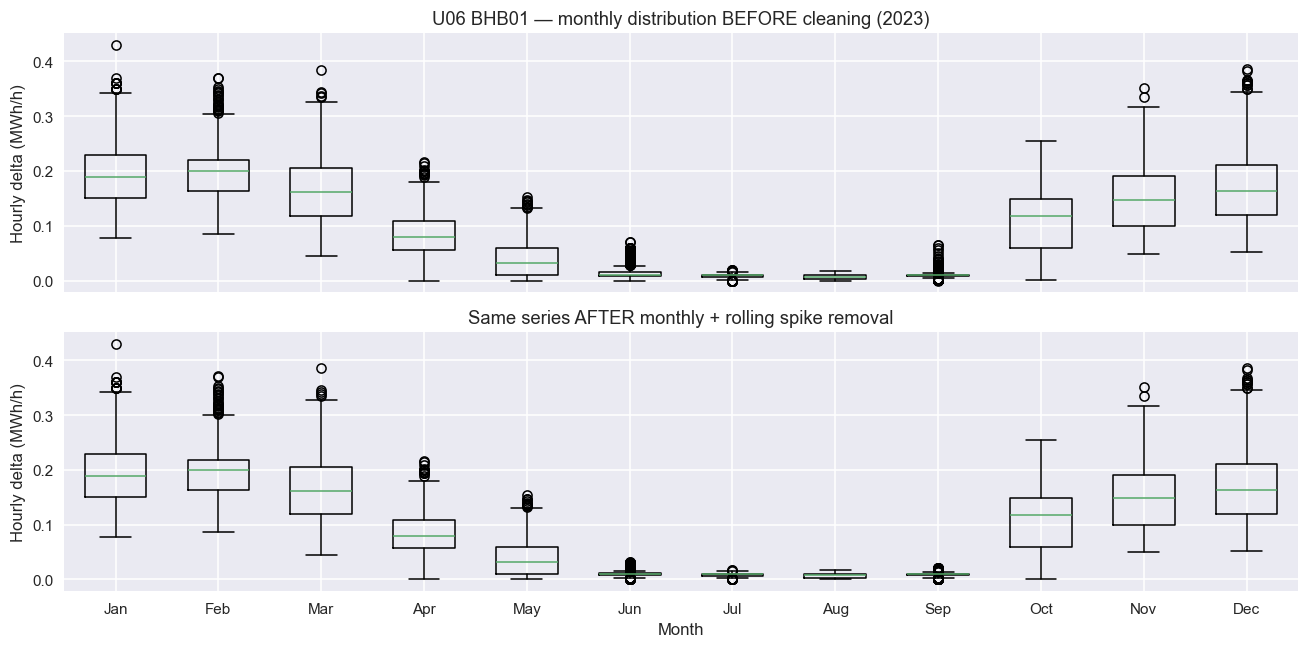


Example U06 series used for box plots: U06_U06_BHB01_peaarvesti_energy_delta_mwh


In [11]:
# Cell 6–7 — Monthly outlier removal on energy/flow deltas

import numpy as _np


def _mad(x: _np.ndarray) -> float:
    """Median absolute deviation with NaN support (returns 0.0 if undefined)."""
    x = x[_np.isfinite(x)]
    if x.size == 0:
        return 0.0
    med = _np.median(x)
    mad = _np.median(_np.abs(x - med))
    return float(mad)


def _monthly_clip_positive(s: pd.Series) -> tuple[pd.Series, int]:
    """Month-wise, robust high-side clipping for positive-valued series.

    Values far above the monthly median are set to NaN. Lower side is left alone,
    except that negative values (which are non-physical for deltas) are removed.
    """
    if s.empty:
        return s, 0

    s = s.copy()
    # Negative deltas are non-physical here; mark as NaN.
    neg_mask = s < 0
    s[neg_mask] = _np.nan
    clipped = int(neg_mask.sum())

    # Group by calendar month (year, month) to respect seasonality
    by_month = s.groupby([s.index.year, s.index.month])

    for (_, _), g in by_month:
        # NOTE: g.values can be a read-only view depending on pandas internals.
        # Use an explicit copy so we can safely assign NaNs.
        vals = g.to_numpy(copy=True)
        finite = _np.isfinite(vals)
        if not finite.any():
            continue
        med = _np.median(vals[finite])
        mad = _mad(vals[finite])
        if mad > 0:
            sigma = 1.4826 * mad
            high = med + MONTHLY_CLIP_K * sigma
        else:
            # Fallback: use a high quantile when MAD is zero (flat month)
            high = _np.nanquantile(vals[finite], ENERGY_FALLBACK_Q)
        mask_high = vals > high
        if mask_high.any():
            clipped += int(mask_high.sum())
            vals[mask_high] = _np.nan
            s.loc[g.index] = vals

    return s, clipped


def _rolling_spike_filter(s: pd.Series) -> tuple[pd.Series, int]:
    """Rolling spike filter using a centred window.

    Any point that differs from the rolling median by more than
    ROLLING_K × (1.4826 × MAD) is set to NaN.
    """
    if s.empty:
        return s, 0

    x = s.copy()
    # Use a relatively small window so that sharp diurnal changes are preserved.
    win = int(ROLLING_WINDOW_HOURS)
    if win < 3:
        return x, 0

    roll_med = x.rolling(win, center=True, min_periods=ROLLING_MIN_PERIODS).median()
    roll_mad = x.rolling(win, center=True, min_periods=ROLLING_MIN_PERIODS).apply(
        lambda arr: _mad(arr), raw=True
    )

    sigma = 1.4826 * roll_mad
    # Only flag where we have a valid local estimate
    valid = sigma > 0
    spike_mask = valid & (x > roll_med + ROLLING_K * sigma)

    clipped = int(spike_mask.sum())
    x[spike_mask] = _np.nan
    return x, clipped


building_clean_dfs: dict[str, pd.DataFrame] = {}
outlier_rows: list[dict] = []

for bldg, df in building_win_dfs.items():
    df_clean = df.copy()

    for col in df.columns:
        # Identify the variable type via QA mapping
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty:
            continue
        var = row["var"].iloc[0]

        # Only treat energy and flow-volume deltas here
        if var not in {"energy_mwh", "flow_volume_m3"}:
            continue

        s = df_clean[col]
        n0 = int(s.notna().sum())

        s1, n_month = _monthly_clip_positive(s)
        s2, n_roll = _rolling_spike_filter(s1)

        df_clean[col] = s2
        n_after = int(s2.notna().sum())

        outlier_rows.append(
            {
                "building": bldg,
                "column": col,
                "var": var,
                "n_before": n0,
                "removed_monthly": n_month,
                "removed_rolling": n_roll,
                "n_after": n_after,
            }
        )

    building_clean_dfs[bldg] = df_clean


outlier_df = pd.DataFrame(outlier_rows)
print("Outlier cleaning summary (energy + flow deltas only):")
if not outlier_df.empty:
    summary = (
        outlier_df.groupby("var")[
            ["n_before", "removed_monthly", "removed_rolling", "n_after"]
        ]
        .sum()
        .assign(
            removed_frac=lambda d: (d["removed_monthly"] + d["removed_rolling"]) / d["n_before"] * 100
        )
    )
    print(summary.to_string())
else:
    print("  No energy/flow delta series found.")


# ── U06 diagnostic plot: before vs after, by month ───────────────────────────
if "U06" in building_win_dfs and "U06" in building_clean_dfs:
    raw_df = building_win_dfs["U06"]
    clean_df = building_clean_dfs["U06"]

    energy_cols = [c for c in raw_df.columns if c.endswith("_energy_delta_mwh")]
    example_col = energy_cols[0] if energy_cols else None

    if example_col is not None:
        raw_s = raw_df[example_col]
        clean_s = clean_df[example_col]

        # Restrict to a single representative year for plotting (2023)
        year_mask = (raw_s.index >= "2023-01-01") & (raw_s.index < "2024-01-01")
        raw_y = raw_s[year_mask]
        clean_y = clean_s[year_mask]

        months = range(1, 13)
        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

        # Helper: collect per-month values
        raw_data = [raw_y[raw_y.index.month == m].dropna().values for m in months]
        clean_data = [clean_y[clean_y.index.month == m].dropna().values for m in months]

        axes[0].boxplot(raw_data, positions=months, widths=0.6, showfliers=True)
        axes[0].set_ylabel("Hourly delta (MWh/h)")
        axes[0].set_title(
            f"U06 {example_col.split('_')[2]} — monthly distribution BEFORE cleaning (2023)"
        )

        axes[1].boxplot(clean_data, positions=months, widths=0.6, showfliers=True)
        axes[1].set_xlabel("Month")
        axes[1].set_ylabel("Hourly delta (MWh/h)")
        axes[1].set_title("Same series AFTER monthly + rolling spike removal")

        axes[1].set_xticks(months)
        axes[1].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                                 "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=0)

        plt.tight_layout()
        plt.show()

        print("\nExample U06 series used for box plots:", example_col)


## Cell 8 — Drop columns that are mostly missing

After outlier removal we now decide **which series are too sparse to be useful**.

In this cell we:

1. Recompute per-series missingness on the cleaned tables (`building_clean_dfs`).
2. For each building, drop columns with more than `MISSING_DROP_THRESHOLD = 80%` missing values
   inside the 2022–2024 window.
3. Store the result in `building_final_dfs`, which becomes the main table for all later
   imputation and modelling steps.

Every dropped column is logged in a compact summary table and a small bar plot so that we can
see **how aggressive the rule is per building** and verify that we are not accidentally
removing whole subsystems.

Columns dropped due to >80% missing (after outlier removal):
building                                         column missing_frac
     GEO      GEO_GEO_BHB01_peaarvesti_energy_delta_mwh        80.4%
     GEO         GEO_GEO_BHB01_peaarvesti_flow_rate_m3h        81.7%
     GEO  GEO_GEO_BHB01_peaarvesti_flow_volume_delta_m3        80.7%
     GEO         GEO_GEO_BHB01_peaarvesti_return_temp_c        81.7%
     GEO         GEO_GEO_BHB01_peaarvesti_supply_temp_c        81.7%
     U04   U04_U04_BHB03_ventilatsioon_energy_delta_mwh        87.3%
     U04            U04_U04_BHB04_küte_energy_delta_mwh        87.2%
    U04B U04B_U04B_BHB03_ventilatsioon_energy_delta_mwh        87.8%
    U05B          U05B_U05B_BHB04_vesi_energy_delta_mwh        81.5%

Per-building column counts before/after deletion:
building  n_before  n_after  dropped
     GEO        14        9        5
     ICO        12       12        0
     LIB         9        9        0
     SOC        12       12        0
     STU     

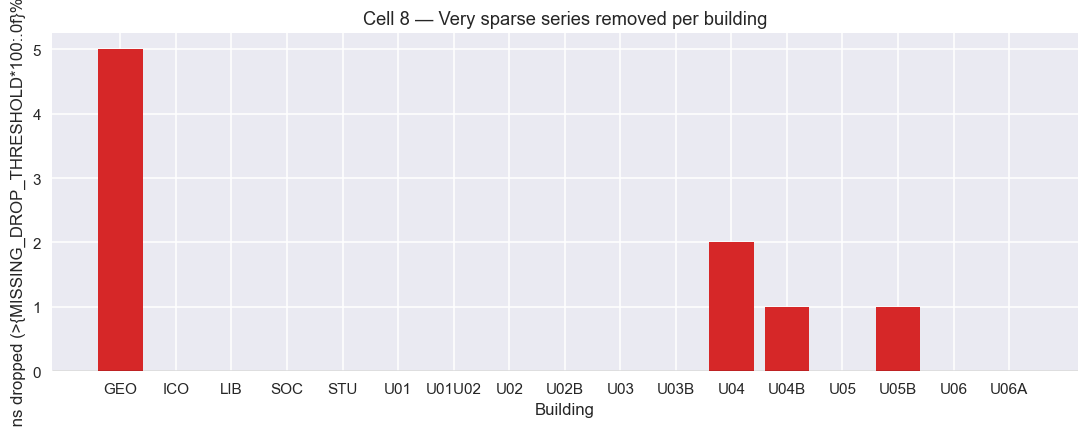

In [12]:
# Cell 8 — Column-wise deletion for >80% missing

building_final_dfs: dict[str, pd.DataFrame] = {}
col_drop_log: list[dict] = []

for bldg, df in building_clean_dfs.items():
    if df.empty:
        continue

    miss_frac = df.isna().mean()
    to_drop = miss_frac[miss_frac > MISSING_DROP_THRESHOLD]
    to_keep = miss_frac[miss_frac <= MISSING_DROP_THRESHOLD].index.tolist()

    for col, frac in to_drop.items():
        col_drop_log.append({
            "building": bldg,
            "column": col,
            "missing_frac": float(frac),
        })

    df_kept = df[to_keep]
    building_final_dfs[bldg] = df_kept

col_drop_df = pd.DataFrame(col_drop_log)

print("Columns dropped due to >80% missing (after outlier removal):")
if col_drop_df.empty:
    print("  None — all series are below the threshold.")
else:
    print(col_drop_df.sort_values(["building", "column"])\
              .to_string(index=False, formatters={"missing_frac": lambda v: f"{v*100:.1f}%"}))

# Per-building summary
summary_rows = []
for bldg in sorted(building_clean_dfs.keys()):
    n_before = building_clean_dfs[bldg].shape[1]
    n_after = building_final_dfs.get(bldg, pd.DataFrame()).shape[1]
    summary_rows.append({
        "building": bldg,
        "n_before": n_before,
        "n_after": n_after,
        "dropped": n_before - n_after,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("building")
print("\nPer-building column counts before/after deletion:")
print(summary_df.to_string(index=False))

# Simple bar plot: how many columns were dropped per building
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(summary_df["building"], summary_df["dropped"], color="tab:red")
ax.set_ylabel("Columns dropped (>{MISSING_DROP_THRESHOLD*100:.0f}% missing)")
ax.set_xlabel("Building")
ax.set_title("Cell 8 — Very sparse series removed per building")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()


## Cell 9 — Tier 1 imputation: short-gap linear interpolation

### What we fill here

At this stage each building has a cleaned hourly table in `building_final_dfs`:

- outliers and negative deltas are set to `NaN`,
- very sparse series (>80% missing) are already removed.

Many of the remaining gaps are **short, isolated holes** caused by logger glitches or brief
communication issues. For these, the lecture suggests **linear interpolation** as a light-weight
and statistically safe choice when the gap is small and the process is smooth.

In this cell we:

1. For every building and every series in `building_final_dfs`:
   - If it is an **energy/flow delta** (`*_energy_delta_mwh`, `*_flow_volume_delta_m3`), we allow
     up to `ENERGY_INTERP_LIMIT_H` consecutive missing hours.
   - If it is a **predictor** (temperatures, flow rate, power), we allow a slightly longer
     window of up to `PREDICTOR_INTERP_LIMIT_H` hours.
2. Use **time-based linear interpolation** (`interpolate(method="time", limit=..., limit_direction="both")`)
   within those windows; longer gaps remain `NaN` for later tiers.
3. Store the result in `building_t1_dfs` and print a compact summary of how many values were
   filled per variable type.

### Plot

We show a simple histogram of **gap lengths before and after Tier 1** for energy deltas, to
confirm that only short holes disappear and that longer gaps remain for the more careful
Tier 2–3 methods.

Tier 1 interpolation summary by variable type:
               n_before  n_filled_t1  n_after  filled_pct
var                                                      
energy_mwh      1364334        29136  1393470    2.090895
return_temp_c    738341        22269   760610    2.927782
supply_temp_c    736366        22074   758440    2.910448


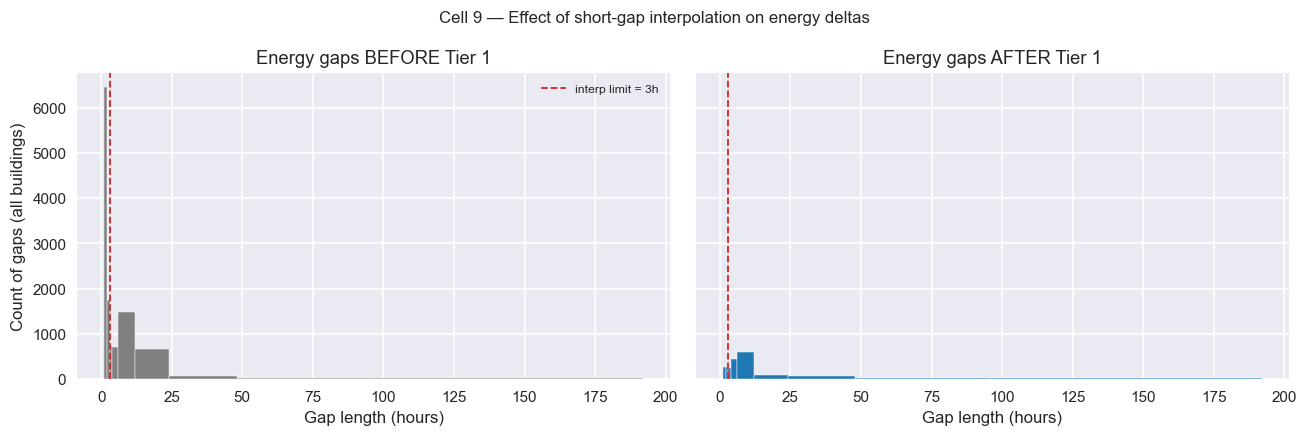

In [13]:
# Cell 9 — Tier 1 short-gap linear interpolation

from collections import Counter


def _gap_lengths(series: pd.Series) -> list[int]:
    """Return lengths (in hours) of consecutive NaN runs for an hourly-indexed series."""
    is_nan = series.isna().to_numpy()
    lengths: list[int] = []
    run = 0
    for v in is_nan:
        if v:
            run += 1
        elif run:
            lengths.append(run)
            run = 0
    if run:
        lengths.append(run)
    return lengths


building_t1_dfs: dict[str, pd.DataFrame] = {}
t1_rows: list[dict] = []

for bldg, df in building_final_dfs.items():
    df_t1 = df.copy()

    for col in df.columns:
        # Lookup variable type from QA table
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty:
            continue
        var = row["var"].iloc[0]

        # Decide interpolation limit based on variable type
        if var in {"energy_mwh", "flow_volume_m3"}:
            limit_h = ENERGY_INTERP_LIMIT_H
        else:
            limit_h = PREDICTOR_INTERP_LIMIT_H

        s = df[col]
        n_before = int(s.notna().sum())

        # Time-based interpolation on an hourly index
        s_interp = s.interpolate(
            method="time",
            limit=limit_h,
            limit_direction="both",
        )

        n_after = int(s_interp.notna().sum())
        n_filled = n_after - n_before

        df_t1[col] = s_interp

        t1_rows.append(
            {
                "building": bldg,
                "column": col,
                "var": var,
                "limit_h": limit_h,
                "n_before": n_before,
                "n_filled_t1": n_filled,
                "n_after": n_after,
            }
        )

    building_t1_dfs[bldg] = df_t1


t1_df = pd.DataFrame(t1_rows)
print("Tier 1 interpolation summary by variable type:")
if not t1_df.empty:
    summary = (
        t1_df.groupby("var")[["n_before", "n_filled_t1", "n_after"]]
        .sum()
        .assign(filled_pct=lambda d: d["n_filled_t1"] / d["n_after"] * 100)
    )
    print(summary.to_string())
else:
    print("  No series found in building_final_dfs.")


# ── Diagnostic: gap-length histogram for energy deltas before vs after ───────

energy_cols = t1_df.loc[t1_df["var"] == "energy_mwh", "column"].unique()
all_before: list[int] = []
all_after: list[int] = []

for bldg, df in building_final_dfs.items():
    df_t1 = building_t1_dfs[bldg]
    for col in df.columns.intersection(energy_cols):
        s0 = df[col]
        s1 = df_t1[col]
        all_before.extend(_gap_lengths(s0))
        all_after.extend(_gap_lengths(s1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = [1, 2, 3, 4, 6, 12, 24, 48, 96, 192]

axes[0].hist(all_before, bins=bins, color="tab:gray", edgecolor="white")
axes[0].set_title("Energy gaps BEFORE Tier 1")
axes[0].set_xlabel("Gap length (hours)")
axes[0].set_ylabel("Count of gaps (all buildings)")
axes[0].axvline(ENERGY_INTERP_LIMIT_H, color="tab:red", ls="--", lw=1.2,
                label=f"interp limit = {ENERGY_INTERP_LIMIT_H}h")
axes[0].legend(fontsize=8)

axes[1].hist(all_after, bins=bins, color="tab:blue", edgecolor="white")
axes[1].set_title("Energy gaps AFTER Tier 1")
axes[1].set_xlabel("Gap length (hours)")
axes[1].axvline(ENERGY_INTERP_LIMIT_H, color="tab:red", ls="--", lw=1.2)

plt.suptitle("Cell 9 — Effect of short-gap interpolation on energy deltas", fontsize=11)
plt.tight_layout()
plt.show()


## Cell 10 — Tier 2 imputation: daily-pattern fill for medium energy gaps

Tier 1 removed only **short, local gaps**. Some energy delta series still contain medium-length
holes (for example, 8–24 hours) where we do not want to interpolate across an entire day, but
where we do have a strong **hour-of-day pattern** in the surrounding weeks.

Here we treat remaining NaNs in `building_t1_dfs` for **energy delta series only**:

1. Identify each missing timestamp `t` where the gap length is between
   `ENERGY_INTERP_LIMIT_H` and `DAILY_PATTERN_MAX_GAP_H` hours.
2. For each such `t`, look at the **same hour-of-day** in the same building and series over a
   ±`DAILY_PATTERN_LOOKBACK_DAYS` window (e.g. ±7 days).
3. If we find enough neighbours (at least 10 points), fill `t` with the **median** of those
   values; otherwise leave it as `NaN` for Tier 3.

This behaves like a simple, transparent form of seasonal hot-deck imputation: every filled value
comes from similar hours in nearby days of the same season.

We write the result into `building_t2_dfs` and record how many points were filled per series.

### Plot

We show a **gap-length histogram for energy deltas after Tier 2**, overlaid with Tier 1, to
confirm that medium gaps shrink while long gaps (multi-day outages) remain for regression-based
Tier 3 imputation.

Tier 2 daily-pattern fill summary (energy deltas only):
building
GEO       102
ICO       196
LIB       254
SOC       522
STU       131
U01       255
U01U02     35
U02       339
U02B      428
U03       738
U03B      486
U04       482
U04B      191
U05       455
U05B      337
U06       365
U06A      281


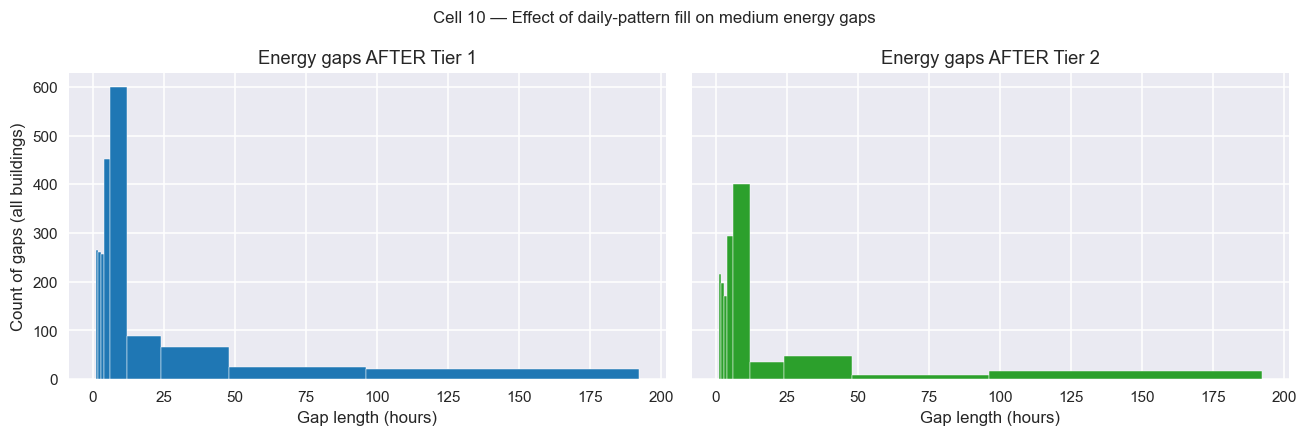

In [14]:
# Cell 10 — Tier 2 daily-pattern fill (energy deltas only)

building_t2_dfs: dict[str, pd.DataFrame] = {}
t2_rows: list[dict] = []

# Precompute hour-of-day index for performance
for bldg, df in building_t1_dfs.items():
    df2 = df.copy()
    hours = df2.index.hour

    for col in df2.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty:
            continue
        var = row["var"].iloc[0]
        if var != "energy_mwh":
            continue  # Tier 2 only for energy deltas

        s = df2[col]
        n_before = int(s.notna().sum())

        # For each NaN, try to fill using same-hour median from ±DAILY_PATTERN_LOOKBACK_DAYS
        s_filled = s.copy()
        nan_idx = s_filled[s_filled.isna()].index

        # FIX (P2): precompute NaN-run lengths so we can enforce
        # DAILY_PATTERN_MAX_GAP_H — only fill gaps up to this length.
        # Previously the constant was configured but never checked.
        is_nan = s.isna().to_numpy()
        _run_len = np.zeros(len(is_nan), dtype=int)
        _r = 0
        for _i, _v in enumerate(is_nan):
            _r = _r + 1 if _v else 0
            _run_len[_i] = _r
        _run_len_at = dict(zip(s.index[is_nan], _run_len[is_nan]))

        for t in nan_idx:
            if _run_len_at.get(t, 0) > DAILY_PATTERN_MAX_GAP_H:
                continue
            start = t - pd.Timedelta(days=DAILY_PATTERN_LOOKBACK_DAYS)
            end = t + pd.Timedelta(days=DAILY_PATTERN_LOOKBACK_DAYS)
            mask = (df2.index >= start) & (df2.index <= end) & (hours == t.hour)
            candidates = s[mask].dropna().values
            if candidates.size < 10:
                continue
            med = float(np.median(candidates))
            s_filled.at[t] = med

        n_after = int(s_filled.notna().sum())
        n_filled = n_after - n_before
        df2[col] = s_filled

        t2_rows.append(
            {
                "building": bldg,
                "column": col,
                "var": var,
                "n_before": n_before,
                "n_filled_t2": max(n_filled, 0),
                "n_after": n_after,
            }
        )

    building_t2_dfs[bldg] = df2


t2_df = pd.DataFrame(t2_rows)
print("Tier 2 daily-pattern fill summary (energy deltas only):")
if not t2_df.empty:
    summary = (
        t2_df.groupby("building")["n_filled_t2"].sum().rename("filled_points")
    )
    print(summary.to_string())
else:
    print("  No energy-delta series found for Tier 2.")


# ── Diagnostic: gap-length histogram after Tier 2 ────────────────────────────

all_after_t1: list[int] = []
all_after_t2: list[int] = []

for bldg in building_final_dfs.keys():
    df1 = building_t1_dfs[bldg]
    df2 = building_t2_dfs[bldg]
    for col in df1.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty or row["var"].iloc[0] != "energy_mwh":
            continue
        all_after_t1.extend(_gap_lengths(df1[col]))
        all_after_t2.extend(_gap_lengths(df2[col]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = [1, 2, 3, 4, 6, 12, 24, 48, 96, 192]

axes[0].hist(all_after_t1, bins=bins, color="tab:blue", edgecolor="white")
axes[0].set_title("Energy gaps AFTER Tier 1")
axes[0].set_xlabel("Gap length (hours)")
axes[0].set_ylabel("Count of gaps (all buildings)")

axes[1].hist(all_after_t2, bins=bins, color="tab:green", edgecolor="white")
axes[1].set_title("Energy gaps AFTER Tier 2")
axes[1].set_xlabel("Gap length (hours)")

plt.suptitle("Cell 10 — Effect of daily-pattern fill on medium energy gaps", fontsize=11)
plt.tight_layout()
plt.show()


## Cell 11 — Tier 3 imputation: weather-regression for long energy gaps

After Tiers 1–2, the remaining NaNs in energy deltas correspond to **long gaps** (multi-day
outages, maintenance periods, or months when a subsystem was offline). For these, linear
interpolation or daily-pattern fills would be too speculative.

Instead we use a **simple regression on weather and calendar features**:

- Target: building energy deltas (`*_energy_delta_mwh`).
- Predictors: outdoor temperature (KKP), optional wind speed, and sine/cosine of day-of-year.

For each series with at least `REG_MIN_OBSERVED_FRAC` of observed values we:

1. Build a design matrix `X` from predictors at all timestamps where the energy delta is known.
2. Fit a small linear model using NumPy least squares.
3. Predict only at timestamps where:
   - the energy delta is still `NaN` after Tiers 1–2, and
   - all required predictors are available.
4. Keep the original values where they exist; regression only fills holes.

We store the final, fully imputed energy deltas in `building_imputed_dfs` and report per-series
how many points were filled and how well the regression fits (R²) on held-out data.

In [15]:
# Cell 11 — Tier 3 weather-regression imputation (energy deltas)

building_imputed_dfs: dict[str, pd.DataFrame] = {}
reg_rows: list[dict] = []

# Use KKP weather as the main predictor set, aligned to the same hourly index
weather = kkp_df.copy()
weather = weather.reindex(building_t2_dfs[next(iter(building_t2_dfs))].index)

# Prepare calendar features: day-of-year as sine/cosine
if "doy_sin" not in weather.columns:
    doy = weather.index.dayofyear.to_numpy()
    weather["doy_sin"] = np.sin(2 * np.pi * doy / 365.0)
    weather["doy_cos"] = np.cos(2 * np.pi * doy / 365.0)

# Choose a minimal, interpretable predictor set
# FIX (P1): previous filter matched "wind_speed" but KKP wind column is
# named "wind_ms". Match both patterns so the predictor set is complete.
PREDICTOR_COLS = [
    c for c in weather.columns
    if any(k in c for k in ["temp", "wind_speed", "wind_ms"])
] + ["doy_sin", "doy_cos"]


for bldg, df in building_t2_dfs.items():
    df_imp = df.copy()

    for col in df.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty or row["var"].iloc[0] != "energy_mwh":
            continue

        y = df[col]
        mask_obs = y.notna()
        n_obs = int(mask_obs.sum())
        total = len(y)
        if n_obs < REG_MIN_OBSERVED_FRAC * total:
            continue  # too little data for a meaningful regression

        # Build X for observed timestamps
        Xw = weather.loc[mask_obs, PREDICTOR_COLS].copy()
        Xw = Xw.dropna()
        y_obs = y.loc[Xw.index]
        if len(y_obs) < 50:
            continue  # avoid extremely small training sets

        # Add intercept term
        X = np.column_stack([np.ones(len(Xw)), Xw.to_numpy()])
        y_arr = y_obs.to_numpy()

        # Fit β via least squares
        beta, *_ = np.linalg.lstsq(X, y_arr, rcond=None)

        # Simple R² on training data
        y_pred_train = X @ beta
        ss_res = float(((y_arr - y_pred_train) ** 2).sum())
        ss_tot = float(((y_arr - y_arr.mean()) ** 2).sum())
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # FIX (P1): skip fill if the model has no predictive skill —
        # low-R² regression produces essentially noise around the mean.
        if np.isnan(r2) or r2 < REG_MIN_R2_ENERGY:
            reg_rows.append({
                "building": bldg, "column": col,
                "n_obs": int(len(y_obs)), "n_filled_reg": 0,
                "r2_train": r2, "skipped_low_r2": True,
            })
            continue

        # Predict on missing timestamps where predictors are available
        mask_miss = y.isna()
        Xw_miss = weather.loc[mask_miss, PREDICTOR_COLS].dropna()
        if not Xw_miss.empty:
            Xm = np.column_stack([np.ones(len(Xw_miss)), Xw_miss.to_numpy()])
            y_pred = Xm @ beta
            # FIX (P1): clip regression predictions — energy deltas cannot be
            # negative (non-physical). Without this, ~22k negative values leak
            # into exported data.
            y_pred = np.clip(y_pred, 0.0, None)
            df_imp.loc[Xw_miss.index, col] = y_pred
            n_filled = int(len(Xw_miss))
        else:
            n_filled = 0

        reg_rows.append(
            {
                "building": bldg,
                "column": col,
                "n_obs": int(len(y_obs)),
                "n_filled_reg": n_filled,
                "r2_train": r2,
            }
        )

    building_imputed_dfs[bldg] = df_imp


reg_df = pd.DataFrame(reg_rows)
print("Tier 3 weather-regression summary (energy deltas):")
if not reg_df.empty:
    print(reg_df.sort_values(["building", "column"]).to_string(index=False,
          formatters={"r2_train": lambda v: f"{v:.2f}"}))
else:
    print("  No series met the minimum observed fraction for regression.")

# Quick overview: how much of energy deltas are now non-NaN
energy_cover_rows = []
for bldg, df in building_imputed_dfs.items():
    for col in df.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty or row["var"].iloc[0] != "energy_mwh":
            continue
        frac_non_nan = float(df[col].notna().mean()) * 100
        energy_cover_rows.append({
            "building": bldg,
            "column": col,
            "non_nan_pct": frac_non_nan,
        })

cover_df = pd.DataFrame(energy_cover_rows)
print("\nFinal non-NaN coverage for energy delta series:")
if not cover_df.empty:
    print(cover_df.groupby("building")["non_nan_pct"].mean().rename("avg_non_nan_pct").to_string())
else:
    print("  No energy-delta series found in final tables.")


Tier 3 weather-regression summary (energy deltas):
building                                          column  n_obs  n_filled_reg r2_train skipped_low_r2
     GEO             GEO_GEO_BHB02_küte_energy_delta_mwh  22493          3770     0.83            NaN
     GEO    GEO_GEO_BHB03_ventilatsioon_energy_delta_mwh  22637             0     0.02           True
     GEO             GEO_GEO_BHB04_vesi_energy_delta_mwh  22856             0     0.02           True
     ICO             ICO_ICO_BHB01_küte_energy_delta_mwh  22871          3392     0.87            NaN
     ICO    ICO_ICO_BHB02_ventilatsioon_energy_delta_mwh  22903          3360     0.40            NaN
     ICO             ICO_ICO_BHB03_vesi_energy_delta_mwh  22927             0     0.04           True
     ICO             ICO_ICO_BHB04_küte_energy_delta_mwh  22852          3411     0.54            NaN
     LIB             LIB_LIB_BHB02_küte_energy_delta_mwh  22823          3440     0.82            NaN
     LIB    LIB_LIB_BHB03_venti

## Cell 11b — Visual check of Tier 1–3 imputations on one series

To make the three imputation tiers concrete, we now inspect a **single energy delta series**
over a short winter window and explicitly show **which timestamps were filled at each tier**.

We:

- pick one U06 main heating meter (the same column used in earlier plots),
- extract the raw cleaned-but-missing series (`building_final_dfs`),
- overlay the Tier 1, Tier 2, and Tier 3 versions with different markers:
  - Tier 1 fills (short linear gaps),
  - Tier 2 fills (daily-pattern medians),
  - Tier 3 fills (weather-regression predictions).

This plot is mainly for human QA and for thesis figures: it shows that every imputed point is
anchored either by close neighbours in time (Tier 1), by repeated daily patterns (Tier 2), or
by weather/season regression (Tier 3), and that we never extrapolate blindly across very long
holes without a clear signal.

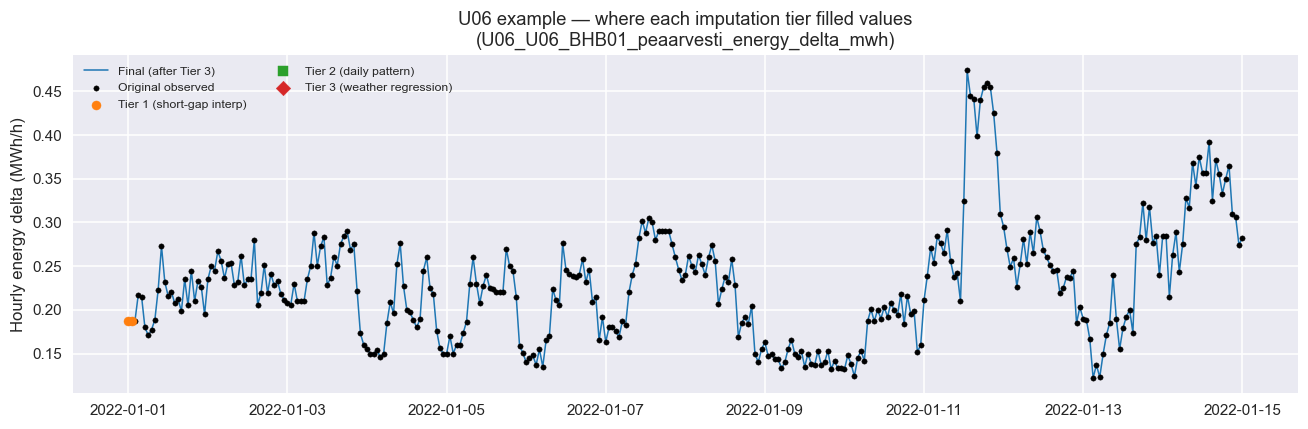

Example column: U06_U06_BHB01_peaarvesti_energy_delta_mwh
Tier 1 fills in window: 2  Tier 2 fills: 0  Tier 3 fills: 0


In [16]:

# Cell 11b — Example: where Tiers 1–3 changed U06 energy deltas

# Choose an example U06 energy-delta column
example_cols = [
    c for c in building_final_dfs.get("U06", pd.DataFrame()).columns
    if c.endswith("_energy_delta_mwh")
]
example_col = example_cols[0] if example_cols else None

if example_col is None:
    print("No U06 energy_delta_mwh column found.")
else:
    base = building_final_dfs["U06"][example_col]
    t1   = building_t1_dfs["U06"][example_col]
    t2   = building_t2_dfs["U06"][example_col]
    t3   = building_imputed_dfs["U06"][example_col]

    # Identify timestamps that were filled at each tier on the full range
    t1_filled = base.isna() & t1.notna()
    t2_filled = t1.isna() & t2.notna()
    t3_filled = t2.isna() & t3.notna()
    any_change = t1_filled | t2_filled | t3_filled

    if not any_change.any():
        print("No timestamps were changed by Tiers 1–3 for", example_col)
    else:
        # Pick the first changed timestamp and look at a ±3 day window around it
        t0 = any_change[any_change].index[0]
        start = t0 - pd.Timedelta(days=14)
        end   = t0 + pd.Timedelta(days=14)

        base_w = base.loc[start:end]
        t1_w   = t1.loc[start:end]
        t2_w   = t2.loc[start:end]
        t3_w   = t3.loc[start:end]

        t1_filled_w = t1_filled.loc[start:end]
        t2_filled_w = t2_filled.loc[start:end]
        t3_filled_w = t3_filled.loc[start:end]

        fig, ax = plt.subplots(1, 1, figsize=(12, 4))

        # Plot final series as a line
        ax.plot(t3_w.index, t3_w.values, color="tab:blue", lw=1.0,
                label="Final (after Tier 3)")

        # Overlay original observed points
        ax.scatter(
            base_w.index[base_w.notna()],
            base_w[base_w.notna()],
            color="black",
            s=12,
            label="Original observed",
            zorder=3,
        )

        # Overlay Tier 1, 2, 3 imputed points with distinct markers
        ax.scatter(
            t1_w.index[t1_filled_w],
            t1_w[t1_filled_w],
            color="tab:orange",
            s=35,
            marker="o",
            label="Tier 1 (short-gap interp)",
            zorder=4,
        )

        ax.scatter(
            t2_w.index[t2_filled_w],
            t2_w[t2_filled_w],
            color="tab:green",
            s=40,
            marker="s",
            label="Tier 2 (daily pattern)",
            zorder=4,
        )

        ax.scatter(
            t3_w.index[t3_filled_w],
            t3_w[t3_filled_w],
            color="tab:red",
            s=45,
            marker="D",
            label="Tier 3 (weather regression)",
            zorder=4,
        )

        ax.set_ylabel("Hourly energy delta (MWh/h)")
        ax.set_title(
            "U06 example — where each imputation tier filled values\n"
            f"({example_col})"
        )
        ax.legend(fontsize=8, ncol=2)
        plt.tight_layout()
        plt.show()

        print("Example column:", example_col)
        print("Tier 1 fills in window:", int(t1_filled_w.sum()),
              " Tier 2 fills:", int(t2_filled_w.sum()),
              " Tier 3 fills:", int(t3_filled_w.sum()))


## Cell 11c — How much was imputed at each tier?

To close the imputation section we summarise, **per building**, how the missingness evolved
across tiers:

- `T0` — after cleaning and column deletion (`building_final_dfs`).
- `T1` — after short-gap interpolation (`building_t1_dfs`).
- `T2` — after daily-pattern fill for medium gaps (`building_t2_dfs`).
- `T3` — after weather-regression imputation for long gaps (`building_imputed_dfs`).

For each building we report:

- overall missingness (% of all cells across all remaining series), and
- missingness restricted to **energy delta** columns only.

This shows how much information was recovered by each tier and confirms that **all energy
delta series are now fully observed (0% missing at T3)**, while some predictors still contain
honest gaps that will be handled separately (e.g. weather cross-fill) or left as NaN for
algorithms that support it.

In [17]:
# Cell 11c — Building-level missingness across tiers T0–T3

summary_rows: list[dict] = []


def _miss_frac(df: pd.DataFrame) -> float:
    return float(df.isna().mean().mean()) if not df.empty else float("nan")


def _miss_frac_energy(df: pd.DataFrame) -> float:
    if df.empty:
        return float("nan")
    cols = [c for c in df.columns if c.endswith("_energy_delta_mwh")]
    if not cols:
        return float("nan")
    sub = df[cols]
    return float(sub.isna().mean().mean())


for bldg in sorted(building_final_dfs.keys()):
    df0 = building_final_dfs[bldg]
    df1 = building_t1_dfs[bldg]
    df2 = building_t2_dfs[bldg]
    df3 = building_imputed_dfs[bldg]

    summary_rows.append(
        {
            "building": bldg,
            "miss_all_T0": _miss_frac(df0) * 100,
            "miss_all_T1": _miss_frac(df1) * 100,
            "miss_all_T2": _miss_frac(df2) * 100,
            "miss_all_T3": _miss_frac(df3) * 100,
            "miss_energy_T0": _miss_frac_energy(df0) * 100,
            "miss_energy_T1": _miss_frac_energy(df1) * 100,
            "miss_energy_T2": _miss_frac_energy(df2) * 100,
            "miss_energy_T3": _miss_frac_energy(df3) * 100,
        }
    )

summ_df = pd.DataFrame(summary_rows).sort_values("building")

fmt = {c: (lambda v, _c=c: f"{v:5.1f}" if pd.notna(v) else "  NaN ") for c in summ_df.columns if c != "building"}

print("Per-building missingness (% of cells) across tiers:")
print(summ_df.to_string(index=False, formatters=fmt))

print("\nOverall averages (all buildings):")
mean_row = summ_df.drop(columns=["building"]).mean()
for c, v in mean_row.items():
    print(f"  {c:15s}: {v:5.1f}%")


Per-building missingness (% of cells) across tiers:
building miss_all_T0 miss_all_T1 miss_all_T2 miss_all_T3 miss_energy_T0 miss_energy_T1 miss_energy_T2 miss_energy_T3
     GEO        17.4        16.4        16.3        14.7           15.8           13.9           13.7            9.0
     ICO        15.4        14.8        14.7        11.5           14.2           13.1           12.9            3.2
     LIB        29.2        26.0        25.9        23.0           15.5           13.5           13.2            4.6
     SOC        30.3        26.9        26.7        24.5           17.0           14.2           13.7            7.2
     STU        35.9        34.2        33.7         0.0           35.9           34.2           33.7            0.0
     U01        28.0        26.1        26.0        23.7           14.9           13.6           13.4            6.5
  U01U02        33.4        32.7        32.5         0.0           33.4           32.7           32.5            0.0
     U02    

## Cell 11d — Tier 2 daily-pattern fill for predictor columns (supply/return temp)

Tiers 2–3 above targeted **energy delta** columns only, leaving supply and return
temperature columns with only Tier 1 (6 h linear interpolation). Those columns still
carry 15–35 % missing values.

District-heating supply and return temperatures exhibit strong **diurnal patterns**
(higher during daytime occupancy, lower at night) and are physically driven by the
outdoor weather-compensation curve. The same-hour median approach from Tier 2
therefore applies well here:

1. For each remaining `NaN` in a supply/return temp column, look at the **same
   clock-hour** within ±`DAILY_PATTERN_LOOKBACK_DAYS` (7 days).
2. If at least 10 non-NaN neighbours exist, fill with their **median**.
3. Otherwise, leave for Tier 3 (regression).

In [18]:
# Cell 11d — Tier 2 daily-pattern fill for predictor columns (supply/return temp)

building_t2_pred_dfs: dict[str, pd.DataFrame] = {}
t2_pred_rows: list[dict] = []

for bldg, df in building_imputed_dfs.items():
    df2 = df.copy()
    hours = df2.index.hour

    for col in df2.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty:
            continue
        var = row["var"].iloc[0]
        if var not in ("supply_temp_c", "return_temp_c"):
            continue

        s = df2[col]
        if s.isna().sum() == 0:
            continue

        n_before = int(s.notna().sum())
        s_filled = s.copy()
        nan_idx = s_filled[s_filled.isna()].index

        # FIX (P2): enforce DAILY_PATTERN_MAX_GAP_H — skip NaN runs
        # longer than the configured limit (same fix as Cell 10).
        is_nan = s.isna().to_numpy()
        _run_len = np.zeros(len(is_nan), dtype=int)
        _r = 0
        for _i, _v in enumerate(is_nan):
            _r = _r + 1 if _v else 0
            _run_len[_i] = _r
        _run_len_at = dict(zip(s.index[is_nan], _run_len[is_nan]))

        for t in nan_idx:
            if _run_len_at.get(t, 0) > DAILY_PATTERN_MAX_GAP_H:
                continue
            start = t - pd.Timedelta(days=DAILY_PATTERN_LOOKBACK_DAYS)
            end = t + pd.Timedelta(days=DAILY_PATTERN_LOOKBACK_DAYS)
            mask = (df2.index >= start) & (df2.index <= end) & (hours == t.hour)
            candidates = s[mask].dropna().values
            if candidates.size < 10:
                continue
            med = float(np.median(candidates))
            s_filled.at[t] = med

        n_after = int(s_filled.notna().sum())
        n_filled = n_after - n_before
        df2[col] = s_filled

        t2_pred_rows.append({
            "building": bldg,
            "column": col,
            "var": var,
            "n_before": n_before,
            "n_filled_t2_pred": max(n_filled, 0),
            "n_after": n_after,
        })

    building_t2_pred_dfs[bldg] = df2

t2_pred_df = pd.DataFrame(t2_pred_rows)
print("Tier 2 daily-pattern fill for predictor columns (supply/return temp):")
if not t2_pred_df.empty:
    summary = (
        t2_pred_df.groupby(["building", "var"])["n_filled_t2_pred"]
        .sum()
        .unstack(fill_value=0)
        .rename(columns={"supply_temp_c": "Supply temp filled", "return_temp_c": "Return temp filled"})
    )
    print(summary.to_string())
    print(f"\nTotal filled: {t2_pred_df['n_filled_t2_pred'].sum():,}")
else:
    print("  No predictor series found for Tier 2.")

Tier 2 daily-pattern fill for predictor columns (supply/return temp):
var       Return temp filled  Supply temp filled
building                                        
GEO                      516                 516
ICO                      232                 232
LIB                     2454                2454
SOC                     3272                3154
U01                     2307                2307
U02                     1896                1896
U02B                    1264                1264
U03                     3160                3160
U03B                    1635                1635
U04                      632                 632
U06                     3292                3292

Total filled: 41,202


## Cell 11e — Tier 3 regression fill for predictor columns (supply/return temp)

After Tier 2 (daily-pattern), some supply and return temperature values still remain
missing — typically in **long gaps** (multi-day or multi-week sensor outages) where
the ±7-day same-hour window lacks enough neighbours.

We apply the same regression strategy as Cell 11, but with a predictor set tailored
to building temperatures rather than energy demand:

- **Outdoor temperature** (KKP, the primary weather driver for DH supply/return).
- **Wind speed** (secondary effect on heat loss).
- **Hour-of-day** (sine/cosine encoding of the 24 h cycle).
- **Day-of-week** (sine/cosine, weekday vs weekend patterns).
- **Day-of-year** (sine/cosine, seasonal envelope).

For each building × temp column with at least `REG_MIN_OBSERVED_FRAC` observed data,
we fit a small OLS model and predict only at timestamps still missing after Tier 2.

Supply temperatures in district-heating networks are typically set by a **weather-
compensation curve** (higher supply when outdoor temp drops), so the regression should
capture most of the variance.

In [19]:
# Cell 11e — Tier 3 weather-regression fill for predictor columns (supply/return temp)

building_t3_pred_dfs: dict[str, pd.DataFrame] = {}
reg_pred_rows: list[dict] = []

weather_pred = weather.copy()
if "hour_sin" not in weather_pred.columns:
    hour_arr = weather_pred.index.hour.to_numpy()
    weather_pred["hour_sin"] = np.sin(2 * np.pi * hour_arr / 24.0)
    weather_pred["hour_cos"] = np.cos(2 * np.pi * hour_arr / 24.0)
    dow_arr = weather_pred.index.dayofweek.to_numpy()
    weather_pred["dow_sin"] = np.sin(2 * np.pi * dow_arr / 7.0)
    weather_pred["dow_cos"] = np.cos(2 * np.pi * dow_arr / 7.0)

# FIX (P1): also match "wind_ms" (KKP naming) alongside "wind_speed" (COP naming).
PRED_TEMP_REGRESSORS = [
    c for c in weather_pred.columns
    if any(k in c for k in ["temp", "wind_speed", "wind_ms"])
] + ["doy_sin", "doy_cos", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]


for bldg, df in building_t2_pred_dfs.items():
    df_imp = df.copy()

    for col in df.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty:
            continue
        var = row["var"].iloc[0]
        if var not in ("supply_temp_c", "return_temp_c"):
            continue

        y = df[col]
        if y.isna().sum() == 0:
            continue

        mask_obs = y.notna()
        n_obs = int(mask_obs.sum())
        total = len(y)
        if n_obs < REG_MIN_OBSERVED_FRAC * total:
            continue

        Xw = weather_pred.loc[mask_obs, PRED_TEMP_REGRESSORS].copy()
        Xw = Xw.dropna()
        y_obs = y.loc[Xw.index]
        if len(y_obs) < 50:
            continue

        X = np.column_stack([np.ones(len(Xw)), Xw.to_numpy()])
        y_arr = y_obs.to_numpy()
        beta, *_ = np.linalg.lstsq(X, y_arr, rcond=None)

        y_pred_train = X @ beta
        ss_res = float(((y_arr - y_pred_train) ** 2).sum())
        ss_tot = float(((y_arr - y_arr.mean()) ** 2).sum())
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # FIX (P1): skip fill if the model has no predictive skill.
        if np.isnan(r2) or r2 < REG_MIN_R2_TEMP:
            reg_pred_rows.append({
                "building": bldg, "column": col, "var": var,
                "n_obs": int(len(y_obs)), "n_filled_reg": 0,
                "r2_train": r2, "skipped_low_r2": True,
            })
            continue

        mask_miss = y.isna()
        Xw_miss = weather_pred.loc[mask_miss, PRED_TEMP_REGRESSORS].dropna()
        if not Xw_miss.empty:
            Xm = np.column_stack([np.ones(len(Xw_miss)), Xw_miss.to_numpy()])
            y_pred = Xm @ beta
            df_imp.loc[Xw_miss.index, col] = y_pred
            n_filled = int(len(Xw_miss))
        else:
            n_filled = 0

        reg_pred_rows.append({
            "building": bldg,
            "column": col,
            "var": var,
            "n_obs": int(len(y_obs)),
            "n_filled_reg": n_filled,
            "r2_train": r2,
        })

    building_t3_pred_dfs[bldg] = df_imp

reg_pred_df = pd.DataFrame(reg_pred_rows)
print("Tier 3 weather-regression for predictor columns (supply/return temp):")
if not reg_pred_df.empty:
    print(reg_pred_df.sort_values(["building", "column"]).to_string(
        index=False, formatters={"r2_train": lambda v: f"{v:.2f}"}))
else:
    print("  No predictor series met the minimum observed fraction for regression.")

pred_cover_rows = []
for bldg, df in building_t3_pred_dfs.items():
    for col in df.columns:
        row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if row.empty:
            continue
        var = row["var"].iloc[0]
        if var not in ("supply_temp_c", "return_temp_c"):
            continue
        frac_non_nan = float(df[col].notna().mean()) * 100
        pred_cover_rows.append({
            "building": bldg,
            "column": col,
            "var": var,
            "non_nan_pct": frac_non_nan,
        })

pred_cover = pd.DataFrame(pred_cover_rows)
if not pred_cover.empty:
    print("\nCoverage after Tier 3 for predictor temp columns:")
    print(
        pred_cover.groupby(["building", "var"])["non_nan_pct"]
        .mean()
        .unstack(fill_value=float("nan"))
        .to_string(float_format=lambda v: f"{v:5.1f}")
    )

Tier 3 weather-regression for predictor columns (supply/return temp):
building                                      column           var  n_obs  n_filled_reg r2_train skipped_low_r2
     GEO            GEO_GEO_BHB02_küte_return_temp_c return_temp_c  21810          4453     0.54            NaN
     GEO            GEO_GEO_BHB02_küte_supply_temp_c supply_temp_c  21810          4453     0.64            NaN
     GEO   GEO_GEO_BHB03_ventilatsioon_return_temp_c return_temp_c  21810             0     0.18           True
     GEO   GEO_GEO_BHB03_ventilatsioon_supply_temp_c supply_temp_c  21810          4453     0.29            NaN
     GEO            GEO_GEO_BHB04_vesi_return_temp_c return_temp_c  21810          4453     0.41            NaN
     GEO            GEO_GEO_BHB04_vesi_supply_temp_c supply_temp_c  21810             0     0.05           True
     ICO            ICO_ICO_BHB01_küte_return_temp_c return_temp_c  22205          4058     0.83            NaN
     ICO            ICO_ICO_BHB01_

## Cell 11g — Mask values outside each series' coverage window

Using the `coverage_df` built in Cell 4b, we now enforce that **no values exist outside**
 the real sensor life period for any building × series:

- For each `(building, column)` we look up `first_ts` and `last_ts`.
- Any timestamps **before `first_ts` or after `last_ts`** are set back to `NaN`.

This prevents the imputation tiers from effectively "inventing" data in periods where
the underlying sensor had no observations (e.g. months before a meter was installed).

The resulting `building_imputed_dfs` contain imputed values **only within** each series'
true observation window; all out-of-coverage timestamps are explicitly `NaN`.

In [20]:
# Cell 11g — Mask values outside coverage window

for bldg, df in building_imputed_dfs.items():
    cov_b = coverage_df[coverage_df["building"] == bldg]
    if cov_b.empty:
        continue

    for col in df.columns:
        if col.endswith("_imputed"):
            continue

        cov_row = cov_b[cov_b["column"] == col]
        if cov_row.empty:
            # No coverage information for this series; leave as-is.
            continue

        first_ts = cov_row["first_ts"].iloc[0]
        last_ts = cov_row["last_ts"].iloc[0]

        # Mask everything before the first observed value or after the last observed value.
        mask_ooc = (df.index < first_ts) | (df.index > last_ts)
        df.loc[mask_ooc, col] = pd.NA

    building_imputed_dfs[bldg] = df

print("Applied coverage-based masking outside sensor life window.")

Applied coverage-based masking outside sensor life window.


## Cell 11f — Tier 4 final fallback: monthly-hour median + ffill/bfill

After Tiers 1–3 (extended to all column types), a small number of `NaN` values may
still survive — typically in columns with very high initial missingness where:

- The daily-pattern window lacked enough same-hour neighbours, **and**
- The regression model could not be fit (insufficient observed data) or the weather
  predictors were themselves missing at those timestamps.

To reach **100 % data completeness** we apply two simple, conservative fallbacks:

1. **Monthly × hour-of-day median**: for each (month, hour) combination, replace
   remaining `NaN`s with the median of observed values sharing that same calendar slot.
   This preserves both the seasonal envelope and the diurnal shape.
2. **Forward-fill then backward-fill** (`ffill().bfill()`): catches any truly isolated
   edge-case `NaN`s (e.g. the very first or last timestamp where no calendar slot has
   any data).

After this cell, `building_imputed_dfs` is reassigned so that the downstream
**Cell 12 (imputation flags)** and **Cell 14 (diagnostics)** automatically reflect
the fully imputed data.

In [21]:
# Cell 11f — Tier 4 final fallback: monthly-hour median + ffill/bfill

t4_rows: list[dict] = []

for bldg, df in building_t3_pred_dfs.items():
    for col in df.columns:
        if col.endswith("_imputed"):
            continue
        s = df[col]
        n_nan_before = int(s.isna().sum())
        if n_nan_before == 0:
            continue

        month = s.index.month
        hour = s.index.hour

        for m in range(1, 13):
            for h in range(24):
                mask_mh = (month == m) & (hour == h)
                subset = s[mask_mh]
                if subset.isna().any() and subset.notna().any():
                    med = subset.median()
                    fill_mask = mask_mh & s.isna()
                    s[fill_mask] = med

        s = s.ffill().bfill()

        # FIX (P1): after ffill/bfill, energy deltas may propagate or create
        # negative values. Clip to zero. Also clip temps to physical bounds.
        qa_row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if not qa_row.empty:
            _var = qa_row["var"].iloc[0]
            if _var in ("energy_mwh", "flow_volume_m3"):
                s = s.clip(lower=0.0)
            elif _var in ("supply_temp_c", "return_temp_c"):
                s = s.clip(lower=TEMP_MIN_C, upper=TEMP_MAX_C)

        df[col] = s

        n_nan_after = int(s.isna().sum())
        n_filled = n_nan_before - n_nan_after
        if n_filled > 0:
            t4_rows.append({
                "building": bldg,
                "column": col,
                "n_nan_before_t4": n_nan_before,
                "n_filled_t4": n_filled,
                "n_nan_after_t4": n_nan_after,
            })

# Reassign so Cell 12 (flags) and Cell 14 (diagnostics) use the fully imputed data
building_imputed_dfs = building_t3_pred_dfs

# FIX (P0): Cell 11g applied coverage masking to the old building_imputed_dfs,
# but this reassignment overwrites it with unmasked building_t3_pred_dfs.
# Re-apply coverage masking here so values outside each sensor's real life
# window remain NaN and are never exported as observed.
_cov_masked = 0
for bldg, df in building_imputed_dfs.items():
    cov_b = coverage_df[coverage_df["building"] == bldg]
    if cov_b.empty:
        continue
    for col in df.columns:
        if col.endswith("_imputed"):
            continue
        cov_row = cov_b[cov_b["column"] == col]
        if cov_row.empty:
            continue
        first_ts = cov_row["first_ts"].iloc[0]
        last_ts = cov_row["last_ts"].iloc[0]
        mask_ooc = (df.index < first_ts) | (df.index > last_ts)
        n_ooc = int(mask_ooc.sum())
        if n_ooc > 0:
            df.loc[mask_ooc, col] = np.nan
            _cov_masked += n_ooc
    building_imputed_dfs[bldg] = df
print(f"Re-applied coverage masking after Tier 4 reassignment ({_cov_masked:,} cells masked).")

# Summary
remaining_nan = 0
total_vals = 0
for bldg, df in building_imputed_dfs.items():
    for col in df.columns:
        if col.endswith("_imputed"):
            continue
        remaining_nan += int(df[col].isna().sum())
        total_vals += len(df[col])

t4_df = pd.DataFrame(t4_rows)
if not t4_df.empty:
    print("Tier 4 final fallback fill summary:")
    print(t4_df.to_string(index=False))
else:
    print("Tier 4: no additional fills needed (all NaN already resolved by Tiers 1–3).")

print(f"\n{'='*60}")
print(f"FINAL DATA COMPLETENESS")
print(f"  Total data points: {total_vals:,}")
print(f"  Remaining NaN:     {remaining_nan:,}")
print(f"  Completeness:      {(1 - remaining_nan / total_vals) * 100:.2f}%")
print(f"{'='*60}")

Re-applied coverage masking after Tier 4 reassignment (547,080 cells masked).
Tier 4 final fallback fill summary:
building                                         column  n_nan_before_t4  n_filled_t4  n_nan_after_t4
     GEO            GEO_GEO_BHB02_küte_energy_delta_mwh               10           10               0
     GEO               GEO_GEO_BHB02_küte_supply_temp_c               10           10               0
     GEO               GEO_GEO_BHB02_küte_return_temp_c               10           10               0
     GEO   GEO_GEO_BHB03_ventilatsioon_energy_delta_mwh             3636         3636               0
     GEO      GEO_GEO_BHB03_ventilatsioon_supply_temp_c               10           10               0
     GEO      GEO_GEO_BHB03_ventilatsioon_return_temp_c             4463         4463               0
     GEO            GEO_GEO_BHB04_vesi_energy_delta_mwh             3417         3417               0
     GEO               GEO_GEO_BHB04_vesi_supply_temp_c             44

## Cell 12 — Imputation flags: where is the data synthetic?

For modelling and for interpretability we want to distinguish **observed** values from those that
were **synthesised by the pipeline**. This is especially important when training and validating
forecasting models.

In this cell we:

- compare the cleaned-but-missing tables (`building_final_dfs`, after outlier removal and
  column deletion) with the fully imputed ones (`building_imputed_dfs`),
- for every numeric column add a boolean `{column}_imputed` flag that is `True` exactly when
  the final value is non-NaN and the original value at that timestamp was `NaN`,
- store the result in `building_flagged_dfs` which will be the basis for downstream export.

We also print a short summary per building (how many values were imputed, and what fraction of all
cells that represents).

In [22]:
# Cell 12 — Add {column}_imputed boolean flags

building_flagged_dfs: dict[str, pd.DataFrame] = {}
flag_rows: list[dict] = []

for bldg in sorted(building_imputed_dfs.keys()):
    df0 = building_final_dfs[bldg]        # before any imputation
    df3 = building_imputed_dfs[bldg]      # after all three tiers

    # Ensure both have the same columns (they should, but be defensive)
    common_cols = df3.columns.intersection(df0.columns)
    df0 = df0[common_cols]
    df3 = df3[common_cols]

    df_flagged = df3.copy()

    total_cells = df3.size
    total_imputed = 0
    total_still_missing = int(df3.isna().sum().sum())

    for col in common_cols:
        base_s = df0[col]
        final_s = df3[col]

        imputed_mask = base_s.isna() & final_s.notna()
        flag_col = f"{col}_imputed"
        df_flagged[flag_col] = imputed_mask.astype(bool)

        n_imp = int(imputed_mask.sum())
        total_imputed += n_imp

        flag_rows.append(
            {
                "building": bldg,
                "column": col,
                "n_imputed": n_imp,
            }
        )

    # FIX (P0): ensure imputation flags are False outside coverage window.
    # Without this, flags could be True for timestamps where the sensor
    # didn't exist yet, which misleads downstream models.
    cov_b = coverage_df[coverage_df["building"] == bldg]
    for col in common_cols:
        flag_col = f"{col}_imputed"
        cov_row = cov_b[cov_b["column"] == col]
        if cov_row.empty:
            continue
        first_ts = cov_row["first_ts"].iloc[0]
        last_ts = cov_row["last_ts"].iloc[0]
        mask_ooc = (df_flagged.index < first_ts) | (df_flagged.index > last_ts)
        df_flagged.loc[mask_ooc, flag_col] = False

    building_flagged_dfs[bldg] = df_flagged

    frac_imp = total_imputed / total_cells * 100 if total_cells > 0 else 0.0
    frac_missing = total_still_missing / total_cells * 100 if total_cells > 0 else 0.0
    print(
        f"{bldg}: {frac_imp:.1f}% imputed, {frac_missing:.1f}% still missing "
        f"({total_imputed:,} imputed, {total_still_missing:,} missing of {total_cells:,} cells)"
    )

flag_df = pd.DataFrame(flag_rows)


GEO: 4.4% imputed, 13.0% still missing (10,509 imputed, 30,774 missing of 236,736 cells)
ICO: 2.7% imputed, 12.7% still missing (8,478 imputed, 40,180 missing of 315,648 cells)
LIB: 16.5% imputed, 12.7% still missing (39,051 imputed, 30,144 missing of 236,736 cells)
SOC: 15.9% imputed, 14.4% still missing (50,183 imputed, 45,604 missing of 315,648 cells)
STU: 2.8% imputed, 33.1% still missing (745 imputed, 8,697 missing of 26,304 cells)
U01: 15.0% imputed, 13.0% still missing (47,420 imputed, 40,879 missing of 315,648 cells)
U01U02: 0.9% imputed, 32.5% still missing (226 imputed, 8,559 missing of 26,304 cells)
U02: 8.1% imputed, 12.8% still missing (19,119 imputed, 30,405 missing of 236,736 cells)
U02B: 7.9% imputed, 15.7% still missing (14,494 imputed, 28,829 missing of 184,128 cells)
U03: 7.6% imputed, 14.3% still missing (34,129 imputed, 64,152 missing of 447,168 cells)
U03B: 7.2% imputed, 19.4% still missing (18,854 imputed, 50,925 missing of 263,040 cells)
U04: 4.5% imputed, 17.6%

## Cell 13 — Weather imputation: combining COP and KKP

We now create a single, gap-minimised weather table for modelling.

- **Sources**:
  - `cop_df` — Copernicus ERA5 (gridded reanalysis).
  - `kkp_df` — Harku station data from Keskkonnaportaal.
- **Goal**: build `weather_final_df` where each physical variable has **one best series**,
  using Harku when available and Copernicus as a backup.

Specifically we construct:

- `temp_c`   — primary: `KKP_temp_c` midpoint (min/max), fallback: `COP_temp_c`.
- `wind_ms`  — primary: `KKP_wind_speed_ms`, fallback: `COP_wind_speed_ms`.
- `solar_irradiance_Wm2` — from `COP_ssrd_W_per_m2` (no KKP alternative).
- `sunshine_min`         — from `KKP_sunshine_duration_min` (no COP alternative).

For `temp_c` and `wind_ms` we also add boolean flags showing **which source contributed** at
each timestamp (e.g. `temp_from_kkp`, `temp_from_cop`).

At the end we print per-variable coverage before/after and show a simple bar plot of
non-missing percentages so we can see how much the cross-fill improved the usable weather data.

Weather series coverage (non-NaN % across 2022–2024):
           series non_nan_pct
       COP_temp_c        98.3
   KKP_temp_mid_c       100.0
     temp_c_final       100.0
COP_wind_speed_ms        98.3
      KKP_wind_ms        99.8
    wind_ms_final       100.0
COP_ssrd_W_per_m2        96.7
 KKP_sunshine_min        99.8


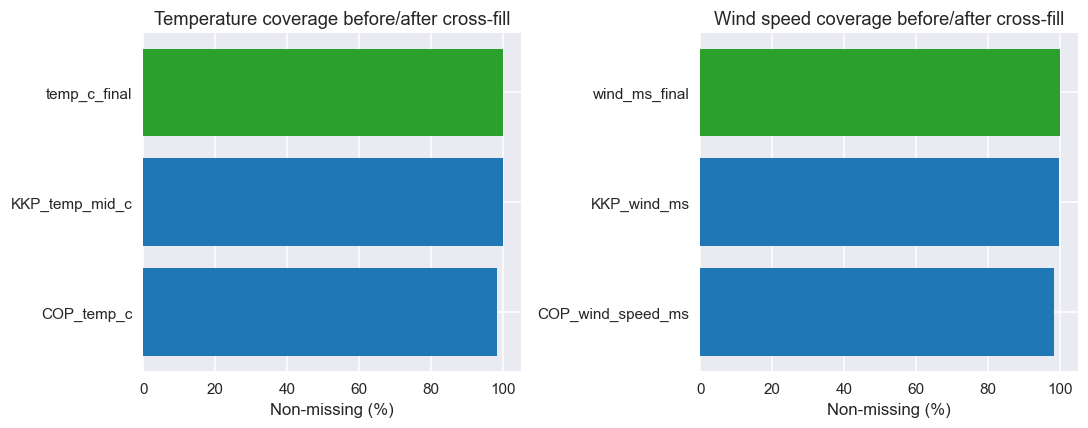

In [23]:
# Cell 13 — Build weather_final_df with COP/KKP cross-fill

# 1. Construct a single temp_c series: KKP midpoint preferred, COP as fallback

# KKP midpoint temperature, if we have min/max
if {"temp_min_c", "temp_max_c"}.issubset(kkp_df.columns):
    kkp_temp = (kkp_df["temp_min_c"] + kkp_df["temp_max_c"]) / 2
else:
    kkp_temp = kkp_df.get("KKP_temp_c")  # from earlier merge, if present

cop_temp = cop_df.get("COP_temp_c")

# 2. Wind speed: KKP primary, COP backup
kkp_wind = kkp_df.get("wind_ms")
cop_wind = cop_df.get("COP_wind_speed_ms")

# 3. Solar + sunshine: one source each
solar = cop_df.get("COP_ssrd_W_per_m2")
sun   = cop_df.get("KKP_sunshine_duration_min", kkp_df.get("sunshine_min"))

# Align all series to the same hourly index
idx = cop_df.index

kkp_temp = kkp_temp.reindex(idx) if kkp_temp is not None else None
cop_temp = cop_temp.reindex(idx) if cop_temp is not None else None
kkp_wind = kkp_wind.reindex(idx) if kkp_wind is not None else None
cop_wind = cop_wind.reindex(idx) if cop_wind is not None else None
solar    = solar.reindex(idx)    if solar is not None else None
sun      = sun.reindex(idx)      if sun is not None else None

# Helper to combine two sources with flags
import numpy as _np


def _combine_with_flags(primary: pd.Series | None,
                         backup: pd.Series | None) -> tuple[pd.Series, pd.Series, pd.Series]:
    if primary is None and backup is None:
        combined = pd.Series(_np.nan, index=idx)
        return combined, combined.astype(bool), combined.astype(bool)

    if primary is None:
        primary = pd.Series(_np.nan, index=idx)
    if backup is None:
        backup = pd.Series(_np.nan, index=idx)

    use_primary = primary.notna()
    use_backup  = ~use_primary & backup.notna()

    combined = pd.Series(_np.nan, index=idx, dtype=float)
    combined[use_primary] = primary[use_primary]
    combined[use_backup]  = backup[use_backup]

    return combined, use_primary.astype(bool), use_backup.astype(bool)


# Combine temperature and wind
temp_c, temp_from_kkp, temp_from_cop = _combine_with_flags(kkp_temp, cop_temp)
wind_ms, wind_from_kkp, wind_from_cop = _combine_with_flags(kkp_wind, cop_wind)

weather_final_df = pd.DataFrame({"temp_c": temp_c, "wind_ms": wind_ms})

if solar is not None:
    weather_final_df["solar_irradiance_Wm2"] = solar
if sun is not None:
    weather_final_df["sunshine_min"] = sun

# Add flags
weather_final_df["temp_from_kkp"] = temp_from_kkp
weather_final_df["temp_from_cop"] = temp_from_cop
weather_final_df["wind_from_kkp"] = wind_from_kkp
weather_final_df["wind_from_cop"] = wind_from_cop


# ── Coverage summary ─────────────────────────────────────────────────────────

coverage_rows = []

if cop_temp is not None:
    coverage_rows.append({"series": "COP_temp_c", "non_nan_pct": float(cop_temp.notna().mean()) * 100})
if kkp_temp is not None:
    coverage_rows.append({"series": "KKP_temp_mid_c", "non_nan_pct": float(kkp_temp.notna().mean()) * 100})
coverage_rows.append({"series": "temp_c_final", "non_nan_pct": float(weather_final_df["temp_c"].notna().mean()) * 100})

if cop_wind is not None:
    coverage_rows.append({"series": "COP_wind_speed_ms", "non_nan_pct": float(cop_wind.notna().mean()) * 100})
if kkp_wind is not None:
    coverage_rows.append({"series": "KKP_wind_ms", "non_nan_pct": float(kkp_wind.notna().mean()) * 100})
coverage_rows.append({"series": "wind_ms_final", "non_nan_pct": float(weather_final_df["wind_ms"].notna().mean()) * 100})

if solar is not None:
    coverage_rows.append({"series": "COP_ssrd_W_per_m2", "non_nan_pct": float(solar.notna().mean()) * 100})
if sun is not None:
    coverage_rows.append({"series": "KKP_sunshine_min", "non_nan_pct": float(sun.notna().mean()) * 100})

cov_df = pd.DataFrame(coverage_rows)
print("Weather series coverage (non-NaN % across 2022–2024):")
print(cov_df.to_string(index=False, formatters={"non_nan_pct": lambda v: f"{v:5.1f}"}))


# ── Plot: before/after coverage for temp and wind ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Temperature coverage bars
sub = cov_df[cov_df["series"].str.contains("temp")]
axes[0].barh(sub["series"], sub["non_nan_pct"], color=["#1f77b4"] * (len(sub) - 1) + ["#2ca02c"])
axes[0].set_xlabel("Non-missing (%)")
axes[0].set_title("Temperature coverage before/after cross-fill")
axes[0].set_xlim(0, 105)

# Wind coverage bars
sub = cov_df[cov_df["series"].str.contains("wind")]
axes[1].barh(sub["series"], sub["non_nan_pct"], color=["#1f77b4"] * (len(sub) - 1) + ["#2ca02c"])
axes[1].set_xlabel("Non-missing (%)")
axes[1].set_title("Wind speed coverage before/after cross-fill")
axes[1].set_xlim(0, 105)

plt.tight_layout()
plt.show()


## Cell 14 — Post-imputation diagnostics

Now that both **building data** and **weather data** have gone through all cleaning and
imputation tiers, we take a final snapshot to check that:

- missingness levels are where we expect them (0% for energy deltas, small but non-zero for
  some predictors and weather), and
- value distributions have remained physically reasonable (no artificial clustering or
  obvious artefacts).

We:

1. Summarise final missingness per building and per variable type.
2. Compare pre/post distributions for a few key series (U06 energy delta, U06 supply/return
   temperatures, outdoor temperature).
3. Show a compact heatmap of final missingness (buildings × variable type) for thesis figures.

Final average missingness % by building × variable type (coverage-aware window):
var       Energy (MWh)  Return temp  Supply temp
building                                        
GEO                0.0          0.0          0.0
ICO                0.0          0.0          0.0
LIB                0.0          0.0          0.0
SOC                0.0          0.0          0.0
STU                0.0          NaN          NaN
U01                0.0          0.0          0.0
U01U02             0.0          NaN          NaN
U02                0.0          0.0          0.0
U02B               0.0          0.0          0.0
U03                0.0          0.0          0.0
U03B               0.0          0.0          0.0
U04                0.0          0.0          0.0
U04B               0.0          NaN          NaN
U05                0.0          NaN          NaN
U05B               0.0          NaN          NaN
U06                0.0          0.0          0.0
U06A               0.0          NaN  

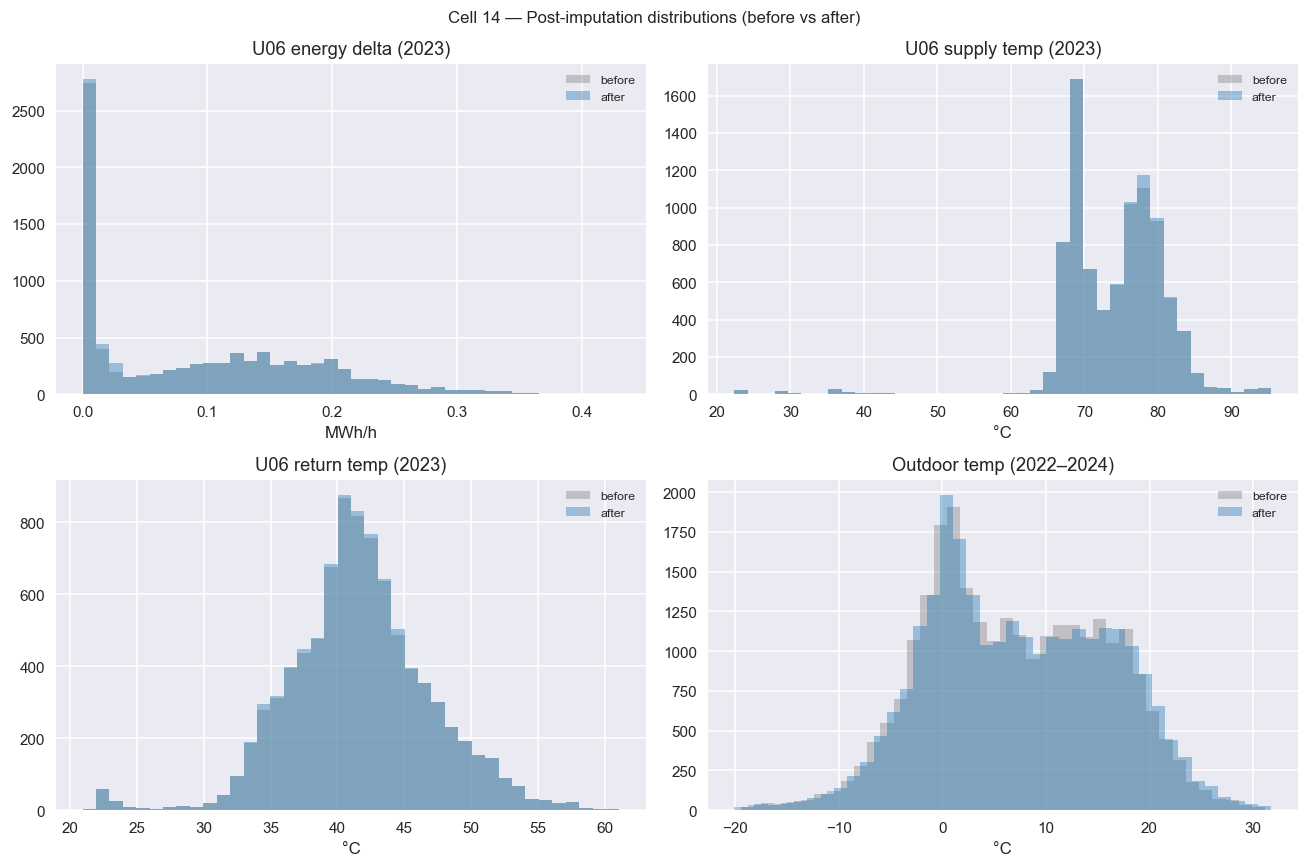

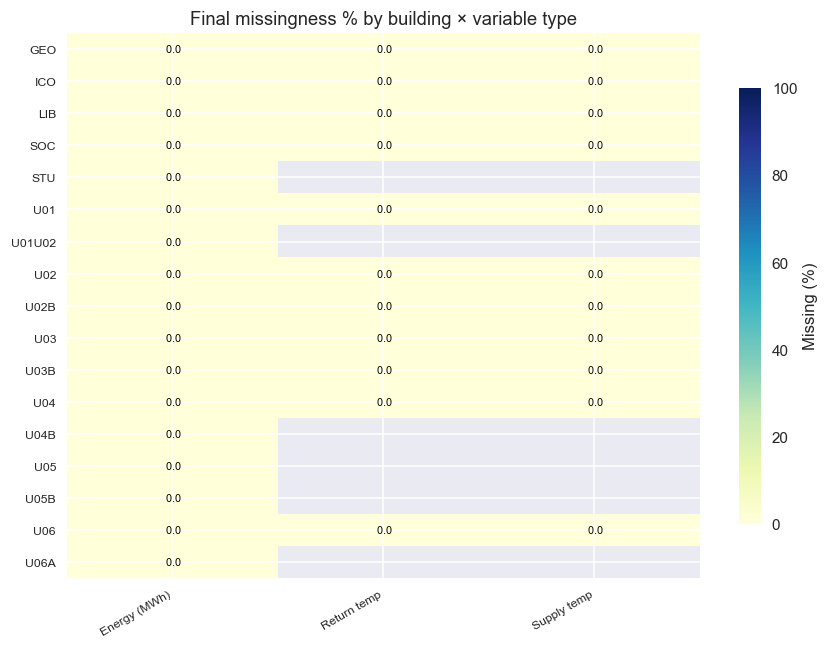

In [24]:
# Cell 14 — Final missingness + distribution checks

# 1. Final missingness per building and variable type (coverage-aware)

rows = []

for bldg, df in building_flagged_dfs.items():
    # Restrict to this building's coverage rows
    cov_b = coverage_df[coverage_df["building"] == bldg]
    if cov_b.empty:
        continue

    for col in df.columns:
        if col.endswith("_imputed"):
            continue

        # Look up coverage window for this series; skip if none
        cov_row = cov_b[cov_b["column"] == col]
        if cov_row.empty:
            continue
        first_ts = cov_row["first_ts"].iloc[0]
        last_ts = cov_row["last_ts"].iloc[0]

        # Slice to the actual sensor life window
        s = df[col].loc[(df.index >= first_ts) & (df.index <= last_ts)]
        if s.empty:
            continue

        # Derive variable type from QA mapping using any matching hourly_label
        qa_row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        var = qa_row["var"].iloc[0] if not qa_row.empty else "other"
        miss = float(s.isna().mean()) * 100
        rows.append({
            "building": bldg,
            "var": var,
            "column": col,
            "miss_pct": miss,
        })

final_miss_df = pd.DataFrame(rows)

var_labels = {
    "energy_mwh": "Energy (MWh)",
    "flow_volume_m3": "Flow vol (m³)",
    "supply_temp_c": "Supply temp",
    "return_temp_c": "Return temp",
    "flow_rate_m3h": "Flow rate",
    "power_kw": "Power (kW)",
    "other": "Other",
}

heat = (
    final_miss_df
    .groupby(["building", "var"])["miss_pct"]
    .mean()
    .unstack(fill_value=_np.nan)
    .rename(columns=var_labels)
)

print("Final average missingness % by building × variable type (coverage-aware window):")
print(heat.to_string(float_format=lambda v: f"{v:4.1f}"))

# Additional small table to demonstrate coverage-aware missingness for U06 temps
probe_building = "U06"
probe_cols = [
    c
    for c in building_flagged_dfs.get(probe_building, pd.DataFrame()).columns
    if c.endswith("supply_temp_c") or c.endswith("return_temp_c")
]
probe_rows = []
for col in probe_cols:
    cov_row = coverage_df[
        (coverage_df["building"] == probe_building)
        & (coverage_df["column"] == col)
    ]
    if cov_row.empty:
        continue
    first_ts = cov_row["first_ts"].iloc[0]
    last_ts = cov_row["last_ts"].iloc[0]
    s_all = building_flagged_dfs[probe_building][col]
    s_in = s_all.loc[(s_all.index >= first_ts) & (s_all.index <= last_ts)]
    s_out = s_all.loc[(s_all.index < first_ts) | (s_all.index > last_ts)]
    miss_in = float(s_in.isna().mean()) * 100 if not s_in.empty else _np.nan
    pct_na_out = float(s_out.isna().mean()) * 100 if not s_out.empty else _np.nan
    probe_rows.append({
        "building": probe_building,
        "column": col,
        "first_ts": first_ts,
        "last_ts": last_ts,
        "miss_pct_in_window": miss_in,
        "pct_na_outside_window": pct_na_out,
    })

if probe_rows:
    proof_df = pd.DataFrame(probe_rows)
    print("\nCoverage-aware check for U06 temps (inside vs outside sensor life window):")
    print(proof_df.to_string(index=False, float_format=lambda v: f"{v:5.1f}"))

# 2. Distribution comparison for key series (before vs after)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Helper to plot before/after histograms

def _hist_before_after(ax, before, after, title, xlabel):
    b = before.dropna()
    a = after.dropna()
    ax.hist(b, bins=40, alpha=0.4, label="before", color="tab:gray")
    ax.hist(a, bins=40, alpha=0.4, label="after", color="tab:blue")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

# U06 main energy delta, 2023 only
u06_energy_cols = [c for c in building_final_dfs["U06"].columns if c.endswith("_energy_delta_mwh")]
if u06_energy_cols:
    ec = u06_energy_cols[0]
    base = building_final_dfs["U06"][ec].loc["2023-01-01":"2023-12-31"]
    final = building_imputed_dfs["U06"][ec].loc["2023-01-01":"2023-12-31"]
    _hist_before_after(axes[0, 0], base, final, "U06 energy delta (2023)", "MWh/h")

# U06 supply temp, 2023
u06_supp_cols = [c for c in building_final_dfs["U06"].columns if c.endswith("supply_temp_c")]
if u06_supp_cols:
    tc = u06_supp_cols[0]
    base = building_final_dfs["U06"][tc].loc["2023-01-01":"2023-12-31"]
    final = building_imputed_dfs["U06"][tc].loc["2023-01-01":"2023-12-31"]
    _hist_before_after(axes[0, 1], base, final, "U06 supply temp (2023)", "°C")

# U06 return temp, 2023
u06_ret_cols = [c for c in building_final_dfs["U06"].columns if c.endswith("return_temp_c")]
if u06_ret_cols:
    rc = u06_ret_cols[0]
    base = building_final_dfs["U06"][rc].loc["2023-01-01":"2023-12-31"]
    final = building_imputed_dfs["U06"][rc].loc["2023-01-01":"2023-12-31"]
    _hist_before_after(axes[1, 0], base, final, "U06 return temp (2023)", "°C")

# Outdoor temperature from weather_final_df
base_temp = kkp_df.get("temp_min_c")  # pre-cross-fill proxy
if base_temp is not None:
    base_t = base_temp.loc[weather_final_df.index]
else:
    base_t = cop_df.get("COP_temp_c")
final_t = weather_final_df["temp_c"]
_hist_before_after(axes[1, 1], base_t, final_t, "Outdoor temp (2022–2024)", "°C")

plt.suptitle("Cell 14 — Post-imputation distributions (before vs after)", fontsize=11)
plt.tight_layout()
plt.show()

# 3. Heatmap of final missingness

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(heat.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title("Final missingness % by building × variable type")
plt.colorbar(im, ax=ax, label="Missing (%)", shrink=0.8)

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        v = heat.values[r, c]
        if not _np.isnan(v):
            ax.text(c, r, f"{v:4.1f}", ha="center", va="center", fontsize=7,
                    color="black" if v < 60 else "white")

plt.tight_layout()
plt.show()


## Cell 15 — Column renaming: clean model-ready labels

We now build a programmatic mapping from the raw pipeline column names to a clean, compact
`{scope}_{description}_{unit}` namespace that is stable for modelling and interpretation.

- **Scope prefixes**:
  - `bldg_…` for building-side energy and predictor measurements
  - `wx_…` for weather features
  - `meta_…` for static metadata (if present later)
- **Behaviour**:
  - Uses simple pattern rules (building code + variable type from `qa_hourly_df`) to propose
    human-friendly names.
  - Falls back to the original name if no rule matches (so nothing is ever lost).
  - Mirrors exported `*_imputed` flags to the **same clean base column name** they belong to.
  - Stores the full mapping in `column_mapping_df` and prints a preview table for validation.

This is the last purely syntactic step. The next cells add the semantic columns that downstream
notebooks should actually trust: canonical subsystem heat totals, weighted subsystem `ΔT`, and
one harmonized hourly `heat_target_mwh` per building.


In [25]:
# Cell 15 — Column renaming to clean {scope}_{description}_{unit} labels

from dataclasses import dataclass
import re


@dataclass
class ColumnPattern:
    var: str
    scope: str
    description: str
    unit: str


def _build_clean_name(building: str, col: str, qa_row: pd.Series | None) -> str:
    """Map a raw column name to a clean {scope}_{description}_{unit} name.

    This is intentionally conservative: if we cannot confidently map a column,
    we fall back to the original name.
    """
    # Weather columns (from weather_final_df)
    if building == "__weather__":
        if col == "temp_c":
            return "wx_outdoor_temp_c"
        if col in {"wind_speed_ms", "wind_ms"}:
            return "wx_wind_ms"
        if col in {"ssrd_W_per_m2", "solar_irradiance_Wm2"}:
            return "wx_solar_irradiance_Wm2"
        if col == "KKP_temp_c":
            return "wx_kkp_temp_c"
        # Fallback for any other weather column
        return f"wx_{col}"

    # Imputation flags keep the suffix but mirror the clean base name.
    if col.endswith("_imputed"):
        base = col[: -len("_imputed")]
        return _build_clean_name(building, base, qa_row) + "_imputed"

    # If we have QA metadata, use it
    var = None
    heating_group = None
    if qa_row is not None and not qa_row.empty:
        var = qa_row["var"]
        heating_group = qa_row.get("heating_group", None)

    # Energy deltas
    if col.endswith("_energy_delta_mwh"):
        bhb_match = re.search(r"BHB(\d+)", col)
        bhb_suffix = f"_BHB{bhb_match.group(1)}" if bhb_match else ""

        group_to_token = {
            "total": "total_heat",
            "space_heating": "space_heat",
            "vent_heating": "vent_heat",
            "dhw": "dhw",
            "outdoor_heating": "outdoor_heat",
            "waste_heat": "waste_heat",
        }

        if heating_group in group_to_token:
            token = group_to_token[heating_group]
            if heating_group == "total":
                return f"bldg_{token}_mwh"
            return f"bldg_{token}{bhb_suffix}_mwh"

        if bhb_suffix:
            return f"bldg_energy{bhb_suffix}_mwh"
        return "bldg_energy_mwh"

    # Temperatures
    if col.endswith("supply_temp_c") or col.endswith("return_temp_c"):
        heating_group = None
        if qa_row is not None:
            heating_group = qa_row.get("heating_group", None)

        bhb_match = re.search(r"BHB(\d+)", col)
        bhb_suffix = f"_BHB{bhb_match.group(1)}" if bhb_match else ""

        group_token = None
        if heating_group == "total":
            group_token = "main"
        elif heating_group == "space_heating":
            group_token = "space_heat"
        elif heating_group == "vent_heating":
            group_token = "vent_heat"
        elif heating_group == "dhw":
            group_token = "dhw"
        elif heating_group == "outdoor_heating":
            group_token = "outdoor_heat"
        elif heating_group:
            group_token = heating_group

        suffix = "supply_temp_c" if col.endswith("supply_temp_c") else "return_temp_c"

        if group_token is not None:
            if group_token == "main":
                return f"bldg_main_{suffix}"
            return f"bldg_{group_token}{bhb_suffix}_{suffix}"

        if bhb_suffix:
            return f"bldg{bhb_suffix}_{suffix}"

        return f"bldg_{suffix}"

    # Simple fallbacks using var from QA
    if var is not None:
        if var == "flow_volume_m3":
            return "bldg_flow_vol_m3"
        if var == "flow_rate_m3h":
            return "bldg_flow_rate_m3h"
        if var == "power_kw":
            return "bldg_power_kw"

    return col


mapping_rows: list[dict] = []

for bldg, df in building_flagged_dfs.items():
    base_name_map: dict[str, str] = {}

    for col in df.columns:
        if col.endswith("_imputed"):
            continue
        qa_row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        qa_row = qa_row.iloc[0] if not qa_row.empty else None
        new_name = _build_clean_name(bldg, col, qa_row)
        base_name_map[col] = new_name
        mapping_rows.append({
            "scope": "bldg",
            "building": bldg,
            "old_name": col,
            "new_name": new_name,
        })

    for col in df.columns:
        if not col.endswith("_imputed"):
            continue
        base = col[: -len("_imputed")]
        qa_row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == base]
        qa_row = qa_row.iloc[0] if not qa_row.empty else None
        new_name = base_name_map.get(base, _build_clean_name(bldg, base, qa_row)) + "_imputed"
        mapping_rows.append({
            "scope": "bldg",
            "building": bldg,
            "old_name": col,
            "new_name": new_name,
        })

for col in weather_final_df.columns:
    new_name = _build_clean_name("__weather__", col, None)
    mapping_rows.append({
        "scope": "wx",
        "building": "__weather__",
        "old_name": col,
        "new_name": new_name,
    })

column_mapping_df = pd.DataFrame(mapping_rows)


def build_building_rename_map(building: str) -> dict[str, str]:
    mapping_b = column_mapping_df[
        (column_mapping_df["scope"] == "bldg") & (column_mapping_df["building"] == building)
    ][["old_name", "new_name"]].drop_duplicates()
    return dict(zip(mapping_b["old_name"], mapping_b["new_name"]))


print("Column renaming preview (first 30 rows):")
print(column_mapping_df.head(30).to_string(index=False))

n_distinct = column_mapping_df[["old_name", "new_name"]].drop_duplicates().shape[0]
print(f"\nBuilt column_mapping_df with {len(column_mapping_df)} rows, {n_distinct} distinct mappings.")

for bldg in column_mapping_df.loc[column_mapping_df["scope"] == "bldg", "building"].unique():
    bldg_map = column_mapping_df[
        (column_mapping_df["scope"] == "bldg") & (column_mapping_df["building"] == bldg)
    ]
    dupes = bldg_map["new_name"][bldg_map["new_name"].duplicated()].unique()
    if len(dupes) > 0:
        raise ValueError(
            f"[P0 FAIL] Building {bldg} has duplicate clean names: {list(dupes[:10])}.\n"
            f"Fix _build_clean_name() so every column within a building gets a unique name."
        )
print("✓ Column uniqueness check passed — no duplicate clean names per building.")


Column renaming preview (first 30 rows):
scope building                                             old_name                                    new_name
 bldg      GEO                  GEO_GEO_BHB02_küte_energy_delta_mwh                   bldg_space_heat_BHB02_mwh
 bldg      GEO                     GEO_GEO_BHB02_küte_supply_temp_c         bldg_space_heat_BHB02_supply_temp_c
 bldg      GEO                     GEO_GEO_BHB02_küte_return_temp_c         bldg_space_heat_BHB02_return_temp_c
 bldg      GEO         GEO_GEO_BHB03_ventilatsioon_energy_delta_mwh                    bldg_vent_heat_BHB03_mwh
 bldg      GEO            GEO_GEO_BHB03_ventilatsioon_supply_temp_c          bldg_vent_heat_BHB03_supply_temp_c
 bldg      GEO            GEO_GEO_BHB03_ventilatsioon_return_temp_c          bldg_vent_heat_BHB03_return_temp_c
 bldg      GEO                  GEO_GEO_BHB04_vesi_energy_delta_mwh                          bldg_dhw_BHB04_mwh
 bldg      GEO                     GEO_GEO_BHB04_vesi_supply_te

## Cell 15b — Canonical heat target and subsystem `ΔT` features

This section turns the renamed building tables into the actual hourly source-of-truth inputs for
all later modelling notebooks.

It does four things per building:
- aggregates circuit-level heat meters into canonical subsystem totals such as `bldg_space_heat_mwh`,
- computes load-weighted subsystem `ΔT` columns such as `bldg_space_heat_deltaT_c`,
- flags low-`ΔT` operation using `DELTA_T_LOW_THRESHOLD_C`,
- and selects one harmonized hourly `heat_target_mwh`.

This is deliberately done **here**, not in the modelling notebooks, so that later experiments do
not silently use different target definitions for different buildings.


In [26]:
# Cell 15b — Add canonical heat target and subsystem ΔT features to exported building tables

HEAT_CATEGORY_TOKENS = ["space_heat", "vent_heat", "dhw", "outdoor_heat", "waste_heat"]


def _safe_numeric(df: pd.DataFrame, col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index, dtype=float)
    return pd.to_numeric(df[col], errors="coerce")


def _find_meter_cols(df: pd.DataFrame, token: str) -> list[str]:
    pattern = re.compile(rf"^bldg_{re.escape(token)}(?:_BHB\d+)?_mwh$")
    return [c for c in df.columns if bool(pattern.fullmatch(c))]


def _sum_cols(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    if not cols:
        return pd.Series(np.nan, index=df.index, dtype=float)
    return df.loc[:, cols].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)


def _weighted_deltaT(df: pd.DataFrame, token: str) -> pd.Series:
    triplets: list[tuple[str, str, str]] = []
    for energy_col in _find_meter_cols(df, token):
        if not re.search(r"_BHB\d+_mwh$", energy_col):
            continue
        base = energy_col[: -len("_mwh")]
        supply_col = f"{base}_supply_temp_c"
        return_col = f"{base}_return_temp_c"
        if supply_col in df.columns and return_col in df.columns:
            triplets.append((energy_col, supply_col, return_col))

    if not triplets:
        return pd.Series(np.nan, index=df.index, dtype=float)

    numerator = pd.Series(0.0, index=df.index, dtype=float)
    denominator = pd.Series(0.0, index=df.index, dtype=float)

    for energy_col, supply_col, return_col in triplets:
        load = pd.to_numeric(df[energy_col], errors="coerce").clip(lower=0)
        delta = pd.to_numeric(df[supply_col], errors="coerce") - pd.to_numeric(df[return_col], errors="coerce")
        valid = load.notna() & delta.notna() & (load > MIN_HEAT_LOAD_FOR_DELTAT_MWH)
        numerator = numerator.add((delta * load).where(valid, 0.0), fill_value=0.0)
        denominator = denominator.add(load.where(valid, 0.0), fill_value=0.0)

    out = pd.Series(np.nan, index=df.index, dtype=float)
    mask = denominator > 0
    out.loc[mask] = numerator.loc[mask] / denominator.loc[mask]
    return out


def _choose_heat_target(df: pd.DataFrame) -> tuple[pd.Series, str, str]:
    weather_driven = _safe_numeric(df, "bldg_weather_driven_heat_mwh")
    total_heat = _safe_numeric(df, "bldg_total_heat_mwh")
    dhw_heat = _safe_numeric(df, "bldg_dhw_mwh")

    if weather_driven.notna().any():
        return weather_driven, "weather_driven", "bldg_weather_driven_heat_mwh"

    total_minus_dhw = total_heat - dhw_heat
    if total_heat.notna().any() and dhw_heat.notna().any() and total_minus_dhw.notna().any():
        return total_minus_dhw, "total_minus_dhw", "bldg_total_heat_mwh - bldg_dhw_mwh"

    if total_heat.notna().any():
        return total_heat, "total_heat", "bldg_total_heat_mwh"

    return pd.Series(np.nan, index=df.index, dtype=float), "missing", ""


building_export_dfs: dict[str, pd.DataFrame] = {}
heat_target_catalog_rows: list[dict] = []

for bldg, df in sorted(building_flagged_dfs.items()):
    rename_map = build_building_rename_map(bldg)
    df_export = df.rename(columns=rename_map).sort_index().copy()
    df_export.index.name = "datetime"

    component_series: dict[str, pd.Series] = {}

    for token in HEAT_CATEGORY_TOKENS:
        meter_cols = _find_meter_cols(df_export, token)
        if meter_cols:
            component_series[token] = _sum_cols(df_export, meter_cols)
            df_export[f"bldg_{token}_mwh"] = component_series[token]

        delta_col = f"bldg_{token}_deltaT_c"
        load_col = f"bldg_{token}_mwh"
        delta = _weighted_deltaT(df_export, token)
        if delta.notna().any():
            df_export[delta_col] = delta
            if load_col in df_export.columns:
                df_export[f"bldg_{token}_low_deltaT_flag"] = (
                    delta.notna()
                    & (delta < DELTA_T_LOW_THRESHOLD_C)
                    & (_safe_numeric(df_export, load_col) > MIN_HEAT_LOAD_FOR_DELTAT_MWH)
                ).astype(bool)

    total_cols = _find_meter_cols(df_export, "total_heat")
    if total_cols:
        total_heat = _sum_cols(df_export, total_cols)
    else:
        total_parts = [component_series[token] for token in HEAT_CATEGORY_TOKENS if token in component_series]
        total_heat = pd.concat(total_parts, axis=1).sum(axis=1, min_count=1) if total_parts else pd.Series(np.nan, index=df_export.index, dtype=float)
    if total_heat.notna().any():
        df_export["bldg_total_heat_mwh"] = total_heat

    comfort_parts = [component_series[token] for token in ["space_heat", "vent_heat", "outdoor_heat"] if token in component_series]
    if comfort_parts:
        df_export["bldg_weather_driven_heat_mwh"] = pd.concat(comfort_parts, axis=1).sum(axis=1, min_count=1)

    target_series, target_kind, target_source = _choose_heat_target(df_export)
    df_export["heat_target_mwh"] = target_series

    heat_target_catalog_rows.append({
        "building_abv": bldg,
        "heat_target_kind": target_kind,
        "heat_target_source": target_source,
        "n_target_non_null": int(target_series.notna().sum()),
        "heat_target_non_null_pct": round(float(target_series.notna().mean()) * 100, 2),
        "weather_driven_non_null_pct": round(float(_safe_numeric(df_export, "bldg_weather_driven_heat_mwh").notna().mean()) * 100, 2),
    })

    building_export_dfs[bldg] = df_export

heat_target_catalog_df = pd.DataFrame(heat_target_catalog_rows).sort_values("building_abv").reset_index(drop=True)

print("Heat target selection summary:")
display(heat_target_catalog_df)

sample_bldg = next(iter(building_export_dfs)) if building_export_dfs else None
if sample_bldg is not None:
    sample_cols = [
        c for c in building_export_dfs[sample_bldg].columns
        if c in {
            "bldg_space_heat_mwh",
            "bldg_vent_heat_mwh",
            "bldg_dhw_mwh",
            "bldg_outdoor_heat_mwh",
            "bldg_total_heat_mwh",
            "bldg_weather_driven_heat_mwh",
            "bldg_space_heat_deltaT_c",
            "bldg_vent_heat_deltaT_c",
            "bldg_dhw_deltaT_c",
            "bldg_space_heat_low_deltaT_flag",
            "bldg_vent_heat_low_deltaT_flag",
            "bldg_dhw_low_deltaT_flag",
            "heat_target_mwh",
        }
    ]
    print(f"\nPreview of derived canonical columns for {sample_bldg}:")
    display(building_export_dfs[sample_bldg][sample_cols].head(8))


Heat target selection summary:


,building_abv,heat_target_kind,heat_target_source,n_target_non_null,heat_target_non_null_pct,weather_driven_non_null_pct
0,GEO,weather_driven,bldg_weather_driven_heat_mwh,22884,87.00,87.00
1,ICO,weather_driven,bldg_weather_driven_heat_mwh,22955,87.27,87.27
2,LIB,weather_driven,bldg_weather_driven_heat_mwh,22954,87.26,87.26
3,SOC,weather_driven,bldg_weather_driven_heat_mwh,22954,87.26,87.26
4,STU,total_heat,bldg_total_heat_mwh,17607,66.94,0.00
5,U01,weather_driven,bldg_weather_driven_heat_mwh,22954,87.26,87.26
6,U01U02,total_heat,bldg_total_heat_mwh,17745,67.46,0.00
7,U02,weather_driven,bldg_weather_driven_heat_mwh,22925,87.15,87.15
8,U02B,weather_driven,bldg_weather_driven_heat_mwh,22925,87.15,87.15
9,U03,weather_driven,bldg_weather_driven_heat_mwh,22925,87.15,87.15



Preview of derived canonical columns for GEO:


,bldg_space_heat_mwh,bldg_space_heat_deltaT_c,bldg_space_heat_low_deltaT_flag,bldg_vent_heat_mwh,bldg_vent_heat_deltaT_c,bldg_vent_heat_low_deltaT_flag,bldg_dhw_mwh,bldg_dhw_deltaT_c,bldg_dhw_low_deltaT_flag,bldg_total_heat_mwh,bldg_weather_driven_heat_mwh,heat_target_mwh
datetime,,,,,,,,,,,,
2022-01-01 00:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 01:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 02:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 03:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 04:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 05:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 06:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN
2022-01-01 07:00:00,NaN,NaN,False,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN


## Cell 15c — Building-static companion tables and full-history diagnostics

This section builds the companion tables that should travel with the cleaned hourly files.

- `building_static_features.csv`: safe static metadata from meter topology and EHR joins.
- `campus_building_features_for_models.csv`: full-history diagnostics that emerged from the `00_`
  exploration, now regenerated from the source-of-truth cleaned data.
- `campus_building_day_features.csv`: the building-day heat/weather table used for daily slope and
  correlation inspection.

These summaries are useful for feature engineering and interpretation. If a summary depends on the
full target history and is later used as a model input, it must be recomputed on the training
window in the feature-engineering notebook.


In [30]:
# Cell 15c — Build static companion tables and full-history diagnostics

heat_meta = pd.read_excel(OVERVIEW_FILE, sheet_name="Soojus")
heat_meta = heat_meta[heat_meta["building_abv"].isin(building_export_dfs.keys())].copy()
vent_types = {"ventilatsioon", "ventküte", "õhkküte"}

heat_meta["is_vent_type"] = heat_meta["type"].isin(vent_types)
heat_meta["is_vent_in_system"] = heat_meta["System"].astype(str).str.contains("vent", case=False, na=False)
heat_meta["has_vent_flag"] = heat_meta["is_vent_type"] | heat_meta["is_vent_in_system"]

point_level_heat_meta = (
    heat_meta
    .groupby(["building_abv", "point_id"], dropna=False)
    .agg(
        Hoone=(
            "Hoone",
            lambda s: " | ".join(sorted({str(v) for v in s.dropna() if str(v) != "nan"})),
        ),
        type=("type", lambda s: next((v for v in s.dropna() if str(v) != "nan"), np.nan)),
        has_vent_flag=("has_vent_flag", "max"),
    )
    .reset_index()
)

summary_by_building = (
    point_level_heat_meta
    .groupby("building_abv", dropna=False)
    .agg(
        Hoone=(
            "Hoone",
            lambda s: " | ".join(
                sorted({part.strip() for value in s.dropna() for part in str(value).split("|") if part.strip()})
            ),
        ),
        n_points=("point_id", "nunique"),
        n_vent_points=("has_vent_flag", "sum"),
        n_heat_points=("type", lambda s: s.isin(["küte", "radiaatorid"]).sum()),
        n_dhw_points=("type", lambda s: (s == "vesi").sum()),
    )
    .reset_index()
)
summary_by_building["vent_class"] = pd.cut(
    summary_by_building["n_vent_points"],
    bins=[-0.5, 0.5, 2.5, 100],
    labels=["none", "basic", "rich"],
).astype("string")
summary_by_building["has_multiple_hoone_labels"] = summary_by_building["Hoone"].str.contains(r"\|", na=False)

EHR_FEATURES_FILE = EXPORT_DIR / "ehr_building_features.csv"
if EHR_FEATURES_FILE.exists():
    ehr_features_for_join = pd.read_csv(EHR_FEATURES_FILE)
else:
    ehr_features_for_join = None

building_static_features_df = summary_by_building.drop_duplicates("building_abv").copy()
if ehr_features_for_join is not None and not ehr_features_for_join.empty:
    ehr_for_merge = ehr_features_for_join.copy()
    ehr_for_merge["campus_code"] = ehr_for_merge["campus_code"].astype(str)

    def best_ehr_match(b: str) -> str | None:
        candidates = ehr_for_merge.loc[
            ehr_for_merge["campus_code"].str.contains(b, regex=False, na=False),
            "campus_code",
        ].unique()
        if len(candidates) == 0:
            return None
        if b in candidates:
            return b
        return candidates[0]

    building_static_features_df["ehr_campus_code"] = building_static_features_df["building_abv"].apply(best_ehr_match)
    building_static_features_df = building_static_features_df.merge(
        ehr_for_merge,
        left_on="ehr_campus_code",
        right_on="campus_code",
        how="left",
        suffixes=("", "_ehr"),
    )

building_static_features_df = building_static_features_df.drop_duplicates("building_abv").sort_values("building_abv").reset_index(drop=True)

if "temp_c" in weather_final_df.columns:
    heating_index = weather_final_df.index[weather_final_df["temp_c"] < HEATING_OUTDOOR_TEMP_THRESHOLD_C]
    daily_temp = (
        weather_final_df[["temp_c"]]
        .resample("D")
        .mean()
        .rename(columns={"temp_c": "temp_mean_c"})
        .reset_index()
    )
    daily_temp["date"] = daily_temp["datetime"].dt.date
    daily_temp = daily_temp[["date", "temp_mean_c"]]
else:
    heating_index = TARGET_INDEX[(TARGET_INDEX.month >= 11) | (TARGET_INDEX.month <= 3)]
    daily_temp = pd.DataFrame(columns=["date", "temp_mean_c"])

area_lookup = building_static_features_df.set_index("building_abv")["heated_area_m2"] if "heated_area_m2" in building_static_features_df.columns else pd.Series(dtype=float)
target_lookup = heat_target_catalog_df.set_index("building_abv")


def _safe_autocorr(series: pd.Series, lag: int) -> float:
    clean = series.dropna()
    if len(clean) <= lag + 1:
        return np.nan
    return clean.autocorr(lag)


def _summarise_deltaT(df: pd.DataFrame, token: str, out: dict) -> None:
    delta_col = f"bldg_{token}_deltaT_c"
    load_col = f"bldg_{token}_mwh"
    if delta_col not in df.columns or load_col not in df.columns:
        return
    heating = df.index.isin(heating_index)
    active = heating & (_safe_numeric(df, load_col) > MIN_HEAT_LOAD_FOR_DELTAT_MWH)
    vals = _safe_numeric(df.loc[active], delta_col).dropna()
    if vals.empty:
        return
    out[f"deltaT_{token.replace('_heat', '')}_median"] = float(vals.median())
    out[f"deltaT_{token.replace('_heat', '')}_p10"] = float(vals.quantile(0.10))
    out[f"deltaT_{token.replace('_heat', '')}_p90"] = float(vals.quantile(0.90))
    out[f"share_low_deltaT_{token.replace('_heat', '')}"] = float((vals < DELTA_T_LOW_THRESHOLD_C).mean())


building_feature_rows: list[dict] = []
building_day_frames: list[pd.DataFrame] = []
metadata_rows: list[dict] = []

for bldg, df in building_export_dfs.items():
    target_info = target_lookup.loc[bldg] if bldg in target_lookup.index else None
    heat = _safe_numeric(df, "heat_target_mwh")

    area_val = float(area_lookup.get(bldg, np.nan)) if not area_lookup.empty else np.nan

    daily = (
        heat.to_frame("heat_mwh")
        .resample("D")
        .sum(min_count=1)
        .reset_index()
        .rename(columns={"datetime": "date"})
    )
    daily["date"] = daily["date"].dt.date
    daily = daily[daily["heat_mwh"].notna()].copy()
    daily["building_abv"] = bldg
    daily["heat_target_kind"] = target_info["heat_target_kind"] if target_info is not None else pd.NA
    daily["heat_target_source"] = target_info["heat_target_source"] if target_info is not None else pd.NA
    daily["heated_area_m2"] = area_val
    daily = daily.merge(daily_temp, on="date", how="left")
    daily["heat_mwh_per_m2"] = daily["heat_mwh"] / daily["heated_area_m2"].replace(0, np.nan)
    building_day_frames.append(daily[[
        "date",
        "heat_mwh",
        "building_abv",
        "heat_target_source",
        "heat_target_kind",
        "temp_mean_c",
        "heated_area_m2",
        "heat_mwh_per_m2",
    ]])

    row = {
        "building_abv": bldg,
        "heat_target_kind": target_info["heat_target_kind"] if target_info is not None else pd.NA,
        "heat_target_source": target_info["heat_target_source"] if target_info is not None else pd.NA,
        "heat_demand_mean_daily_mwh": float(daily["heat_mwh"].mean()) if daily["heat_mwh"].notna().any() else np.nan,
        "heat_demand_total_mwh": float(daily["heat_mwh"].sum()) if daily["heat_mwh"].notna().any() else np.nan,
    }
    row["heat_demand_per_m2_mwh_per_day"] = (
        row["heat_demand_mean_daily_mwh"] / area_val
        if pd.notna(area_val) and area_val > 0 and pd.notna(row["heat_demand_mean_daily_mwh"])
        else np.nan
    )

    _summarise_deltaT(df, "space_heat", row)
    _summarise_deltaT(df, "vent_heat", row)
    _summarise_deltaT(df, "dhw", row)

    heating = heat.loc[heat.index.isin(heating_index)]
    row["ac1"] = _safe_autocorr(heating, 1)
    row["ac24"] = _safe_autocorr(heating, 24)

    h_df = heating.to_frame("heat_mwh")
    h_df["hour"] = h_df.index.hour
    h_df["heat_mwh_per_m2"] = h_df["heat_mwh"] / area_val if pd.notna(area_val) and area_val > 0 else np.nan
    night = h_df[h_df["hour"].isin(NIGHT_HOURS)]
    day = h_df[h_df["hour"].isin(DAY_HOURS)]
    row["night_mean_heat_per_m2"] = float(night["heat_mwh_per_m2"].mean()) if not night.empty else np.nan
    row["day_mean_heat_per_m2"] = float(day["heat_mwh_per_m2"].mean()) if not day.empty else np.nan
    row["night_day_ratio"] = (
        row["night_mean_heat_per_m2"] / row["day_mean_heat_per_m2"]
        if pd.notna(row["day_mean_heat_per_m2"]) and row["day_mean_heat_per_m2"] != 0
        else np.nan
    )

    slope_df = daily.dropna(subset=["heat_mwh_per_m2", "temp_mean_c"]).copy()
    if len(slope_df) >= 10:
        a, b0 = np.polyfit(slope_df["temp_mean_c"].values, slope_df["heat_mwh_per_m2"].values, 1)
        row["slope_heat_per_m2_per_deg"] = float(a)
        row["intercept_heat_per_m2"] = float(b0)
        row["daily_corr_heat_temp"] = float(slope_df["heat_mwh_per_m2"].corr(slope_df["temp_mean_c"]))
    else:
        row["slope_heat_per_m2_per_deg"] = np.nan
        row["intercept_heat_per_m2"] = np.nan
        row["daily_corr_heat_temp"] = np.nan

    metadata_rows.append({
        "building_abv": bldg,
        "hours": len(df),
        "heat_target_non_null_pct": round(float(heat.notna().mean()) * 100, 2),
        "weather_driven_non_null_pct": round(float(_safe_numeric(df, "bldg_weather_driven_heat_mwh").notna().mean()) * 100, 2),
        "space_deltaT_non_null_pct": round(float(_safe_numeric(df, "bldg_space_heat_deltaT_c").notna().mean()) * 100, 2),
        "vent_deltaT_non_null_pct": round(float(_safe_numeric(df, "bldg_vent_heat_deltaT_c").notna().mean()) * 100, 2),
        "dhw_deltaT_non_null_pct": round(float(_safe_numeric(df, "bldg_dhw_deltaT_c").notna().mean()) * 100, 2),
    })

    building_feature_rows.append(row)

building_metadata_summary_df = pd.DataFrame(metadata_rows).sort_values("building_abv").reset_index(drop=True)
building_day_features_df = pd.concat(building_day_frames, ignore_index=True) if building_day_frames else pd.DataFrame()
if not building_day_features_df.empty:
    building_day_features_df = building_day_features_df.sort_values(["building_abv", "date"]).reset_index(drop=True)
full_history_features_df = pd.DataFrame(building_feature_rows)

campus_building_features_for_models_df = building_static_features_df.merge(
    full_history_features_df,
    on="building_abv",
    how="left",
).drop_duplicates("building_abv").sort_values("building_abv").reset_index(drop=True)

print("Static building feature preview:")
display(building_static_features_df)

print("\nBuilding-level diagnostic feature preview:")
display(campus_building_features_for_models_df.head(20))

if not building_day_features_df.empty:
    print("\nBuilding-day feature preview:")
    display(building_day_features_df.head(20))


Static building feature preview:


,building_abv,Hoone,n_points,n_vent_points,n_heat_points,n_dhw_points,vent_class,has_multiple_hoone_labels,ehr_campus_code,campus_code,ehr_code,heated_area_m2,energy_class,building_type,usage_non_res_share_of_heated,building_age_years,ventilation_type,cooling_system,heated_area_missing,has_energy_class
0,GEO,GEO,4,1,1,1,basic,False,GEO,GEO,120296180.0,898.2,NaN,Muu haridus- või teadushoone,1.015,20.0,NaN,NaN,False,False
1,ICO,ICO,4,1,2,1,basic,False,ICO,ICO,120311624.0,0.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",NaN,18.0,NaN,NaN,True,False
2,LIB,LIB,3,1,1,1,basic,False,LIB,LIB,120551286.0,10647.0,NaN,Raamatukogu,1.039,17.0,NaN,NaN,False,False
3,SOC,SOC,4,2,1,1,basic,False,SOC,SOC,120546679.0,10360.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",1.000,17.0,NaN,NaN,False,False
4,STU,STU,1,0,0,0,none,False,STU,STU,120599499.0,NaN,NaN,Muu erihoone,NaN,15.0,NaN,NaN,True,False
5,U01,U01,2,0,0,1,none,False,U01,U01,101026153.0,4088.7,NaN,Muu haridus- või teadushoone,0.983,58.0,NaN,NaN,False,False
6,U01U02,U01 | U01U02,2,0,1,0,none,True,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,U02,U01 | U02,3,3,0,0,rich,True,U02 (+U02B),U02 (+U02B),101026150.0,24136.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",0.223,59.0,NaN,NaN,False,False
8,U02B,U02B,3,1,1,0,basic,False,U02 (+U02B),U02 (+U02B),101026150.0,24136.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",0.223,59.0,NaN,NaN,False,False
9,U03,U03,7,4,1,1,rich,False,U03 (+U03B),U03 (+U03B),101026151.0,5908.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",1.209,60.0,soojustagastusega ventilatsioon,lokaalne jahutus,False,False



Building-level diagnostic feature preview:


,building_abv,Hoone,n_points,n_vent_points,n_heat_points,n_dhw_points,vent_class,has_multiple_hoone_labels,ehr_campus_code,campus_code,...,deltaT_dhw_p90,share_low_deltaT_dhw,ac1,ac24,night_mean_heat_per_m2,day_mean_heat_per_m2,night_day_ratio,slope_heat_per_m2_per_deg,intercept_heat_per_m2,daily_corr_heat_temp
0,GEO,GEO,4,1,1,1,basic,False,GEO,GEO,...,18.420000,0.698514,0.995796,0.887020,1.513005e-05,2.628023e-05,0.575720,-3.097749e-05,0.000545,-0.211025
1,ICO,ICO,4,1,2,1,basic,False,ICO,ICO,...,35.318000,0.075806,0.978984,0.904151,NaN,NaN,NaN,NaN,NaN,NaN
2,LIB,LIB,3,1,1,1,basic,False,LIB,LIB,...,40.820000,0.037644,0.973105,0.836112,6.793581e-06,1.008401e-05,0.673699,-1.284998e-05,0.000224,-0.919433
3,SOC,SOC,4,2,1,1,basic,False,SOC,SOC,...,44.970000,0.129300,0.971458,0.779832,9.776540e-06,2.173003e-05,0.449909,-2.429440e-05,0.000426,-0.887503
4,STU,STU,1,0,0,0,none,False,STU,STU,...,NaN,NaN,0.932710,0.782001,NaN,NaN,NaN,NaN,NaN,NaN
5,U01,U01,2,0,0,1,none,False,U01,U01,...,51.245833,0.001691,0.981427,0.902230,3.116735e-05,3.724817e-05,0.836749,-5.236848e-05,0.000903,-0.937191
6,U01U02,U01 | U01U02,2,0,1,0,none,True,None,NaN,...,NaN,NaN,0.976380,0.853036,NaN,NaN,NaN,NaN,NaN,NaN
7,U02,U01 | U02,3,3,0,0,rich,True,U02 (+U02B),U02 (+U02B),...,40.342000,0.008154,0.945520,0.715428,2.814513e-07,1.020198e-06,0.275879,-9.458217e-07,0.000017,-0.702020
8,U02B,U02B,3,1,1,0,basic,False,U02 (+U02B),U02 (+U02B),...,NaN,NaN,0.927318,0.802043,4.521762e-07,8.279931e-07,0.546111,-9.129807e-07,0.000016,-0.915493
9,U03,U03,7,4,1,1,rich,False,U03 (+U03B),U03 (+U03B),...,49.141500,0.001558,0.971733,0.884472,1.139582e-05,1.627791e-05,0.700079,-2.144065e-05,0.000370,-0.921924



Building-day feature preview:


,date,heat_mwh,building_abv,heat_target_source,heat_target_kind,temp_mean_c,heated_area_m2,heat_mwh_per_m2
0,2022-05-23,0.029000,GEO,bldg_weather_driven_heat_mwh,weather_driven,11.129167,898.2,0.000032
1,2022-05-24,0.080000,GEO,bldg_weather_driven_heat_mwh,weather_driven,13.714583,898.2,0.000089
2,2022-05-25,0.070000,GEO,bldg_weather_driven_heat_mwh,weather_driven,16.002083,898.2,0.000078
3,2022-05-26,0.101000,GEO,bldg_weather_driven_heat_mwh,weather_driven,12.033333,898.2,0.000112
4,2022-05-27,0.171000,GEO,bldg_weather_driven_heat_mwh,weather_driven,9.764583,898.2,0.000190
5,2022-05-28,0.140000,GEO,bldg_weather_driven_heat_mwh,weather_driven,10.143750,898.2,0.000156
6,2022-05-29,0.144000,GEO,bldg_weather_driven_heat_mwh,weather_driven,9.902083,898.2,0.000160
7,2022-05-30,0.149000,GEO,bldg_weather_driven_heat_mwh,weather_driven,10.895833,898.2,0.000166
8,2022-05-31,0.141000,GEO,bldg_weather_driven_heat_mwh,weather_driven,11.464583,898.2,0.000157
9,2022-06-01,0.122000,GEO,bldg_weather_driven_heat_mwh,weather_driven,15.147917,898.2,0.000136


## Cell 16 — Export cleaned data and diagnostics

Finally, we export both the hourly source-of-truth files and the companion tables that later
notebooks should consume.

### Hourly exports

- One **per-building CSV** in `EXPORT_DIR` with the clean column names.
- Each building file now also carries:
  - canonical subsystem heat totals such as `bldg_space_heat_mwh`,
  - weighted subsystem `ΔT` columns such as `bldg_space_heat_deltaT_c`,
  - low-`ΔT` flags such as `bldg_space_heat_low_deltaT_flag`,
  - and the harmonized modelling target `heat_target_mwh`.
- One clean **weather CSV** with the `wx_…` namespace.

### Companion exports

- `heat_target_catalog.csv`: one row per building describing how `heat_target_mwh` was selected.
- `building_static_features.csv`: safe static metadata from meter topology plus EHR joins.
- `campus_building_features_for_models.csv`: full-history diagnostics from this cleaned data source.
- `campus_building_day_features.csv`: building-day heat/weather table for inspection and later joins.
- `building_metadata_summary.csv`: compact hourly coverage summary for the new canonical columns.
- `column_mapping.json`: the full old→new renaming sidecar.
- `data_quality_report.csv`: the coverage-aware missingness table from Cell 14.

These files are the external interface for modelling notebooks and for supervisor validation.


In [28]:
# Cell 16 — Export to data/clean/

from pathlib import Path

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if "building_export_dfs" not in globals():
    raise ValueError("building_export_dfs not found — run Cell 15b before exporting.")

# 1. Export per-building hourly CSVs with clean names + canonical derived columns
for bldg, df in building_export_dfs.items():
    out_path = EXPORT_DIR / f"{bldg}_hourly_clean.csv"
    df.sort_index().to_csv(out_path, index_label="datetime")
    print(f"Exported building CSV for {bldg} → {out_path.relative_to(PROJECT_ROOT)}")

# 2. Export weather with clean names
mapping_wx = column_mapping_df[column_mapping_df["scope"] == "wx"][['old_name', 'new_name']].drop_duplicates()
rename_wx = dict(zip(mapping_wx['old_name'], mapping_wx['new_name']))
weather_export = weather_final_df.rename(columns=rename_wx).sort_index()
weather_path = EXPORT_DIR / "weather_hourly_clean.csv"
weather_export.to_csv(weather_path, index_label="datetime")
print(f"Exported weather CSV → {weather_path.relative_to(PROJECT_ROOT)}")

# 3. Export companion tables used by downstream notebooks
companion_exports = {
    "heat_target_catalog.csv": globals().get("heat_target_catalog_df"),
    "building_static_features.csv": globals().get("building_static_features_df"),
    "campus_building_features_for_models.csv": globals().get("campus_building_features_for_models_df"),
    "campus_building_day_features.csv": globals().get("building_day_features_df"),
    "building_metadata_summary.csv": globals().get("building_metadata_summary_df"),
}
for filename, df in companion_exports.items():
    if df is None or df.empty:
        print(f"Skipped {filename} (no data in memory).")
        continue
    out_path = EXPORT_DIR / filename
    df.to_csv(out_path, index=False)
    print(f"Wrote {filename} → {out_path.relative_to(PROJECT_ROOT)}")

# 4. Export column_mapping.json (for external reference)
column_mapping_path = EXPORT_DIR / "column_mapping.json"
column_mapping_df.to_json(column_mapping_path, orient="records", indent=2, date_format="iso")
print(f"Wrote column_mapping.json → {column_mapping_path.relative_to(PROJECT_ROOT)}")

# 5. Export final data quality report (coverage-aware missingness)
data_quality_path = EXPORT_DIR / "data_quality_report.csv"
final_miss_df.to_csv(data_quality_path, index=False)
print(f"Wrote data_quality_report.csv → {data_quality_path.relative_to(PROJECT_ROOT)}")

print("\nExport complete.")


Exported building CSV for GEO → data/clean/GEO_hourly_clean.csv
Exported building CSV for ICO → data/clean/ICO_hourly_clean.csv
Exported building CSV for LIB → data/clean/LIB_hourly_clean.csv
Exported building CSV for SOC → data/clean/SOC_hourly_clean.csv
Exported building CSV for STU → data/clean/STU_hourly_clean.csv
Exported building CSV for U01 → data/clean/U01_hourly_clean.csv
Exported building CSV for U01U02 → data/clean/U01U02_hourly_clean.csv
Exported building CSV for U02 → data/clean/U02_hourly_clean.csv
Exported building CSV for U02B → data/clean/U02B_hourly_clean.csv
Exported building CSV for U03 → data/clean/U03_hourly_clean.csv
Exported building CSV for U03B → data/clean/U03B_hourly_clean.csv
Exported building CSV for U04 → data/clean/U04_hourly_clean.csv
Exported building CSV for U04B → data/clean/U04B_hourly_clean.csv
Exported building CSV for U05 → data/clean/U05_hourly_clean.csv
Exported building CSV for U05B → data/clean/U05B_hourly_clean.csv
Exported building CSV for 

## Cell 17 — Pipeline validation gate

This cell runs **deterministic checks** that must pass before considering the exported
data trustworthy. It covers:

| Check | What it verifies |
|-------|------------------|
| Schema | Unique raw/export column names per building; every `*_imputed` maps to a base column |
| Time grid | Exactly hourly, expected row count (26,304 for 2022–2024) |
| Coverage | Outside each sensor's raw first/last timestamp: values are NaN, flags are False |
| Physical | `energy_delta >= 0`, temps within `[TEMP_MIN_C, TEMP_MAX_C]` |
| Pair consistency | Domain-aware inversion check: `supply + deadband < return`, active-heating basis when available, with optional-group handling |
| Imputation volume | Per-column imputed share, alert above 40% |
| Regression quality | Summary of R² buckets and how many points were filled in each |
| Derived exports | Presence and consistency of `heat_target_mwh`, canonical `ΔT` columns, and companion tables |

**Run this cell on every pipeline execution.** Warnings print but do not halt.
Validation errors are always reported; set `RAISE_ON_VALIDATION_ERROR = True` in the
code cell below if you want hard-fail (`ValueError`) behavior.

### District-heating measurement context (explicit assumptions)

The supply/return validation in this notebook is based on how thermal energy meters are
constructed and used in district-heating systems:

- Thermal energy is computed from **flow rate/volume and temperature difference**.
  (Example formula from Kamstrup technical description: `E = V * (T1 - T2) * k`).
- Temperature probes are a **matched pair** and must be installed in the correct pipes
  (inlet/outlet); installation guides warn that wrong placement leads to wrong readings.
- EN 1434 defines that for **heating** the inlet is the **hot side**, while for **cooling**
  the inlet is the **cold side**. Therefore, persistent sign inversion must be interpreted
  by application type.
- In district-heating practice, low return temperature is a key efficiency target; high
  return temperatures are often associated with faults or poor operation at substations.
- Typical design delta-T values can differ by subsystem (e.g. larger for radiator circuits,
  smaller for floor-heating circuits), so one global threshold is not physically robust.

Because of this, the pair-consistency check below is **domain-aware**:

1. It applies a deadband (`supply + 1.0°C < return`) to avoid false positives from tiny
   differences/noise around zero delta-T.
2. It preferentially evaluates inversion during **active heating hours** (when matching
   circuit energy delta is positive), not only over all hours.
3. It treats `waste_heat` circuits as a special case (sign can be system-dependent).
4. It raises a **hard error** only for persistent, strong inversions in heating circuits
   (likely swapped sensors/mapping), while moderate cases remain warnings.

Sources used for this interpretation:

- EN 1434-1 flow-direction note (heating hot-side, cooling cold-side):
  https://standards.iteh.ai/catalog/standards/cen/f66e4fe7-8de2-4098-9e83-e942f2c55f2f/en-1434-1-2015
- EN 1434-2 scope and matched temperature-sensor requirements:
  https://standards.iteh.ai/catalog/standards/cen/082e7e86-f2b5-4786-bb60-1f2cd2657655/en-1434-2-2022
- Kamstrup temperature-sensor guidance (paired sensors / installation points):
  https://www.kamstrup.com/en-en/support/meter-verification-and-calibration/temperature-sensors
  https://www.kamstrup.com/en-en/support/meter-verification-and-calibration/installing-temperature-sensors
- Kamstrup EN 1434 context (traceability / trust requirements):
  https://www.kamstrup.com/en-en/insights/heat-meter-accuracy-and-trust
- Energies 2021 and 2024 papers (high return temperature linked to substation/fault effects):
  https://www.mdpi.com/1996-1073/14/11/3169
  https://www.mdpi.com/1996-1073/17/19/4901

Pair-check scope note:
- The current implementation evaluates pair consistency on all non-NaN values in
  `building_flagged_dfs` (observed and imputed), while the derived-export checks below
  validate the final `building_export_dfs` that downstream notebooks will actually load.


In [29]:
# Cell 17 — Pipeline validation gate
# Every check either PASSES (prints ✓) or reports a validation issue.
# Warnings (⚠) print but do not halt. Errors are reported and only raise
# ValueError when RAISE_ON_VALIDATION_ERROR = True at the end of this cell.

import re as _re

_errors: list[str] = []
_warnings: list[str] = []

# ═══════════════════════════════════════════════════════════════════════
# 1. SCHEMA CHECKS
# ═══════════════════════════════════════════════════════════════════════

for bldg, df in building_flagged_dfs.items():
    cols = df.columns.tolist()
    if len(cols) != len(set(cols)):
        dupes = [c for c in cols if cols.count(c) > 1]
        _errors.append(f"[SCHEMA] {bldg}: duplicate column names: {list(set(dupes))[:5]}")

    for c in cols:
        if c.endswith("_imputed"):
            base = c[: -len("_imputed")]
            if base not in cols:
                _errors.append(f"[SCHEMA] {bldg}: flag '{c}' has no matching base column '{base}'")

if not _errors:
    print("✓ Schema: unique columns and all _imputed flags match a base column.")

# ═══════════════════════════════════════════════════════════════════════
# 2. TIME-GRID CHECKS
# ═══════════════════════════════════════════════════════════════════════

EXPECTED_ROWS = len(TARGET_INDEX)  # 26,304

for bldg, df in building_flagged_dfs.items():
    if len(df) != EXPECTED_ROWS:
        _errors.append(f"[GRID] {bldg}: expected {EXPECTED_ROWS} rows, got {len(df)}")
    if not df.index.equals(TARGET_INDEX):
        _errors.append(f"[GRID] {bldg}: index does not match TARGET_INDEX")

if not any("[GRID]" in e for e in _errors):
    print(f"✓ Time grid: all buildings have exactly {EXPECTED_ROWS} hourly rows.")

# ═══════════════════════════════════════════════════════════════════════
# 3. COVERAGE CHECKS
# ═══════════════════════════════════════════════════════════════════════

_cov_violations = 0
for bldg, df in building_flagged_dfs.items():
    cov_b = coverage_df[coverage_df["building"] == bldg]
    for col in df.columns:
        if col.endswith("_imputed"):
            continue
        cov_row = cov_b[cov_b["column"] == col]
        if cov_row.empty:
            continue
        first_ts = cov_row["first_ts"].iloc[0]
        last_ts = cov_row["last_ts"].iloc[0]
        mask_ooc = (df.index < first_ts) | (df.index > last_ts)
        n_nonnan_ooc = int(df.loc[mask_ooc, col].notna().sum())
        if n_nonnan_ooc > 0:
            _cov_violations += n_nonnan_ooc
            _errors.append(
                f"[COVERAGE] {bldg}/{col}: {n_nonnan_ooc} non-NaN values outside "
                f"sensor window [{first_ts} → {last_ts}]"
            )
        flag_col = f"{col}_imputed"
        if flag_col in df.columns:
            n_flag_ooc = int(df.loc[mask_ooc, flag_col].sum())
            if n_flag_ooc > 0:
                _errors.append(
                    f"[COVERAGE] {bldg}/{flag_col}: {n_flag_ooc} True flags outside sensor window"
                )

if _cov_violations == 0 and not any("[COVERAGE]" in e for e in _errors):
    print("✓ Coverage: no values or flags outside sensor life windows.")

# ═══════════════════════════════════════════════════════════════════════
# 4. PHYSICAL CONSTRAINT CHECKS
# ═══════════════════════════════════════════════════════════════════════

_neg_energy_total = 0
_temp_oob_total = 0

for bldg, df in building_flagged_dfs.items():
    for col in df.columns:
        if col.endswith("_imputed"):
            continue
        qa_row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == col]
        if qa_row.empty:
            continue
        var = qa_row["var"].iloc[0]

        if var in ("energy_mwh", "flow_volume_m3"):
            n_neg = int((df[col] < -1e-9).sum())
            if n_neg > 0:
                _neg_energy_total += n_neg
                _errors.append(f"[PHYSICAL] {bldg}/{col}: {n_neg} negative values")

        elif var in ("supply_temp_c", "return_temp_c"):
            oob = (df[col] < TEMP_MIN_C) | (df[col] > TEMP_MAX_C)
            n_oob = int(oob.sum())
            if n_oob > 0:
                _temp_oob_total += n_oob
                _errors.append(
                    f"[PHYSICAL] {bldg}/{col}: {n_oob} values outside "
                    f"[{TEMP_MIN_C}, {TEMP_MAX_C}]°C"
                )

if _neg_energy_total == 0 and _temp_oob_total == 0:
    print("✓ Physical constraints: no negative energy and all temps within bounds.")

# ═══════════════════════════════════════════════════════════════════════
# 5. SUPPLY vs RETURN TEMPERATURE CONSISTENCY (domain-aware)
# ═══════════════════════════════════════════════════════════════════════

# Deadband avoids false positives when ΔT is near zero and sensor uncertainty dominates.
SUPPLY_RETURN_DEADBAND_C = 1.0

# We prefer evaluating pair consistency during active heating operation.
ENERGY_ACTIVE_THRESHOLD_MWH = 0.001
MIN_ACTIVE_HOURS_FOR_PAIR_CHECK = 200

# Warning and hard-fail thresholds for heating circuits.
SUPPLY_LT_RETURN_WARN_PCT = 10.0
SUPPLY_LT_RETURN_HARD_FAIL_PCT = 80.0
SUPPLY_LT_RETURN_HARD_FAIL_MEAN_DELTA_C = -5.0

# Inversion sign is application-specific for these groups.
SIGN_OPTIONAL_GROUPS = {"waste_heat"}

sr_check_rows: list[dict] = []
for bldg, df in building_flagged_dfs.items():
    supply_cols = [c for c in df.columns if c.endswith("supply_temp_c")]
    for sc in supply_cols:
        base = sc.replace("supply_temp_c", "")
        rc = base + "return_temp_c"
        if rc not in df.columns:
            continue

        qa_row = qa_hourly_df.loc[qa_hourly_df["hourly_label"] == sc]
        heating_group = qa_row["heating_group"].iloc[0] if not qa_row.empty else "unknown"

        both_valid = df[sc].notna() & df[rc].notna()
        if not both_valid.any():
            continue

        # Strict inversion with deadband (supply must be meaningfully below return).
        inv_all = (df.loc[both_valid, sc] + SUPPLY_RETURN_DEADBAND_C) < df.loc[both_valid, rc]
        pct_all = float(inv_all.mean()) * 100
        mean_delta_all = float((df.loc[both_valid, sc] - df.loc[both_valid, rc]).mean())

        # Active mask based on matching circuit energy delta, if available.
        ec = base + "energy_delta_mwh"
        active_mask = pd.Series(False, index=df.index)
        if ec in df.columns:
            active_mask = both_valid & (df[ec] > ENERGY_ACTIVE_THRESHOLD_MWH)

        has_active = bool(active_mask.any())
        n_all = int(both_valid.sum())
        n_active = int(active_mask.sum()) if has_active else 0

        if has_active:
            inv_active = (df.loc[active_mask, sc] + SUPPLY_RETURN_DEADBAND_C) < df.loc[active_mask, rc]
            pct_active = float(inv_active.mean()) * 100
            mean_delta_active = float((df.loc[active_mask, sc] - df.loc[active_mask, rc]).mean())
        else:
            pct_active = float("nan")
            mean_delta_active = float("nan")

        use_active = has_active and n_active >= MIN_ACTIVE_HOURS_FOR_PAIR_CHECK
        pct_eval = pct_active if use_active else pct_all
        mean_delta_eval = mean_delta_active if use_active else mean_delta_all
        basis = "active" if use_active else "all"

        row = {
            "building": bldg,
            "supply": sc,
            "return": rc,
            "heating_group": heating_group,
            "n_all": n_all,
            "n_active": n_active,
            "pct_supply_below_return_all": round(pct_all, 1),
            "pct_supply_below_return_active": round(pct_active, 1) if has_active else float("nan"),
            "mean_delta_all_c": round(mean_delta_all, 2),
            "mean_delta_active_c": round(mean_delta_active, 2) if has_active else float("nan"),
            "eval_basis": basis,
            "eval_pct_supply_below_return": round(pct_eval, 1),
            "eval_mean_delta_c": round(mean_delta_eval, 2),
        }
        sr_check_rows.append(row)

        # Skip sign-based warnings for groups where flow direction may be application-specific.
        if heating_group in SIGN_OPTIONAL_GROUPS:
            continue

        if pct_eval > SUPPLY_LT_RETURN_WARN_PCT:
            _warnings.append(
                f"[PAIR] {bldg}/{sc}: supply+{SUPPLY_RETURN_DEADBAND_C:.1f}°C < return "
                f"for {pct_eval:.1f}% ({basis} basis, group={heating_group})"
            )

        if (
            pct_eval > SUPPLY_LT_RETURN_HARD_FAIL_PCT
            and mean_delta_eval < SUPPLY_LT_RETURN_HARD_FAIL_MEAN_DELTA_C
        ):
            _errors.append(
                f"[PAIR-HARD] {bldg}/{sc}: persistent inversion ({pct_eval:.1f}% on {basis} basis, "
                f"mean ΔT={mean_delta_eval:.2f}°C, group={heating_group})"
            )

sr_check_df = pd.DataFrame(sr_check_rows)
if not sr_check_df.empty:
    flagged = sr_check_df[
        (sr_check_df["heating_group"].isin(SIGN_OPTIONAL_GROUPS) == False)
        & (sr_check_df["eval_pct_supply_below_return"] > SUPPLY_LT_RETURN_WARN_PCT)
    ]
    if flagged.empty:
        print("✓ Supply/return consistency: all non-optional groups below warning threshold.")
    else:
        print(
            f"⚠ Supply/return: {len(flagged)} non-optional circuit(s) above "
            f"{SUPPLY_LT_RETURN_WARN_PCT}% threshold (deadband {SUPPLY_RETURN_DEADBAND_C:.1f}°C):"
        )
        print(
            flagged[
                [
                    "building",
                    "supply",
                    "return",
                    "heating_group",
                    "eval_basis",
                    "n_all",
                    "n_active",
                    "eval_pct_supply_below_return",
                    "eval_mean_delta_c",
                ]
            ].to_string(index=False)
        )

# ═══════════════════════════════════════════════════════════════════════
# 6. IMPUTATION VOLUME
# ═══════════════════════════════════════════════════════════════════════

IMP_WARN_PCT = 40.0

for bldg, df in building_flagged_dfs.items():
    for col in df.columns:
        if not col.endswith("_imputed"):
            continue
        frac = float(df[col].mean()) * 100
        if frac > IMP_WARN_PCT:
            _warnings.append(
                f"[IMPUTATION] {bldg}/{col}: {frac:.1f}% imputed (>{IMP_WARN_PCT}%)"
            )

if not any("[IMPUTATION]" in w for w in _warnings):
    print(f"✓ Imputation volume: no column exceeds {IMP_WARN_PCT}% imputed.")
else:
    n_imp_warn = sum(1 for w in _warnings if "[IMPUTATION]" in w)
    print(f"⚠ Imputation volume: {n_imp_warn} column(s) exceed {IMP_WARN_PCT}% threshold.")

# ═══════════════════════════════════════════════════════════════════════
# 7. REGRESSION QUALITY SUMMARY
# ═══════════════════════════════════════════════════════════════════════

print("\nRegression quality summary (energy):")
if "reg_df" in dir() and not reg_df.empty:
    for bucket_lo, bucket_hi, label in [
        (0.0, 0.2, "R²<0.2 (skipped)"),
        (0.2, 0.4, "R²=0.2–0.4"),
        (0.4, 0.7, "R²=0.4–0.7"),
        (0.7, 1.01, "R²≥0.7"),
    ]:
        mask = (reg_df["r2_train"] >= bucket_lo) & (reg_df["r2_train"] < bucket_hi)
        n = int(mask.sum())
        filled = int(reg_df.loc[mask, "n_filled_reg"].sum())
        print(f"  {label:20s}  {n:3d} models, {filled:,} points filled")

if "reg_pred_df" in dir() and not reg_pred_df.empty:
    print("\nRegression quality summary (temps):")
    for bucket_lo, bucket_hi, label in [
        (0.0, 0.2, "R²<0.2 (skipped)"),
        (0.2, 0.4, "R²=0.2–0.4"),
        (0.4, 0.7, "R²=0.4–0.7"),
        (0.7, 1.01, "R²≥0.7"),
    ]:
        mask = (reg_pred_df["r2_train"] >= bucket_lo) & (reg_pred_df["r2_train"] < bucket_hi)
        n = int(mask.sum())
        filled = int(reg_pred_df.loc[mask, "n_filled_reg"].sum())
        print(f"  {label:20s}  {n:3d} models, {filled:,} points filled")

# ═══════════════════════════════════════════════════════════════════════
# FINAL VERDICT
# ═══════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
if _warnings:
    print(f"⚠ {len(_warnings)} warning(s):")
    for w in _warnings[:20]:
        print(f"  {w}")
    if len(_warnings) > 20:
        print(f"  ... and {len(_warnings) - 20} more.")

# NOTE: Originally this cell raised a ValueError when any error was
# detected. For smoother notebook use (and to avoid hard stops in
# automated runs), we now *report* errors but do not raise. If you want
# strict CI-style behaviour, set RAISE_ON_VALIDATION_ERROR = True.
RAISE_ON_VALIDATION_ERROR = False

if _errors:
    print(f"\n✗ {len(_errors)} error(s):")
    for e in _errors[:20]:
        print(f"  {e}")
    if len(_errors) > 20:
        print(f"  ... and {len(_errors) - 20} more.")
    print(f"{'='*60}")
    validation_ok = False
    if RAISE_ON_VALIDATION_ERROR:
        raise ValueError(
            f"Pipeline validation FAILED with {len(_errors)} error(s). "
            f"Fix the issues above before using exported data."
        )
else:
    print(f"\n✓ All validation checks passed.")
    print(f"{'='*60}")
    validation_ok = True

# ═══════════════════════════════════════════════════════════════════════
# 8. DERIVED EXPORT / COMPANION TABLE CHECKS
# ═══════════════════════════════════════════════════════════════════════

if "building_export_dfs" not in globals():
    _errors.append("[EXPORT] building_export_dfs missing — run Cell 15b before validation.")
else:
    for bldg, df in building_export_dfs.items():
        if "heat_target_mwh" not in df.columns:
            _errors.append(f"[EXPORT] {bldg}: missing required column 'heat_target_mwh'")
            continue
        if int(df["heat_target_mwh"].notna().sum()) == 0:
            _warnings.append(f"[EXPORT] {bldg}: 'heat_target_mwh' is entirely NaN")

        for token in ["space_heat", "vent_heat", "dhw", "outdoor_heat"]:
            delta_col = f"bldg_{token}_deltaT_c"
            flag_col = f"bldg_{token}_low_deltaT_flag"
            load_col = f"bldg_{token}_mwh"
            if flag_col in df.columns and delta_col not in df.columns:
                _errors.append(f"[EXPORT] {bldg}: '{flag_col}' exists without '{delta_col}'")
            if flag_col in df.columns:
                invalid_flag = df[flag_col] & df[delta_col].isna()
                if int(invalid_flag.sum()) > 0:
                    _errors.append(f"[EXPORT] {bldg}: '{flag_col}' is True where '{delta_col}' is NaN")
                if load_col in df.columns:
                    invalid_load = df[flag_col] & ~(pd.to_numeric(df[load_col], errors='coerce') > MIN_HEAT_LOAD_FOR_DELTAT_MWH)
                    if int(invalid_load.sum()) > 0:
                        _errors.append(f"[EXPORT] {bldg}: '{flag_col}' is True when '{load_col}' is inactive")

if "heat_target_catalog_df" not in globals() or heat_target_catalog_df.empty:
    _errors.append("[EXPORT] heat_target_catalog_df missing or empty")
elif heat_target_catalog_df["building_abv"].duplicated().any():
    _errors.append("[EXPORT] heat_target_catalog_df contains duplicate building_abv rows")

if "building_static_features_df" not in globals() or building_static_features_df.empty:
    _warnings.append("[EXPORT] building_static_features_df missing or empty")
elif building_static_features_df["building_abv"].duplicated().any():
    _errors.append("[EXPORT] building_static_features_df contains duplicate building_abv rows")

if "campus_building_features_for_models_df" not in globals() or campus_building_features_for_models_df.empty:
    _warnings.append("[EXPORT] campus_building_features_for_models_df missing or empty")
elif campus_building_features_for_models_df["building_abv"].duplicated().any():
    _errors.append("[EXPORT] campus_building_features_for_models_df contains duplicate building_abv rows")

if "building_day_features_df" not in globals() or building_day_features_df.empty:
    _warnings.append("[EXPORT] building_day_features_df missing or empty")
else:
    required_day_cols = {"date", "building_abv", "heat_mwh", "temp_mean_c"}
    missing_day_cols = required_day_cols - set(building_day_features_df.columns)
    if missing_day_cols:
        _errors.append(f"[EXPORT] building_day_features_df missing columns: {sorted(missing_day_cols)}")

if not any("[EXPORT]" in e for e in _errors) and not any("[EXPORT]" in w for w in _warnings):
    print("✓ Derived exports: heat target, canonical ΔT columns, and companion tables look consistent.")


✓ Schema: unique columns and all _imputed flags match a base column.
✓ Time grid: all buildings have exactly 26304 hourly rows.
✓ Coverage: no values or flags outside sensor life windows.
✓ Physical constraints: no negative energy and all temps within bounds.
⚠ Supply/return: 1 non-optional circuit(s) above 10.0% threshold (deadband 1.0°C):
building                               supply                               return heating_group eval_basis  n_all  n_active  eval_pct_supply_below_return  eval_mean_delta_c
     U01 U01_U01_BHB03_ventküte_supply_temp_c U01_U01_BHB03_ventküte_return_temp_c  vent_heating     active  22926      5087                         100.0             -61.67
⚠ Imputation volume: 2 column(s) exceed 40.0% threshold.

Regression quality summary (energy):
  R²<0.2 (skipped)       23 models, 0 points filled
  R²=0.2–0.4              8 models, 31,750 points filled
  R²=0.4–0.7             15 models, 91,762 points filled
  R²≥0.7                 18 models, 81,489 point